# xclone for aneuploid screen

data was pre-analysed using scploid (scploid.R)

In [2]:
.libPaths()

[1] "/software/cellgen/team292/rs40/envs/R_plots/lib/R/library"

In [3]:
R.home()

[1] "/software/cellgen/team292/rs40/envs/R_plots/lib/R"

In [4]:
suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(tidyverse)
  library(Matrix)
  library(Hmisc)
  library(reshape2)
  library(viridis)
  library(RColorBrewer)
  library(ggalluvial)
  library(gplots)
  library(grid)
library(scales)
library(rstatix)
library(ggpubr)
library(gridExtra)  
library(compositions) #for compositional analysis
})

Warning message:
“package ‘ggplot2’ was built under R version 4.5.2”
Warning message:
“package ‘readr’ was built under R version 4.5.2”
Warning message:
“package ‘purrr’ was built under R version 4.5.2”
Warning message:
“package ‘stringr’ was built under R version 4.5.2”
Warning message:
“package ‘reshape2’ was built under R version 4.5.2”


In [5]:
options(tibble.width = Inf)
options(repr.matrix.max.cols = Inf)

## plot parameters

In [6]:
# define const for visualization
FONT.SIZE <- 7
LABEL.FONT.SIZE <- 7
w <- 2 
h <- 2.5
LINE.W <- 0.5/2.141959

# Set geom defaults globally
update_geom_defaults("line",      list(linewidth = LINE.W))
update_geom_defaults("errorbar",  list(linewidth = LINE.W))
#update_geom_defaults("point",     list(size = LINE.W, stroke = LINE.W))

settheme <- theme_minimal() + 
  theme(
    text = element_text(family = "sans"), 
    panel.background = element_blank(),
    panel.grid.major = element_blank(), 
    panel.grid.minor = element_blank(),
    plot.background = element_blank(),
    axis.ticks = element_line(colour = "black", linewidth = LINE.W),
    axis.ticks.length = unit(0.1, "cm"), 
    axis.line = element_line(linewidth = LINE.W, colour = "black"),
    axis.title = element_text(size = FONT.SIZE),
    axis.text = element_text(colour = "black", size = FONT.SIZE),
    strip.text = element_text(size = FONT.SIZE), 
    strip.text.y.left = element_text(angle = 0, hjust = 1, size = FONT.SIZE),
    legend.position = "right",
    legend.title = element_text(size = FONT.SIZE), 
    legend.text = element_text(size = FONT.SIZE),
    legend.key.size = unit(0.3, "cm"),
    axis.text.x = element_text(colour = "black", angle = 0, size = LABEL.FONT.SIZE),
    title = element_text(size = FONT.SIZE) 
  )

In [7]:
custom_palette <- c(
  "#555e7b", "#b7d968", "#b576ad", "#e04644", "#fde47f", "#7ccce5", 
  "#C6E5D9", "#F0A830", "#e04644", "#C0D860", "#F2F26F", "#A8E6CE", 
  "#CCC68D", "#EB6841", "#E1F5C4", "#D9CEB2", "#C5CEAE", "#E84A5F", 
  "#A0C55F", "#DCE9BE", "#FFAAA6", "#F07818", "#E08E79", "#A0C55F", 
  "#948C75", "#C0D860", "#005F6B", "#45484B", "#0B2E59", "#FFF7BD", 
  "#CFBE27", "#F1D4AF", "#C02942", "#5E412F", "#355C7D", "#F27435", 
  "#AAB3AB", "#4ECDC4", "#8C2318", "#FF9E9D", "#E6AC27", "#C7F464", 
  "#4ECDC4", "#ED303C", "#F4FAD2", "#F07818", "#031634", "#838689", 
  "#73626E", "#F9D423", "#C06C84", "#F04155", "#F5634A", "#DFBA69", 
  "#A0C55F"
)

color_ploidy = c("diploid"= "white","normal"= "white", "monosomy"="#109E9D","trisomy"="#F26B3B","complex"= "#886DB0")
color_ploidy_2 = c("diploid"= adjustcolor("grey77", alpha = 0.5) ,"normal"= "white", "monosomy"="#109E9D","trisomy"="#F26B3B","complex"= "#886DB0")
color_ploidy_chr = c("normal"= "white","monosomy"="#109E9D","trisomy"="#F26B3B")

color_condition = c("Control" = "#7BBA56", 
               "Reversine" = "#87549B", 
               "Mosaic" = "#E8973E")

color_condition2 = c("Control" = "#6DAE4E", 
               "Reversine" = "#C23A75", 
               "Mosaic" = "#E8973E")

color_celltype = c("EPI"    = "#EA9542", 
                   "TE"       = "#3E7CB5", 
                   "unspecified"       = "#7CBA59")

color_celltype = c("EPI"    = "#EA9542", 
                   "TE"       = "#3E7CB5", 
                   "unspecified"       = "#7CBA59")


color_celltype2 = c(
    "naive EPI" =     "#F8B949",  # warm yellow
    "blastoid EPI" = "#E8973E",  # orange
    "TE" =        "#4B5AA3",  # blue
    "unspecified" =        "#676767")


color_sample = c(
  # Control group colors
  "T1_control" = "#B5C649",
  "T2_control" = "#66BC52",
  "T3_control" = "#009791",
  # Reversine group colors
  "T1_rev" = "#B686BD",
  "T2_rev" = "#A263B2",
  "T3_naive_rev" = "#754383",
  "T3_rev" = "#4A314F",
  # Mix group colors
  "T2_mix" = "#FDCF5F",
  "T3_mix_good" = "#F29923",
  "T3_mix_bad" = "#945200"
)



levels_vec <- as.character(1:22)
col_monosomy <- viridis_pal(option = "mako")(22)
names(col_monosomy) <- rev(levels_vec)

levels_vec <- as.character(1:22)
col_trisomy <- viridis_pal(option = "rocket")(22)
names(col_trisomy) <- rev(levels_vec)

#c("normal"= "#E0E0E0","monosomy"="#109E9D","trisomy"="#F26B3B")

## input files and output directories

In [8]:
ploidydf = read.csv("/nfs/team292/rs40/projects/Aneuploid_screen_v2/notebooks/07_2_xclone/ploidydf_xclone_prephased.csv")
#cell_karyotype = read.csv("/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/4_scploid/cell_karyotype_scploid.csv")
scanpy_meta = read.csv( "/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/3_scanpy_integration/meta_integrated_sub_fine.csv")
BC_df = read.csv('/nfs/team292/rs40/projects/Aneuploid_screen/processed_data/barcode/BC_df.csv')

outdir = '/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/7_2_xclone'

## Reformat

Warning message:
“Removed 22 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 22 rows containing missing values or values outside the scale range
(`geom_bar()`).”


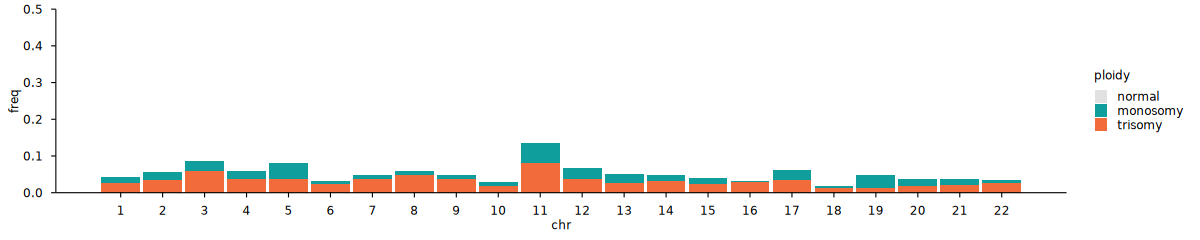

In [9]:
#plot
title = "freq_perchr_bar"

w <- 10
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

order = c("normal","monosomy","trisomy")
ploidydf$ploidy <- factor(ploidydf$ploidy, levels = order)

gg_bar = ggplot(ploidydf, aes(x=chr, fill=ploidy)) +
  geom_bar(position='fill')+
  settheme+
  scale_y_continuous(expand = c(0, 0), limits = c(0, 0.5))+
    scale_x_continuous(breaks = seq(1,22, by = 1)) +
  labs(y= "freq")+
  scale_fill_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))

ggsave(plot = gg_bar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gg_bar

### cell_chr

In [10]:
cell_chr_df <- ploidydf  %>%
  select(cell, chr, ploidy)%>%
  pivot_wider(names_from = chr, values_from = ploidy) %>%
  column_to_rownames("cell")

In [11]:
head(cell_chr_df)

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
AAACCTGAGCGATCCC-1_Embryo-Imp15265938,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal
AAACCTGGTAGCGTCC-1_Embryo-Imp15265938,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal
AAACGGGAGGACAGAA-1_Embryo-Imp15265938,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal
AAACGGGGTTACGACT-1_Embryo-Imp15265938,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal
AAAGATGCACAGATTC-1_Embryo-Imp15265938,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal
AAAGATGCAGGAATCG-1_Embryo-Imp15265938,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal


In [12]:
write.csv(cell_chr_df,sprintf("%s/cell_chr_scploid.csv",outdir), row.names = TRUE)

In [13]:
sprintf("%s/cell_chr_df_matrix.csv",outdir)

[1] "/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/7_2_xclone/cell_chr_df_matrix.csv"

### cell_karyotype

In [14]:
#add karyotype info
karyotype_summary <- ploidydf %>%
  # Ensure chromosomes are sorted numerically for a clean final string
  arrange(cell, as.numeric(chr)) %>% 
  
  # Create a label for each row based on ploidy
  mutate(event = case_when(
    ploidy == "trisomy" ~ paste0(chr, "+"),   # Trisomy / Gain
    ploidy == "monosomy" ~ paste0(chr, "-"),   # Monosomy / Loss
    TRUE ~ NA_character_             # Normal (ploidy 2), mark as NA to ignore later
  )) %>%
  
  # Filter out the 'normal' rows so they don't clutter the string
  filter(!is.na(event)) %>%
  
  # Group by cell and collapse the events into a single string
  group_by(cell) %>%
  summarise(karyotype = paste(event, collapse = ", ")) %>%
  
  # Join back to original list of cells to ensure 'normal' cells appear
  right_join(distinct(ploidydf, cell), by = "cell") %>%
  
  # Fill in the NAs for cells that had no events
  mutate(karyotype = ifelse(is.na(karyotype), "diploid", karyotype))

#summarise the karyotype info
final_summary <- karyotype_summary %>%
  mutate(ploidy = case_when(
    # 1. Check for Normal
    karyotype == "diploid" ~ "diploid",
    
    # 2. Check for single Trisomy: Exactly one '+' AND zero '-'
    str_count(karyotype, "\\+") == 1 & str_count(karyotype, "-") == 0 ~ "trisomy",
    
    # 3. Check for single Monosomy: Exactly one '-' AND zero '+'
    str_count(karyotype, "-") == 1 & str_count(karyotype, "\\+") == 0 ~ "monosomy",
    
    # 4. Everything else (multiple events, mixed gains/losses) -> Complex
    TRUE ~ "complex"
  ))

#add number of chromosomes
cell_karyotype <- final_summary %>%
  mutate(
    # Count occurrences of "+" (escape with \\ because + is a special regex character)
    num_gain_chr = str_count(karyotype, "\\+"),
    
    # Count occurrences of "-"
    num_loss_chr = str_count(karyotype, "-"),
    
    # Apply the math: Start at 22, add gains, subtract losses
    num_chr = 22 + num_gain_chr - num_loss_chr,
    num_abnormal_chr = num_gain_chr + num_loss_chr
  )

# View result
head(cell_karyotype, 10)

cell,karyotype,ploidy,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<int>
AAACCTGAGCCGATTT-1_Embryo-Imp15265941,11+,trisomy,1,0,23,1
AAACCTGAGCGTTGCC-1_Embryo-Imp15265940,"3-, 4-, 19-",complex,0,3,19,3
AAACCTGAGCTATGCT-1_Embryo-Imp15265941,"7+, 17+, 19-",complex,2,1,23,3
AAACCTGAGGCTCATT-1_Embryo-Imp15265946,1+,trisomy,1,0,23,1
AAACCTGAGTACGCCC-1_Embryo-Imp15265942,11+,trisomy,1,0,23,1
AAACCTGAGTAGTGCG-1_Embryo-Imp15265940,"7+, 8+",complex,2,0,24,2
AAACCTGAGTTGTAGA-1_Embryo-Imp15265944,13+,trisomy,1,0,23,1
AAACCTGCAACAACCT-1_Embryo-Imp15265940,"1-, 2-, 3-, 5+, 6+, 7+, 8+, 9+, 10+, 11+, 12+, 13+, 14+, 15+, 16+, 17-, 18-, 19-, 20+, 21+, 22+",complex,15,6,31,21
AAACCTGCAATCACAC-1_Embryo-Imp15265938,3+,trisomy,1,0,23,1


In [15]:
write.csv(cell_karyotype,sprintf("%s/cell_karyotype_scploid.csv",outdir), row.names = TRUE)

In [16]:
head(ploidydf, 3)

,cell,chr,ploidy
,<chr>,<int>,<fct>
1,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,1,normal
2,AAACCTGGTAGCGTCC-1_Embryo-Imp15265938,1,normal
3,AAACGGGAGGACAGAA-1_Embryo-Imp15265938,1,normal


Warning message:
“Removed 22 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 22 rows containing missing values or values outside the scale range
(`geom_bar()`).”


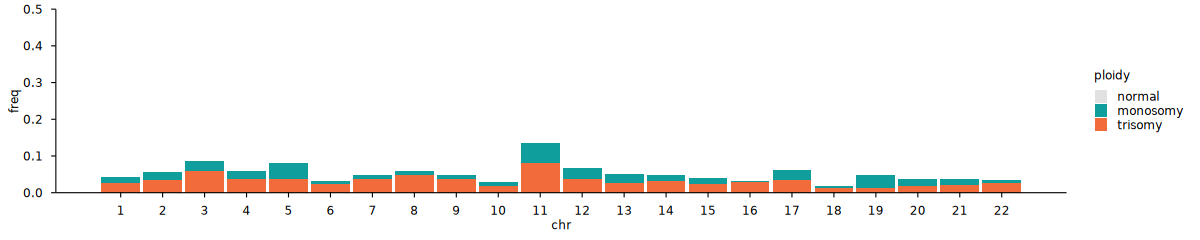

In [17]:
#plot
title = "freq_perchr_bar"

w <- 10
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

order = c("normal","monosomy","trisomy")
ploidydf$ploidy <- factor(ploidydf$ploidy, levels = order)

gg_bar = ggplot(ploidydf, aes(x=chr, fill=ploidy)) +
  geom_bar(position='fill')+
  settheme+
  scale_y_continuous(expand = c(0, 0), limits = c(0, 0.5))+
    scale_x_continuous(breaks = seq(1,22, by = 1)) +
  labs(y= "freq")+
  scale_fill_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))

ggsave(plot = gg_bar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gg_bar

### cell_chr

In [18]:
cell_chr_df <- ploidydf  %>%
  select(cell, chr, ploidy)%>%
  pivot_wider(names_from = chr, values_from = ploidy) %>%
  column_to_rownames("cell")

In [19]:
head(cell_chr_df)

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
AAACCTGAGCGATCCC-1_Embryo-Imp15265938,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal
AAACCTGGTAGCGTCC-1_Embryo-Imp15265938,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal
AAACGGGAGGACAGAA-1_Embryo-Imp15265938,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal
AAACGGGGTTACGACT-1_Embryo-Imp15265938,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal
AAAGATGCACAGATTC-1_Embryo-Imp15265938,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal
AAAGATGCAGGAATCG-1_Embryo-Imp15265938,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal,normal


In [20]:
write.csv(cell_chr_df,sprintf("%s/cell_chr_scploid.csv",outdir), row.names = TRUE)

In [21]:
sprintf("%s/cell_chr_df_matrix.csv",outdir)

[1] "/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/7_2_xclone/cell_chr_df_matrix.csv"

### cell_karyotype

In [22]:
#add karyotype info
karyotype_summary <- ploidydf %>%
  # Ensure chromosomes are sorted numerically for a clean final string
  arrange(cell, as.numeric(chr)) %>% 
  
  # Create a label for each row based on ploidy
  mutate(event = case_when(
    ploidy == "trisomy" ~ paste0(chr, "+"),   # Trisomy / Gain
    ploidy == "monosomy" ~ paste0(chr, "-"),   # Monosomy / Loss
    TRUE ~ NA_character_             # Normal (ploidy 2), mark as NA to ignore later
  )) %>%
  
  # Filter out the 'normal' rows so they don't clutter the string
  filter(!is.na(event)) %>%
  
  # Group by cell and collapse the events into a single string
  group_by(cell) %>%
  summarise(karyotype = paste(event, collapse = ", ")) %>%
  
  # Join back to original list of cells to ensure 'normal' cells appear
  right_join(distinct(ploidydf, cell), by = "cell") %>%
  
  # Fill in the NAs for cells that had no events
  mutate(karyotype = ifelse(is.na(karyotype), "diploid", karyotype))

#summarise the karyotype info
final_summary <- karyotype_summary %>%
  mutate(ploidy = case_when(
    # 1. Check for Normal
    karyotype == "diploid" ~ "diploid",
    
    # 2. Check for single Trisomy: Exactly one '+' AND zero '-'
    str_count(karyotype, "\\+") == 1 & str_count(karyotype, "-") == 0 ~ "trisomy",
    
    # 3. Check for single Monosomy: Exactly one '-' AND zero '+'
    str_count(karyotype, "-") == 1 & str_count(karyotype, "\\+") == 0 ~ "monosomy",
    
    # 4. Everything else (multiple events, mixed gains/losses) -> Complex
    TRUE ~ "complex"
  ))

#add number of chromosomes
cell_karyotype <- final_summary %>%
  mutate(
    # Count occurrences of "+" (escape with \\ because + is a special regex character)
    num_gain_chr = str_count(karyotype, "\\+"),
    
    # Count occurrences of "-"
    num_loss_chr = str_count(karyotype, "-"),
    
    # Apply the math: Start at 22, add gains, subtract losses
    num_chr = 44 + num_gain_chr - num_loss_chr,
    num_abnormal_chr = num_gain_chr + num_loss_chr
  )

# View result
head(cell_karyotype, 10)

cell,karyotype,ploidy,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<int>
AAACCTGAGCCGATTT-1_Embryo-Imp15265941,11+,trisomy,1,0,45,1
AAACCTGAGCGTTGCC-1_Embryo-Imp15265940,"3-, 4-, 19-",complex,0,3,41,3
AAACCTGAGCTATGCT-1_Embryo-Imp15265941,"7+, 17+, 19-",complex,2,1,45,3
AAACCTGAGGCTCATT-1_Embryo-Imp15265946,1+,trisomy,1,0,45,1
AAACCTGAGTACGCCC-1_Embryo-Imp15265942,11+,trisomy,1,0,45,1
AAACCTGAGTAGTGCG-1_Embryo-Imp15265940,"7+, 8+",complex,2,0,46,2
AAACCTGAGTTGTAGA-1_Embryo-Imp15265944,13+,trisomy,1,0,45,1
AAACCTGCAACAACCT-1_Embryo-Imp15265940,"1-, 2-, 3-, 5+, 6+, 7+, 8+, 9+, 10+, 11+, 12+, 13+, 14+, 15+, 16+, 17-, 18-, 19-, 20+, 21+, 22+",complex,15,6,53,21
AAACCTGCAATCACAC-1_Embryo-Imp15265938,3+,trisomy,1,0,45,1


In [23]:
write.csv(cell_karyotype,sprintf("%s/cell_karyotype_scploid.csv",outdir), row.names = TRUE)

## Plots per sample

### A) Tile cell x chr

In [24]:
# 1. Prepare the Heatmap Data
heatmap_data <- cell_chr_df %>%
  # Move row names (cells) to a real column
  rownames_to_column(var = "cell.ID_") %>%
  
  # Reshape wide -> long: Create 'chr' and 'state' columns
  pivot_longer(
    cols = -"cell.ID_", 
    names_to = "chr", 
    values_to = "state"
  ) %>%
  
  # Join with your metadata to get 'sample' info
  left_join(scanpy_meta, by = "cell.ID_") %>%
  mutate(chr = factor(chr, levels = sort(unique(as.numeric(chr)))))

head(heatmap_data, 3)

cell.ID_,chr,state,X,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse
<chr>,<fct>,<fct>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>
AAACCTGAGCGATCCC-1_Embryo-Imp15265938,1,normal,0,Embryo-Imp15265938,0.07129456,False,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.2910713,-0.07524606,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified
AAACCTGAGCGATCCC-1_Embryo-Imp15265938,2,normal,0,Embryo-Imp15265938,0.07129456,False,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.2910713,-0.07524606,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified
AAACCTGAGCGATCCC-1_Embryo-Imp15265938,3,normal,0,Embryo-Imp15265938,0.07129456,False,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.2910713,-0.07524606,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified


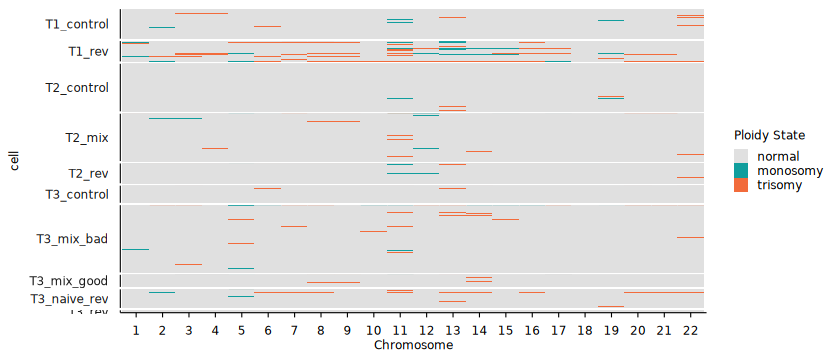

In [25]:
#plot
title = "A_heatmap_ploidy_sample"

w <- 7
h <- 3
options(repr.plot.width=w, repr.plot.height=h)

gggeom = ggplot(heatmap_data, aes(x = chr, y = cell.ID_, fill = state)) +
  geom_tile() + # Add thin white borders
  #rasterise(geom_tile(), dpi = 300) +
  # Define your biology-specific colors
  scale_fill_manual(values = c("normal"= "#E0E0E0","monosomy"="#109E9D","trisomy"="#F26B3B")) +
  
  # Group cells visually by faceting (splitting) by Sample
  facet_grid(sample ~ ., scales = "free_y", space = "free_y", switch = "y") +
  # Clean up the look
  theme_minimal() +
  labs(x = "Chromosome", y = "cell", fill = "Ploidy State") +
  settheme+
  theme(
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
    panel.grid = element_blank(),
    strip.placement = "outside",
    strip.text.y.left = element_text(angle = 0, hjust = 1),
      panel.spacing = unit(0.1, "lines")
  )

#ggsave(plot = gggeom, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggsave(plot = gggeom, filename = sprintf("%s/%s.png", outdir, title), 
       w = w, h = h, dpi = 300)
gggeom

### B) % anuploid per chr

In [26]:
colnames(scanpy_meta)

[1] "X"                        "dataset"                 
 [3] "cell.ID_"                 "scrublet_score"          
 [5] "scrublet_prediction"      "scrublet_cluster_score"  
 [7] "scrublet_zscore"          "scrublet_bh_pval"        
 [9] "scrublet_bonf_pval"       "n_genes_by_counts"       
[11] "total_counts"             "total_counts_mt"         
[13] "pct_counts_mt"            "total_counts_ribo"       
[15] "pct_counts_ribo"          "n_genes_group"           
[17] "S_score"                  "G2M_score"               
[19] "phase"                    "leiden"                  
[21] "mef_score"                "persample_celltype"      
[23] "sample_celltype"          "sample"                  
[25] "timepoint"                "Condition"               
[27] "State"                    "n_genes"                 
[29] "stress_score_vandenBrink" "leiden_theta0"           
[31] "leiden_theta1"            "leiden_theta2"           
[33] "leiden_theta3"            "integrated_celltype"     
[35] "leiden_lowres"            "celltype_fine"           
[37] "celltype_coarse"

In [27]:
merged_ploidydf <- inner_join(ploidydf, scanpy_meta, by = c("cell" = "cell.ID_"))

In [28]:
head(merged_ploidydf)

,cell,chr,ploidy,X,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse
,<chr>,<int>,<fct>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>
1,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,1,normal,0,Embryo-Imp15265938,0.07129456,False,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.2910713,-0.075246060,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified
2,AAACCTGGTAGCGTCC-1_Embryo-Imp15265938,1,normal,9,Embryo-Imp15265938,0.09309967,False,0.08256881,-0.6249869,1,0.9147751,7621,42425,1402,3.304655,10427,24.57749,high,0.3733255,0.055389035,S,8,0.8384416,diff,TE,T1_control,day1,Control,Naïve,7621,0.3519634,7,7,8,9,unspecified,7,unspecified_2,unspecified
3,AAACGGGAGGACAGAA-1_Embryo-Imp15265938,1,normal,22,Embryo-Imp15265938,0.06349206,False,0.08016032,-0.6484708,1,0.9147751,6708,24063,1041,4.326144,4942,20.53775,high,0.4155973,0.006537977,S,8,-0.5155844,diff,TE,T1_control,day1,Control,Naïve,6708,0.3004387,2,5,11,2,unspecified,7,unspecified_2,unspecified
4,AAACGGGGTTACGACT-1_Embryo-Imp15265938,1,normal,28,Embryo-Imp15265938,0.07558140,False,0.08506224,-0.6006746,1,0.9147751,7452,34653,979,2.825152,8387,24.20281,high,0.4325970,-0.081786726,S,5,0.5449351,diff,TE,T1_control,day1,Control,Naïve,7452,0.2396693,7,7,8,9,unspecified,6,unspecified_2,unspecified
5,AAAGATGCACAGATTC-1_Embryo-Imp15265938,1,normal,42,Embryo-Imp15265938,0.12368421,False,0.08256881,-0.6249869,1,0.9147751,6875,34768,874,2.513806,9365,26.93569,high,0.4006933,-0.008530573,S,5,-0.2251948,diff,TE,T1_control,day1,Control,Naïve,6875,0.3172255,7,7,8,9,unspecified,6,unspecified_2,unspecified
6,AAAGATGCAGGAATCG-1_Embryo-Imp15265938,1,normal,48,Embryo-Imp15265938,0.10532544,False,0.08016032,-0.6484708,1,0.9147751,7157,36040,887,2.461154,9063,25.14706,high,0.3710863,0.011428119,S,8,0.3111688,diff,TE,T1_control,day1,Control,Naïve,7157,0.2750824,3,3,0,3,unspecified,7,unspecified_2,unspecified


Warning message:
“Removed 220 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 220 rows containing missing values or values outside the scale range
(`geom_bar()`).”


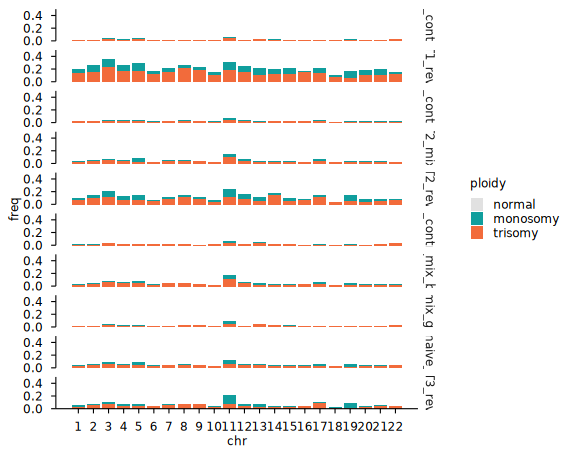

In [29]:
#plot
title = "B_freq_perchr_bar"

w <- 4.8
h <- 3.8
options(repr.plot.width=w, repr.plot.height=h)

order = c("normal","monosomy","trisomy")
merged_ploidydf$ploidy <- factor(merged_ploidydf$ploidy, levels = order)

gg_bar = ggplot(merged_ploidydf, aes(x=chr, fill=ploidy)) +
  geom_bar(position='fill', width = 0.8)+
  settheme+
  scale_y_continuous(expand = c(0, 0), limits = c(0, 0.5), breaks = seq(0, 0.5, by = 0.2))+
  scale_x_continuous(breaks = seq(1,22, by = 1))+
  labs(y= "freq")+
  scale_fill_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))+
  facet_grid(sample ~.)

ggsave(plot = gg_bar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gg_bar

In [30]:
unique(merged_ploidydf$sample)

[1] "T1_control"   "T1_rev"       "T2_control"   "T2_rev"       "T2_mix"      
 [6] "T3_naive_rev" "T3_control"   "T3_mix_good"  "T3_mix_bad"   "T3_rev"

### C) % aneuploid cell per condition

In [31]:
merged_cellkaryotype <- inner_join(cell_karyotype, scanpy_meta, by = c("cell" = "cell.ID_"))

In [32]:
colnames(merged_cellkaryotype)

[1] "cell"                     "karyotype"               
 [3] "ploidy"                   "num_gain_chr"            
 [5] "num_loss_chr"             "num_chr"                 
 [7] "num_abnormal_chr"         "X"                       
 [9] "dataset"                  "scrublet_score"          
[11] "scrublet_prediction"      "scrublet_cluster_score"  
[13] "scrublet_zscore"          "scrublet_bh_pval"        
[15] "scrublet_bonf_pval"       "n_genes_by_counts"       
[17] "total_counts"             "total_counts_mt"         
[19] "pct_counts_mt"            "total_counts_ribo"       
[21] "pct_counts_ribo"          "n_genes_group"           
[23] "S_score"                  "G2M_score"               
[25] "phase"                    "leiden"                  
[27] "mef_score"                "persample_celltype"      
[29] "sample_celltype"          "sample"                  
[31] "timepoint"                "Condition"               
[33] "State"                    "n_genes"                 
[35] "stress_score_vandenBrink" "leiden_theta0"           
[37] "leiden_theta1"            "leiden_theta2"           
[39] "leiden_theta3"            "integrated_celltype"     
[41] "leiden_lowres"            "celltype_fine"           
[43] "celltype_coarse"

In [33]:
nrow(merged_cellkaryotype)

[1] 38655

In [34]:
#percentage of cells per ploidy group
per_ploidy = 
merged_cellkaryotype %>%
  group_by(sample, ploidy) %>%
  summarise(count = n()) %>%
  mutate(per = count / sum(count)) %>%
  mutate(total =sum(count))

head(per_ploidy)

`summarise()` has grouped output by 'sample'. You can override using the
`.groups` argument.


sample,ploidy,count,per,total
<chr>,<chr>,<int>,<dbl>,<int>
T1_control,complex,191,0.04713722,4052
T1_control,diploid,3268,0.80651530,4052
T1_control,monosomy,165,0.04072063,4052
T1_control,trisomy,428,0.10562685,4052
T1_rev,complex,1507,0.54072479,2787
T1_rev,diploid,867,0.31108719,2787


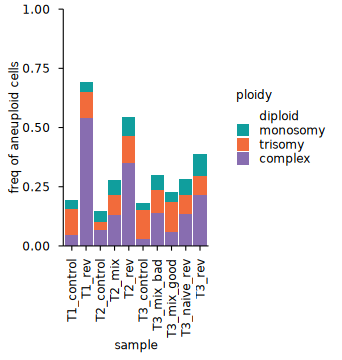

In [35]:
#plot
title = "C_per_aneu_cell_condition"

w <- 2.85
h <- 3
options(repr.plot.width=w, repr.plot.height=h)


order = c("diploid","monosomy","trisomy","complex" )
per_ploidy$ploidy <- factor(per_ploidy$ploidy, levels = order)

ggbar = ggplot(per_ploidy, aes(x=sample, y=per, fill = ploidy)) +
          geom_bar(stat="identity", width = 0.85)+
          settheme+
          scale_y_continuous(expand = c(0, 0), limits = c(0, 1))+
          labs(y= "freq of aneuploid cells")+
          scale_fill_manual(values=color_ploidy)+
          theme(axis.text.x = element_text(colour = "black", angle = 90, vjust=0.5, hjust = 1))
  
ggsave(plot = ggbar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggbar

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_bar()`).”


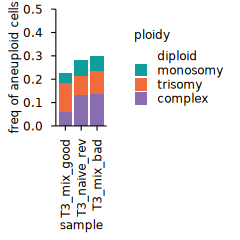

In [42]:
#plot
title = "C_per_aneu_cell_condition_sub"

w <- 2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)
  

order = c("diploid","monosomy","trisomy","complex" )
per_ploidy$ploidy <- factor(per_ploidy$ploidy, levels = order)


order = c("T3_mix_good", "T3_naive_rev", "T3_mix_bad")
per_ploidy$sample<- factor(per_ploidy$sample, levels = order)

per_ploidy_sub  = per_ploidy |> filter(sample %in% c("T3_naive_rev", "T3_mix_good", "T3_mix_bad"))

ggbar = ggplot(per_ploidy_sub, aes(x = sample, y = per, fill = ploidy)) +
  geom_bar(stat = "identity", width = 0.8) +
  settheme +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 0.5)) +
  labs(y = "freq of aneuploid cells") +
  scale_fill_manual(values = color_ploidy) +
  theme(
    axis.text.x = element_text(
      colour = "black",
      angle = 90,
      vjust = 0.5,
      hjust = 1
    )
  )
ggsave(plot = ggbar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggbar

### D) Histogram number of chromosome

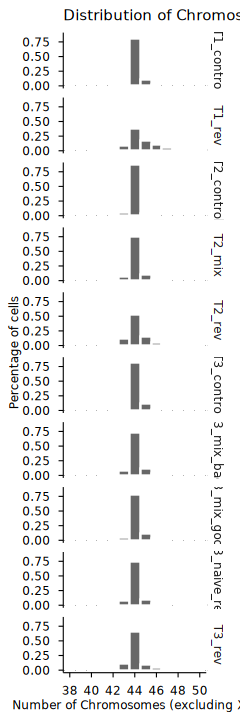

In [36]:
# plot
title = "D_hist_num_chr_percent"

w <- 2
h <- 6
options(repr.plot.width=w, repr.plot.height=h)

x_breaks <- seq(38, 50, by = 2) 
y_breaks <- seq(0, 1, by = 0.25)

gghist = ggplot(merged_cellkaryotype, aes(x = num_chr, y = after_stat(density))) +
  geom_histogram(binwidth = 1, fill = "#676767", color = "white") +
  scale_x_continuous(breaks = x_breaks) +
  scale_y_continuous(breaks = y_breaks) +
  coord_cartesian(xlim = c(38, 50)) +
  facet_grid(sample ~ .)+
  theme_minimal() +
  labs(
    title = "Distribution of Chromosome Counts per Sample",
    x = "Number of Chromosomes (excluding XY)",
    y = "Percentage of cells"
  ) + settheme

  
ggsave(plot = gghist, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gghist

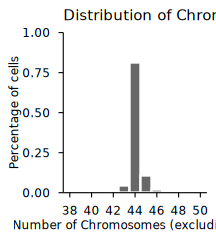

In [37]:
# plot
title = "D_hist_num_chr_percent_ctr"

w <- 1.8
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

x_breaks <- seq(38, 50, by = 2) 
y_breaks <- seq(0, 1, by = 0.25)

gghist = ggplot(merged_cellkaryotype%>% subset(sample == "T1_control") , aes(x = num_chr, y = after_stat(density))) +
  geom_histogram(binwidth = 1, fill = "#676767", color = "white")  +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1), breaks = seq(0, 1, by = 0.25) )+
  scale_x_continuous(breaks = x_breaks) +
  #scale_y_continuous(breaks = y_breaks) +
  coord_cartesian(xlim = c(38, 50)) +
  #facet_grid(sample ~ .)+
  theme_minimal() +
  labs(
    title = "Distribution of Chromosome Counts per Sample",
    x = "Number of Chromosomes (excluding XY)",
    y = "Percentage of cells"
  ) + settheme

  
ggsave(plot = gghist, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gghist

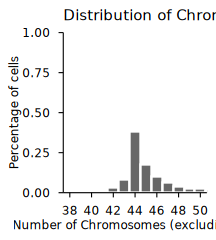

In [38]:
# plot
title = "D_hist_num_chr_percent_rev"

w <- 1.8
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

x_breaks <- seq(38, 50, by = 2) 
y_breaks <- seq(0, 1, by = 0.25)

gghist = ggplot(merged_cellkaryotype%>% subset(sample == "T1_rev") , aes(x = num_chr, y = after_stat(density))) +
  geom_histogram(binwidth = 1, fill = "#676767", color = "white") +
  scale_x_continuous(breaks = x_breaks)  +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1), breaks = seq(0, 1, by = 0.25) )+
  coord_cartesian(xlim = c(38, 50)) +
  #facet_grid(sample ~ .)+
  theme_minimal() +
  labs(
    title = "Distribution of Chromosome Counts per Sample",
    x = "Number of Chromosomes (excluding XY)",
    y = "Percentage of cells"
  ) + settheme

  
ggsave(plot = gghist, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gghist

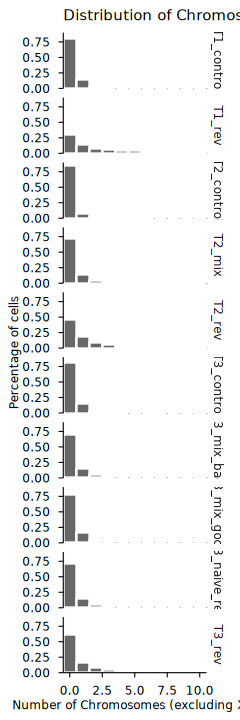

In [39]:
# plot
title = "D2_hist_num_abnormal_chr"
w <- 2
h <- 6
options(repr.plot.width=w, repr.plot.height=h)

# Define the breaks for the x-axis (e.g., from 10 to 30 by 2)
# You can adjust the '10' and '30' to match your actual data range
#x_breaks <- seq(10, 30, by = 2) 

gghist = ggplot(merged_cellkaryotype, aes(x = num_abnormal_chr, y = after_stat(density))) +
  geom_histogram(binwidth = 1, fill = "#676767", color = "white") +
  scale_y_continuous(expand = c(0, 0), limits = c(0, .9), breaks = seq(0, 1, by = 0.25) )+
  #scale_x_continuous(breaks = x_breaks) +
  coord_cartesian(xlim = c(0, 10))+
  facet_grid(sample ~ .)+
  theme_minimal() +
  labs(
    title = "Distribution of Chromosome Counts per Sample",
    x = "Number of Chromosomes (excluding XY)",
    y = "Percentage of cells"
  ) + settheme

  
ggsave(plot = gghist, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gghist

### E) Heatmap of karyotypes

In [40]:
# 1. Aggregate: Count cells per (Sample + Karyotype)
merged_cellkaryotype_counts <- merged_cellkaryotype %>%
  filter(ploidy != "diploid" & ploidy != "normal") %>%
  group_by(sample, karyotype, ploidy) %>%
  summarise(count = n(), .groups = "drop") %>%
  
  # This calculates: (Count of specific karyotype) / (Total aneuploid cells in sample)
  group_by(sample) %>%
  mutate(prop = count / sum(count)) %>%
  ungroup()

# 2. Get the LIST of top names (based on total abundance)
top_karyotypes <- merged_cellkaryotype_counts %>%
  group_by(karyotype) %>%
  summarise(total = sum(count)) %>%
  slice_max(total, n = 150) %>%
  pull(karyotype)

# 3. Filter using that list
heatmap_data_filtered <- merged_cellkaryotype_counts %>%
  filter(karyotype %in% top_karyotypes)

# 4. Define the Sorting Logic (Monosomy -> Trisomy -> Complex)
sorted_levels <- heatmap_data_filtered %>%
  distinct(karyotype, ploidy) %>%
  mutate(
    chr_num = as.numeric(str_extract(karyotype, "\\d+")),
    group_rank = case_when(
      ploidy == "monosomy" ~ 1,
      ploidy == "trisomy"  ~ 2,
      TRUE                 ~ 3 
    )
  ) %>%
  arrange(group_rank, chr_num) %>%
  pull(karyotype)

# 5. Apply this order
heatmap_data_filtered <- heatmap_data_filtered %>%
  mutate(karyotype = factor(karyotype, levels = sorted_levels))

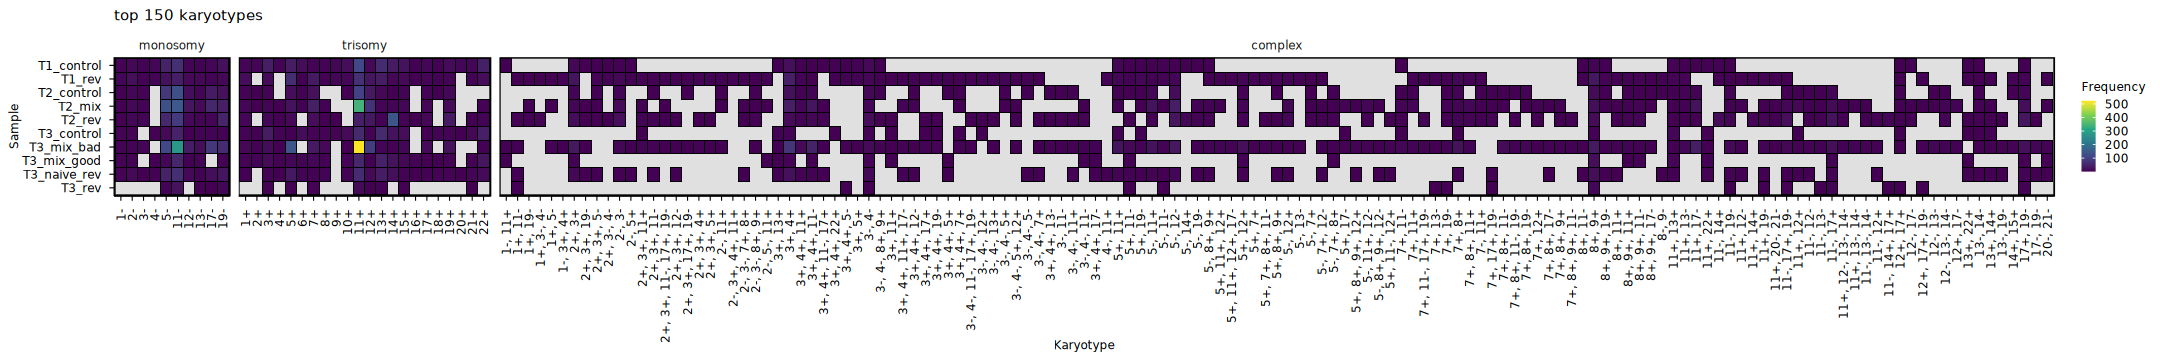

In [41]:
title = "E_heatmap_karyotype_sample_sorted"
w <- 18
h <- 3

options(repr.plot.width=w, repr.plot.height=h)

heatmap_data_filtered$ploidy <- factor(
  heatmap_data_filtered$ploidy, 
  levels = c("monosomy", "trisomy", "complex")
)

gggeom = ggplot(heatmap_data_filtered, aes(x = karyotype, y = sample, fill = count)) +
  geom_tile(color = "black") + 
  scale_fill_viridis_c(option = "viridis") +
  labs(x = "Karyotype", y = "Sample", fill = "Frequency", title = "top 150 karyotypes") +
scale_y_discrete(limits = rev) +
 settheme+
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
    axis.ticks.x = element_line(),
    strip.background = element_blank(),
    panel.background = element_rect(fill = "#E0E0E0"), panel.grid = element_blank())+
facet_grid(~ploidy, scales = "free_x", space = "free_x") 

ggsave(plot = gggeom, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gggeom

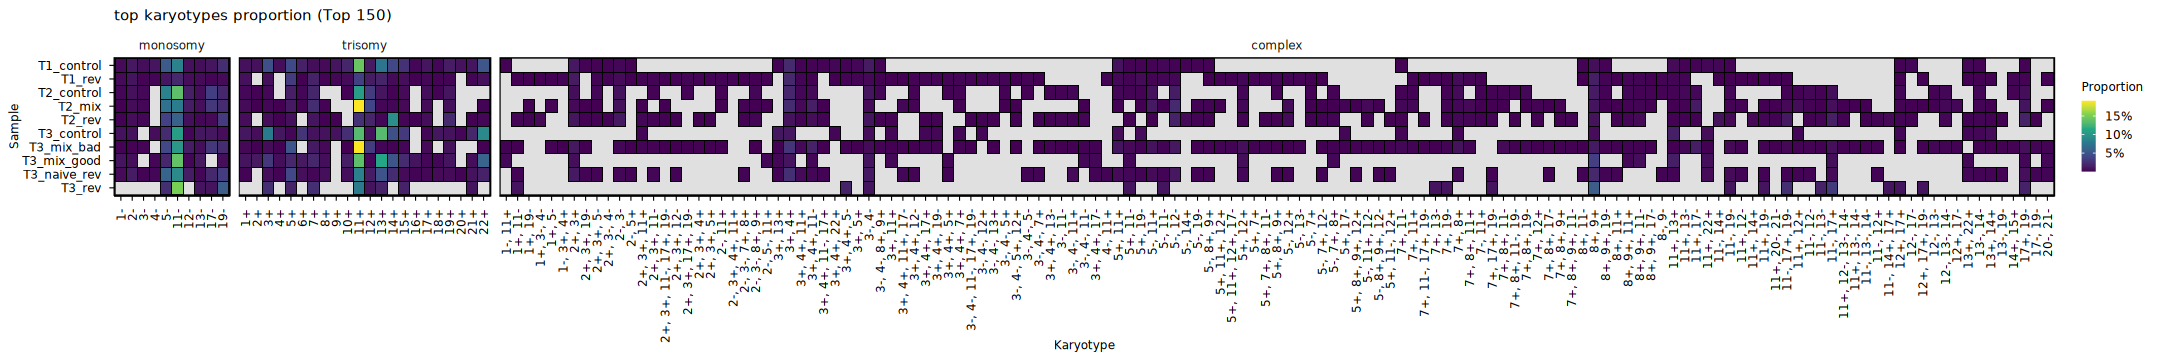

In [42]:
# plot proportions
title = "E_2_heatmap_karyotype_sample_proportion"
w <- 18
h <- 3
options(repr.plot.width=w, repr.plot.height=h)

heatmap_data_filtered$ploidy <- factor(
  heatmap_data_filtered$ploidy, 
  levels = c("monosomy", "trisomy", "complex")
)

gggeom = ggplot(heatmap_data_filtered, aes(x = karyotype, y = sample, fill = prop)) +
  geom_tile(color = "black") + 
  scale_fill_viridis_c(
    option = "viridis", 
    labels = scales::percent, 
    na.value = "#E0E0E0"
  ) +
  labs(x = "Karyotype", y = "Sample", fill = "Proportion", title = "top karyotypes proportion (Top 150)") +
  scale_y_discrete(limits = rev) +
  settheme +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
    axis.ticks.x = element_line(),
    strip.background = element_blank(),
    panel.background = element_rect(fill = "#E0E0E0"), 
    panel.grid = element_blank()
  )+
facet_grid(~ploidy, scales = "free_x", space = "free_x") 

ggsave(plot = gggeom, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gggeom

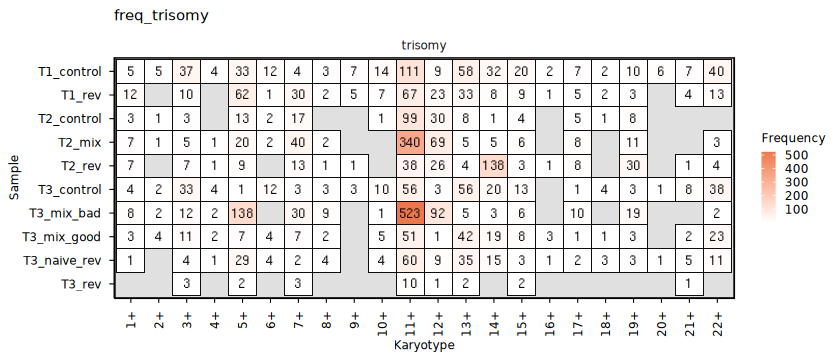

In [43]:
title <- "E3_heatmap_trisomy"
w <- 7
h <- 3
options(repr.plot.width = w, repr.plot.height = h)

# 1) subset ploidy
heatmap_data_filtered2 <- heatmap_data_filtered %>%
  filter(ploidy %in% c("trisomy")) 

gggeom <- ggplot(heatmap_data_filtered2, aes(x = karyotype, y = sample, fill = count)) +
  geom_tile(color = "black") +
  # 2) show numbers in each box
  geom_text(aes(label = count), size = 2.6) +  # Add white borders between tiles
  scale_fill_gradient(low = "white", high = "#EB784D") +
  #scale_fill_viridis_c(option = "viridis") +
  labs(x = "Karyotype", y = "Sample", fill = "Frequency", title = "freq_trisomy") +
  scale_y_discrete(limits = rev) +
  settheme +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
    axis.ticks.x = element_line(),
    strip.background = element_blank(),
    panel.background = element_rect(fill = "#E0E0E0"),
    panel.grid = element_blank(),
    panel.border = element_blank()
  ) +
  facet_grid(~ploidy, scales = "free_x", space = "free_x")

ggsave(
  filename = sprintf("%s/%s.pdf", outdir, title),
  plot = gggeom,
  width = w, height = h
)

gggeom

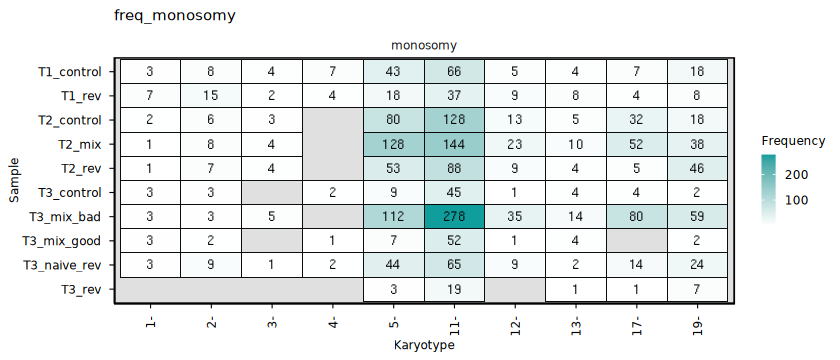

In [44]:
title <- "E4_heatmap_monosomy"
w <- 7
h <- 3
options(repr.plot.width = w, repr.plot.height = h)

# 1) subset ploidy
heatmap_data_filtered2 <- heatmap_data_filtered %>%
  filter(ploidy %in% c("monosomy")) 

gggeom <- ggplot(heatmap_data_filtered2, aes(x = karyotype, y = sample, fill = count)) +
  geom_tile(color = "black") +
  # 2) show numbers in each box
  geom_text(aes(label = count), size = 2.6) +  # Add white borders between tiles
  scale_fill_gradient(low = "white", high = "#109E9D") +
  #scale_fill_viridis_c(option = "viridis") +
  labs(x = "Karyotype", y = "Sample", fill = "Frequency", title = "freq_monosomy") +
  scale_y_discrete(limits = rev) +
  settheme +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
    axis.ticks.x = element_line(),
    strip.background = element_blank(),
    panel.background = element_rect(fill = "#E0E0E0"),
    panel.grid = element_blank(),
    panel.border = element_blank()
  ) +
  facet_grid(~ploidy, scales = "free_x", space = "free_x")

ggsave(
  filename = sprintf("%s/%s.pdf", outdir, title),
  plot = gggeom,
  width = w, height = h
)

gggeom

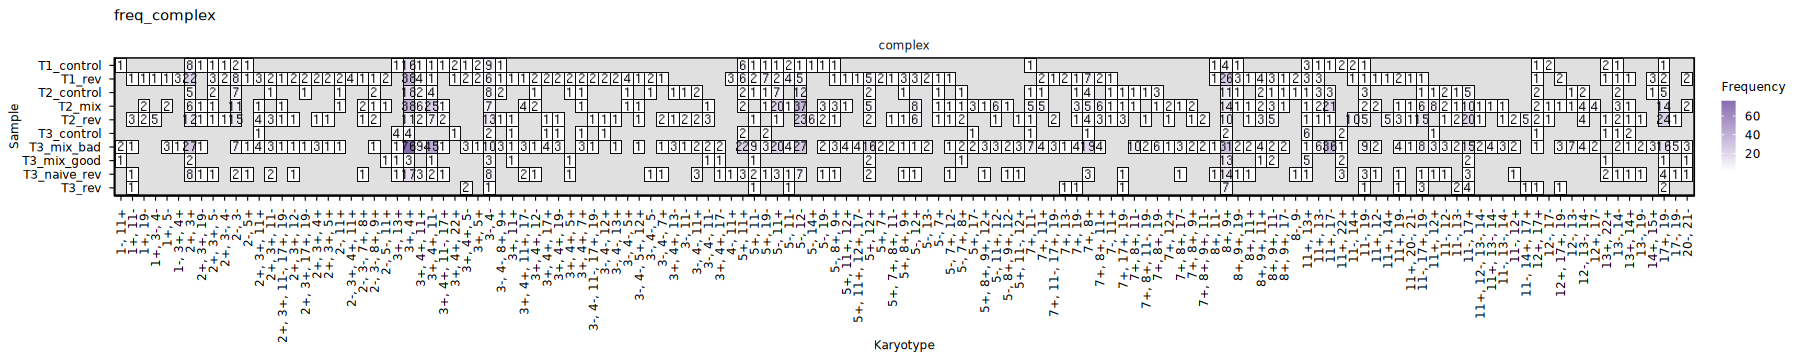

In [45]:
title <- "E5_heatmap_complex"
w <- 15
h <- 3
options(repr.plot.width = w, repr.plot.height = h)

# 1) subset ploidy
heatmap_data_filtered2 <- heatmap_data_filtered %>%
  filter(ploidy %in% c("complex")) 

gggeom <- ggplot(heatmap_data_filtered2, aes(x = karyotype, y = sample, fill = count)) +
  geom_tile(color = "black") +
  # 2) show numbers in each box
  geom_text(aes(label = count), size = 2.6) +  # Add white borders between tiles
  scale_fill_gradient(low = "white", high = "#886DB0") +
  #scale_fill_viridis_c(option = "viridis") +
  labs(x = "Karyotype", y = "Sample", fill = "Frequency", title = "freq_complex") +
  scale_y_discrete(limits = rev) +
  settheme +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
    axis.ticks.x = element_line(),
    strip.background = element_blank(),
    panel.background = element_rect(fill = "#E0E0E0"),
    panel.grid = element_blank(),
    panel.border = element_blank()
  ) +
  facet_grid(~ploidy, scales = "free_x", space = "free_x")

ggsave(
  filename = sprintf("%s/%s.pdf", outdir, title),
  plot = gggeom,
  width = w, height = h
)

gggeom

### F) Barchart of proportion of each karyotype

In [46]:
head(merged_cellkaryotype_counts,3)

sample,karyotype,ploidy,count,prop
<chr>,<chr>,<chr>,<int>,<dbl>
T1_control,1+,trisomy,5,0.006377551
T1_control,"1+, 11-, 13+, 17+, 19-",complex,1,0.001275510
T1_control,"1+, 2+, 3+, 4+, 6+, 7+, 11-, 12-, 13-, 14-, 20+, 21+, 22+",complex,1,0.001275510


In [47]:
#percentage of cells per ploidy group
per_ploidy = 
merged_cellkaryotype_counts %>%
  filter(ploidy %in% c("monosomy", "trisomy"))%>%
  group_by(sample)%>%
  mutate(per = count / sum(count)) %>%
  mutate(total =sum(count))

head(per_ploidy)

sample,karyotype,ploidy,count,prop,per,total
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<int>
T1_control,1+,trisomy,5,0.006377551,0.008431703,593
T1_control,1-,monosomy,3,0.003826531,0.005059022,593
T1_control,10+,trisomy,14,0.017857143,0.023608769,593
T1_control,11+,trisomy,111,0.141581633,0.187183811,593
T1_control,11-,monosomy,66,0.084183673,0.111298482,593
T1_control,12+,trisomy,9,0.011479592,0.015177066,593


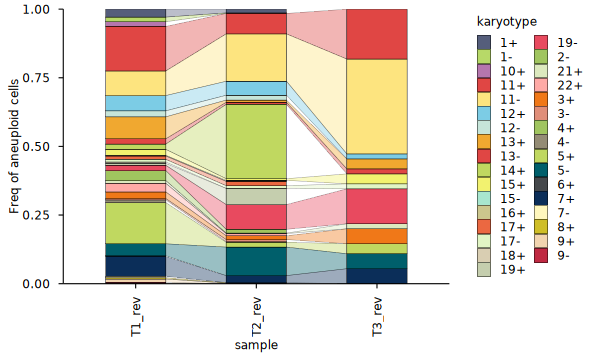

In [48]:
plot_data <- per_ploidy %>%
  ungroup() %>%
  filter(!is.na(per) & !is.na(sample) & !is.na(karyotype)) %>%
  mutate(
    sample = as.factor(sample),
    karyotype = as.factor(karyotype)
  )%>%
  filter(sample %in% c("T1_rev", "T2_rev", "T3_rev"))

# --- Configuration ---
title <- "F_allu_monosomy_trisomy"
w <- 5
h <- 3
options(repr.plot.width = w, repr.plot.height = h)

ggbar_alluvial <- ggplot(plot_data, aes(x = sample, y = per, alluvium = karyotype)) +
  geom_flow(aes(fill = karyotype), alpha = 0.4, curve_type = "linear", width = 0.5 ,linewidth = 0.1, color = "black") +
  geom_stratum(aes(stratum = karyotype, fill = karyotype), width = 0.5, color = "black", linewidth = 0.1) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1))+
  labs(y = "Freq of aneuploid cells")  +
  scale_fill_manual(values = custom_palette)+ 
  settheme+
  theme(
    axis.text.x = element_text(colour = "black", angle = 90, vjust = 0.5, hjust = 1)
    #legend.position = "none"
  )

ggsave(plot = ggbar_alluvial, filename = sprintf("%s/%s.pdf", outdir, title), w = w, h = h)
ggbar_alluvial

## include per embryo and cell type analysis

In [49]:
#ploidydf = read.csv("/nfs/team292/rs40/projects/Aneuploid_screen_v2/notebooks/7_xclone/ploidydf_xclone.csv")
cell_karyotype = read.csv("/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/7_2_xclone/cell_karyotype_scploid.csv")
scanpy_meta = read.csv( "/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/3_scanpy_integration/meta_integrated_sub_fine.csv")
BC_df = read.csv('/nfs/team292/rs40/projects/Aneuploid_screen/processed_data/barcode/BC_df.csv')

## Reformat

In [50]:
head(ploidydf,3)

,cell,chr,ploidy
,<chr>,<int>,<fct>
1,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,1,normal
2,AAACCTGGTAGCGTCC-1_Embryo-Imp15265938,1,normal
3,AAACGGGAGGACAGAA-1_Embryo-Imp15265938,1,normal


In [51]:
head(cell_karyotype, 3)

,X,cell,karyotype,ploidy,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr
,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>
1,1,AAACCTGAGCCGATTT-1_Embryo-Imp15265941,11+,trisomy,1,0,45,1
2,2,AAACCTGAGCGTTGCC-1_Embryo-Imp15265940,"3-, 4-, 19-",complex,0,3,41,3
3,3,AAACCTGAGCTATGCT-1_Embryo-Imp15265941,"7+, 17+, 19-",complex,2,1,45,3


In [52]:
head(scanpy_meta, 3)

,X,dataset,cell.ID_,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse
,<int>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>
1,0,Embryo-Imp15265938,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,0.07129456,False,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.29107126,-0.07524606,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified
2,3,Embryo-Imp15265938,AAACCTGCAATCACAC-1_Embryo-Imp15265938,0.19064748,False,0.19851577,0.5055552,1,0.8326981,8112,54075,1514,2.799815,13757,25.44059,high,-0.04671824,0.36545115,G2M,0,-3.2758442,EPI,EPI,T1_control,day1,Control,Naïve,8112,0.2379417,0,0,2,4,naive EPI,1,EPI_1,EPI
3,5,Embryo-Imp15265938,AAACCTGCAGCTGCTG-1_Embryo-Imp15265938,0.22540984,False,0.22540984,0.7677861,1,0.8326981,8801,68329,1605,2.348929,17109,25.03915,high,-0.04435138,0.21209913,G2M,0,-4.6309091,EPI,EPI,T1_control,day1,Control,Naïve,8801,0.2474431,0,0,3,1,naive EPI,1,EPI_1,EPI


In [53]:
head(BC_df, 3)

,X,cell.ID_,num_features,feature_call,num_umis,dataset,filtered_feature_call
,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,1,AAGGTTCCAGCCACCA,1,pooled_BC_1,490,Embryo-Imp15265940,pooled_BC_1
2,2,CACACAACAAGGACAC,1,pooled_BC_1,2525,Embryo-Imp15265940,pooled_BC_1
3,3,CCTTCCCGTGTGGCTC,1,pooled_BC_1,909,Embryo-Imp15265940,pooled_BC_1


In [54]:
BC_df <- BC_df %>%
  mutate(
    `cell.ID` = paste0(`cell.ID_`, "-1_", dataset)
  )

In [55]:
# create a mergered cellx chr matrix
cell_chr_dfint <- merge(ploidydf, scanpy_meta, 
                     by.x = "cell", 
                     by.y = "cell.ID_", suffixes = c("",".y"),  
                     all.x = TRUE) # all.x = TRUE performs a left join
cell_chr_df <- merge(cell_chr_dfint, BC_df, 
                       by.x = "cell", 
                       by.y = "cell.ID", suffixes = c("",".y"),
                       all.x = TRUE) # all.x = TRUE performs a left join

In [56]:
head(cell_chr_df,3)

,cell,chr,ploidy,X,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse,X.y,cell.ID_,num_features,feature_call,num_umis,dataset.y,filtered_feature_call
,<chr>,<int>,<fct>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,10,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,23384,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127
2,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,15,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,23384,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127
3,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,19,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,23384,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127


In [57]:
# create a mergered cellx chr matrix
cell_karyo_dfint <- merge(cell_karyotype, scanpy_meta, 
                     by.x = "cell", 
                     by.y = "cell.ID_", suffixes = c("",".y"),  
                     all.x = TRUE) # all.x = TRUE performs a left join
cell_karyo_df <- merge(cell_karyo_dfint, BC_df, 
                       by.x = "cell", 
                       by.y = "cell.ID", suffixes = c("",".y"),
                       all.x = TRUE) |>
                       select(-`X.y`)

Warning message in merge.data.frame(cell_karyo_dfint, BC_df, by.x = "cell", by.y = "cell.ID", :
“column name ‘X.y’ is duplicated in the result”


In [58]:
head(cell_karyo_df,3)

,cell,X,karyotype,ploidy,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse,cell.ID_,num_features,feature_call,num_umis,dataset.y,filtered_feature_call
,<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,24360,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.29044464,0.15769816,S,6,-0.0409680033,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127
2,AAACCTGAGACGCTTT-1_Embryo-Imp15265942,18678,diploid,diploid,0,0,44,0,Embryo-Imp15265942,0.2405063,False,0.2636364,0.6744908,1,0.7921813,6729,32549,803,2.467050,8197,25.18357,high,0.46809529,0.07644101,S,13,0.0004088362,,TE,T2_mix,day4,Mosaic,Intermediate,6729,0.2261420,3,3,5,7,unspecified,2,unspecified_1,unspecified,AAACCTGAGACGCTTT,1,pooled_BC_57,284,Embryo-Imp15265942,pooled_BC_57
3,AAACCTGAGAGTCGGT-1_Embryo-Imp15265946,24361,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.2409639,True,0.2263610,1.0691784,1,0.9224943,5816,25038,529,2.112788,6271,25.04593,high,0.02287884,0.20074458,G2M,6,-0.0466536458,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5816,0.3535609,1,1,0,6,unspecified,2,unspecified_1,unspecified,AAACCTGAGAGTCGGT,1,pooled_BC_155,509,Embryo-Imp15265946,pooled_BC_155


In [59]:
#create ploidy_chr and ploidy_cell
cell_chr_karyo_df <- merge(cell_chr_df, cell_karyo_df, 
                       by.x = "cell", 
                       by.y = "cell", suffixes = c("_chr","_cell"),
                       all.x = TRUE) |>
                       select(-`X.y`)

In [60]:
head(cell_chr_karyo_df)

,cell,chr,ploidy_chr,X_chr,dataset_chr,scrublet_score_chr,scrublet_prediction_chr,scrublet_cluster_score_chr,scrublet_zscore_chr,scrublet_bh_pval_chr,scrublet_bonf_pval_chr,n_genes_by_counts_chr,total_counts_chr,total_counts_mt_chr,pct_counts_mt_chr,total_counts_ribo_chr,pct_counts_ribo_chr,n_genes_group_chr,S_score_chr,G2M_score_chr,phase_chr,leiden_chr,mef_score_chr,persample_celltype_chr,sample_celltype_chr,sample_chr,timepoint_chr,Condition_chr,State_chr,n_genes_chr,stress_score_vandenBrink_chr,leiden_theta0_chr,leiden_theta1_chr,leiden_theta2_chr,leiden_theta3_chr,integrated_celltype_chr,leiden_lowres_chr,celltype_fine_chr,celltype_coarse_chr,cell.ID__chr,num_features_chr,feature_call_chr,num_umis_chr,dataset.y_chr,filtered_feature_call_chr,X_cell,karyotype,ploidy_cell,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr,dataset_cell,scrublet_score_cell,scrublet_prediction_cell,scrublet_cluster_score_cell,scrublet_zscore_cell,scrublet_bh_pval_cell,scrublet_bonf_pval_cell,n_genes_by_counts_cell,total_counts_cell,total_counts_mt_cell,pct_counts_mt_cell,total_counts_ribo_cell,pct_counts_ribo_cell,n_genes_group_cell,S_score_cell,G2M_score_cell,phase_cell,leiden_cell,mef_score_cell,persample_celltype_cell,sample_celltype_cell,sample_cell,timepoint_cell,Condition_cell,State_cell,n_genes_cell,stress_score_vandenBrink_cell,leiden_theta0_cell,leiden_theta1_cell,leiden_theta2_cell,leiden_theta3_cell,integrated_celltype_cell,leiden_lowres_cell,celltype_fine_cell,celltype_coarse_cell,cell.ID__cell,num_features_cell,feature_call_cell,num_umis_cell,dataset.y_cell,filtered_feature_call_cell
,<chr>,<int>,<fct>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,10,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127,24360,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127
2,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,15,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127,24360,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127
3,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,19,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127,24360,diploid,diploi

### G) % aneuploid per condition (per embryo)

In [61]:
#Compute per embryo summary

cell_karyo_summary_df <- cell_karyo_df |>

  group_by(sample, dataset, timepoint, Condition, filtered_feature_call) |>

  summarise(

    total = n(), 
    
    n_monosomy = sum(ploidy == "monosomy", na.rm = TRUE),
    n_trisomy  = sum(ploidy == "trisomy", na.rm = TRUE),
    n_complex  = sum(ploidy == "complex", na.rm = TRUE),
    n_aneuploid = sum(ploidy != "diploid", na.rm = TRUE),
    
    per_monosomy = if_else(total > 0, n_monosomy / total, 0),
    per_trisomy = if_else(total > 0, n_trisomy / total, 0),
    per_complex = if_else(total > 0, n_complex / total, 0),
    per_aneuploid = if_else(total > 0, n_aneuploid / total, 0),
    
    .groups = "drop" 
  )|>
  filter(
    !is.na(filtered_feature_call) & # 1. Remove rows where the column is NA
    filtered_feature_call != "fail"  # 2. Remove rows where the value is "fail"
  )

head(cell_karyo_summary_df)

sample,dataset,timepoint,Condition,filtered_feature_call,total,n_monosomy,n_trisomy,n_complex,n_aneuploid,per_monosomy,per_trisomy,per_complex,per_aneuploid
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_1,8,0,0,3,3,0.00000000,0.00000000,0.37500000,0.37500000
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_10,21,1,0,1,2,0.04761905,0.00000000,0.04761905,0.09523810
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_100,34,7,2,3,12,0.20588235,0.05882353,0.08823529,0.35294118
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_101,72,1,2,1,4,0.01388889,0.02777778,0.01388889,0.05555556
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_102,7,0,0,0,0,0.00000000,0.00000000,0.00000000,0.00000000
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_104,45,3,1,3,7,0.06666667,0.02222222,0.06666667,0.15555556


In [62]:
#Convert to long form 

cell_karyo_long_df <- cell_karyo_summary_df |>
  pivot_longer(
    cols = c(per_monosomy, per_trisomy, per_complex, per_aneuploid),
    names_to = "ploidy",
    values_to = "per"
  ) |>
  mutate(
    ploidy = ploidy |>
      stringr::str_replace("per_", "")
  )


In [63]:
head(cell_karyo_long_df )

sample,dataset,timepoint,Condition,filtered_feature_call,total,n_monosomy,n_trisomy,n_complex,n_aneuploid,ploidy,per
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<dbl>
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_1,8,0,0,3,3,monosomy,0.00000000
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_1,8,0,0,3,3,trisomy,0.00000000
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_1,8,0,0,3,3,complex,0.37500000
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_1,8,0,0,3,3,aneuploid,0.37500000
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_10,21,1,0,1,2,monosomy,0.04761905
T2_control,Embryo-Imp15265940,day4,Control,pooled_BC_10,21,1,0,1,2,trisomy,0.00000000


Warning message:
“Removed 523 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 555 rows containing missing values or values outside the scale range
(`geom_point()`).”


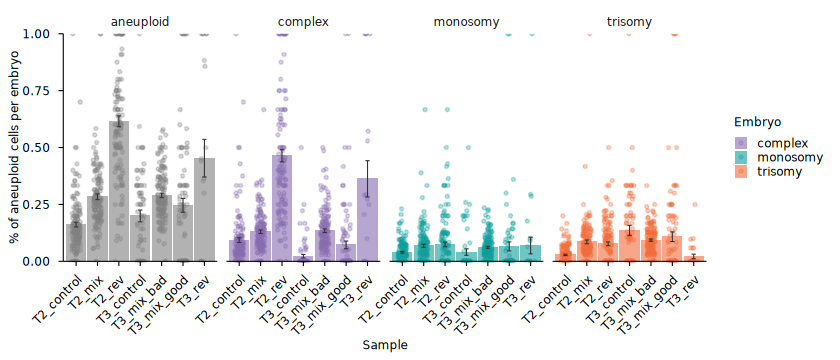

In [64]:
title = "G_per_ploidy_structure"

w <- 7
h <- 3
options(repr.plot.width=w, repr.plot.height=h)

ggbar = ggplot(cell_karyo_long_df, aes(x = sample, y = per, fill = ploidy)) +
  geom_bar(stat = "summary", fun = "mean", position = "dodge", alpha = 0.6)+
  geom_jitter(size = 0.5, width = 0.2, alpha = 0.3, aes(color = ploidy))+
stat_summary(fun.data = "mean_se", geom = "errorbar", width = 0.2, color = "grey20") +
  
  # Labels and theme
  labs(
    x = "Sample",
    y = "% of aneuploid cells per embryo",
    fill = "Embryo",
    color = "Embryo"
  ) +
  settheme +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1)) +
 facet_wrap(~ploidy, ncol = 4)+
 scale_fill_manual(values=color_ploidy)+
 scale_color_manual(values=color_ploidy)

ggsave(plot = ggbar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggbar

### H) % aneuploid per cell type

In [65]:
#summarise
cell_karyo_df_summary <- cell_karyo_df%>%
  filter(!is.na(ploidy) & 
         !is.na(filtered_feature_call) & 
         filtered_feature_call != "fail"  
  )%>%
  mutate(ploidy = factor(ploidy , levels = c("diploid", "monosomy", "trisomy", "complex"))) %>%
  group_by(filtered_feature_call, sample, celltype_coarse, ploidy,.drop = FALSE) %>%
  summarise(count = n()) %>%
  mutate(sum = sum(count)) %>%
  #filter(sum(count) >= 10) %>%
  mutate(percentage = count / sum(count)) %>%
  ungroup()%>% 
  filter(ploidy != "diploid")

`summarise()` has grouped output by 'filtered_feature_call', 'sample',
'celltype_coarse'. You can override using the `.groups` argument.


In [66]:
# 1) base summary (non-diploid), with sum computed BEFORE adding "aneuploid"
base <- cell_karyo_df %>%
  filter(!is.na(ploidy),
         !is.na(filtered_feature_call),
         filtered_feature_call != "fail") %>%
  mutate(ploidy = factor(ploidy, levels = c("diploid","monosomy","trisomy","complex"))) %>%
  group_by(filtered_feature_call, sample, celltype_coarse, ploidy, .drop = FALSE) %>%
  summarise(count = n(), .groups = "drop_last") %>%
  ungroup() %>%
  group_by(filtered_feature_call, sample, celltype_coarse) %>%
  mutate(sum = sum(count)) %>%   # denominator across monosomy/trisomy/complex only
  ungroup() %>%
  mutate(percentage = count / sum)  %>%
  filter(ploidy != "diploid") %>%
  filter(sum >= 5) 

# 2) add "aneuploid" level: count = sum across monosomy+trisomy+complex
aneu <- base %>%
  group_by(filtered_feature_call, sample, celltype_coarse) %>%
  summarise(
    ploidy = "aneuploid",
    count  = sum(count),
    sum    = first(sum),        # keep the original denominator
    .groups = "drop"
  ) %>%
  mutate(percentage = count / sum)

# 3) bind + set factor levels
cell_karyo_df_summary <- bind_rows(base, aneu) %>%
  mutate(ploidy = factor(ploidy,
                         levels = c("aneuploid", "monosomy","trisomy","complex")))


Warning message:
“Removed 247 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 249 rows containing missing values or values outside the scale range
(`geom_point()`).”


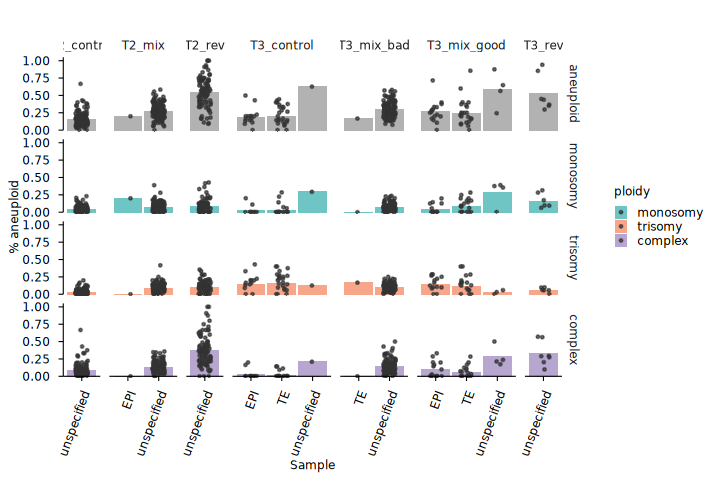

In [67]:
#plot
title = "H_bar_celltype_ploidy_sample"

#df_summary = df_summary%>%
   # filter(sample %in% c("T2_mix", "T2_rev", "T3_rev", "T3_mix_bad", "T3_mix_good", "T3_naive_rev"))

w <- 6
h <- 4
options(repr.plot.width=w, repr.plot.height=h)

gg_bar = ggplot(cell_karyo_df_summary, aes(x = celltype_coarse ,y = percentage ,fill =ploidy))+
            geom_bar(stat = "summary", fun = "mean", position = "dodge", alpha = 0.6)+
  geom_jitter(size = 0.3, width = 0.2, alpha = 0.7, color = "grey20")+
                settheme+
         scale_y_continuous(expand = c(0, 0)
                            , limits = c(0, 1.05)) +
theme(axis.text.x = element_text(colour = "black", angle = 70, hjust = 1))+
  labs(title = "",
       x = "Sample",
       y = "% aneuploid") +
facet_grid(ploidy ~ sample, scales = "free_x", space = "free_x" )+
scale_fill_manual(values = color_ploidy)

                #scale_color_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))

ggsave(plot = gg_bar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)

gg_bar

Warning message:
“Removed 104 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 90 rows containing missing values or values outside the scale range
(`geom_point()`).”


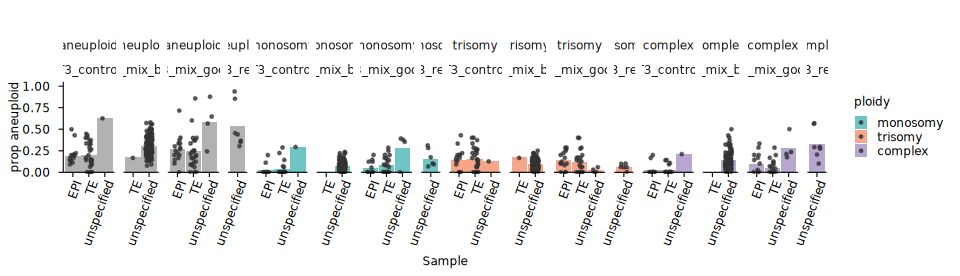

In [68]:
#plot
title = "H_bar_celltype_ploidy_sample_T3"

cell_karyo_df_summary_sub = cell_karyo_df_summary%>%
    filter(sample %in% c("T3_control", "T3_rev", "T3_mix_bad", "T3_mix_good"))

w <- 8
h <- 2.3
options(repr.plot.width=w, repr.plot.height=h)

gg_bar = ggplot(cell_karyo_df_summary_sub, aes(x = celltype_coarse ,y = percentage ,fill =ploidy))+
            geom_bar(stat = "summary", fun = "mean", position = "dodge", alpha = 0.6)+
  geom_jitter(size = 0.3, width = 0.2, alpha = 0.7, color = "grey20")+
                settheme+
         scale_y_continuous(expand = c(0, 0)
                            , limits = c(0, 1.05)) +
theme(axis.text.x = element_text(colour = "black", angle = 70,  vjust=1.1,  hjust = 1.0))+
  labs(title = "",
       x = "Sample",
       y = "prop aneuploid")  +
facet_wrap(ploidy ~ sample, nrow =1, scales = "free_x", space = "free_x" )+
scale_fill_manual(values = color_ploidy)

                #scale_color_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))

ggsave(plot = gg_bar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)

gg_bar

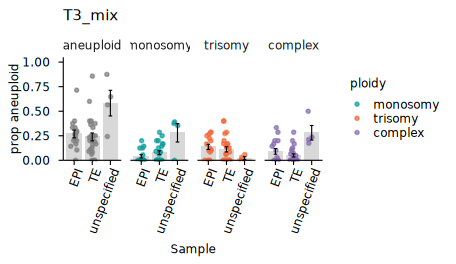

In [69]:
#plot
title = "H_bar_celltype_ploidy_T3mix"

cell_karyo_df_summary_sub = cell_karyo_df_summary%>%
    filter(sample %in% c("T3_mix_good"))

w <- 3.8
h <- 2.2
options(repr.plot.width=w, repr.plot.height=h)

gg_bar = ggplot(cell_karyo_df_summary_sub, aes(x = celltype_coarse ,y = percentage ))+

            geom_bar(stat = "summary", fun = "mean", position = "dodge", alpha = 0.6, width =0.8, fill = "grey")+

  geom_jitter(aes(color =ploidy),  size = 0.5, width = 0.2, height = 0, alpha = 0.7) +  # average bar
    stat_summary(
      fun.data = mean_se, 
      geom = "errorbar",
      position = position_dodge(width = 0.75),
      width = 0.2, 
      color = "black")+
                settheme+
         scale_y_continuous(expand = c(0, 0)
                            , limits = c(0, 1.05)) +
theme(axis.text.x = element_text(colour = "black", angle = 70,  vjust=1.1,  hjust = 1.0))+
  labs(title = "T3_mix",
       x = "Sample",
       y = "prop aneuploid") +
facet_wrap( ~ ploidy , scales = "free_x", space = "free_x" )+
scale_color_manual(values = color_ploidy)

                #scale_color_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))

ggsave(plot = gg_bar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)

gg_bar

In [70]:
library(dplyr); library(tidyr); library(purrr)

check_test <- function(data, group_var = "celltype_coarse", value_var = "percentage",
                       conditions = c("EPI", "TE", "unspecified"), alpha = 0.05) {

  d <- data %>%
    filter(.data[[group_var]] %in% conditions) %>%
    mutate(across(all_of(group_var), ~ factor(.x, levels = conditions))) %>%
    droplevels()

  d %>%
    group_by(ploidy) %>%
    group_modify(~ {
      g <- split(.x[[value_var]], .x[[group_var]])[conditions]
      k <- length(g)
      ns <- sapply(g, function(x) sum(!is.na(x)))

      if (!all(ns >= 3)) {
        return(tibble(
          k = k, n = paste(ns, collapse = "/"),
          shapiro_p_min = NA_real_, levene_p = NA_real_, normal = NA,
          recommended = "too few points (use non-parametric / be cautious)"
        ))
      }

      # normality: test every group, take the worst
      sps <- sapply(g, function(x) shapiro.test(x)$p.value)
      normal <- all(sps > alpha)

      # homogeneity of variance across all k groups (Levene, robust to non-normality)
      lev_p <- tryCatch(
        car::leveneTest(.x[[value_var]] ~ .x[[group_var]])[1, "Pr(>F)"],
        error = function(e) NA_real_
      )
      equal_var <- !is.na(lev_p) && lev_p > alpha

      rec <- if (k == 2) {
        if (normal) { if (equal_var) "Student t-test" else "Welch t-test" }
        else "Wilcoxon rank-sum test"
      } else {
        if (normal) { if (equal_var) "One-way ANOVA + Tukey HSD"
                      else "Welch's ANOVA + Games-Howell" }
        else "Kruskal-Wallis + Dunn's test"
      }

      tibble(
        k = k, n = paste(ns, collapse = "/"),
        shapiro_p_min = min(sps), levene_p = lev_p, normal = normal,
        recommended = rec
      )
    }) %>%
    ungroup()
}

check_test(cell_karyo_df_summary_sub)

ploidy,k,n,shapiro_p_min,levene_p,normal,recommended
<fct>,<int>,<chr>,<dbl>,<dbl>,<lgl>,<chr>
aneuploid,3,16/24/4,9.957389e-03,0.5851179,FALSE,Kruskal-Wallis + Dunn's test
monosomy,3,16/24/4,5.719123e-05,0.2403945,FALSE,Kruskal-Wallis + Dunn's test
trisomy,3,16/24/4,8.950881e-04,0.1457394,FALSE,Kruskal-Wallis + Dunn's test
complex,3,16/24/4,1.451654e-05,0.3578127,FALSE,Kruskal-Wallis + Dunn's test


In [71]:
kw_res <- cell_karyo_df_summary_sub %>%
  group_by(ploidy) %>%
  kruskal_test(percentage ~ celltype_coarse) %>%
  mutate(
    stars = case_when(
      p < 0.0001 ~ "****",
      p < 0.001  ~ "***",
      p < 0.01   ~ "**",
      p < 0.05   ~ "*",
      TRUE       ~ "ns"
    )
  )
kw_res

ploidy,.y.,n,statistic,df,p,method,stars
<fct>,<chr>,<int>,<dbl>,<int>,<dbl>,<chr>,<chr>
aneuploid,percentage,44,6.032257,2,0.04900,Kruskal-Wallis,*
monosomy,percentage,44,6.700839,2,0.03510,Kruskal-Wallis,*
trisomy,percentage,44,3.453930,2,0.17800,Kruskal-Wallis,ns
complex,percentage,44,9.704127,2,0.00781,Kruskal-Wallis,**


In [72]:
dunn_res <- cell_karyo_df_summary_sub %>%
  group_by(ploidy) %>%
  dunn_test(
    percentage ~ celltype_coarse,
    p.adjust.method = "BH"
  )
dunn_res

,ploidy,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<fct>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,aneuploid,percentage,EPI,TE,16,24,-0.8905260,0.373183525,0.37318352,ns
2,aneuploid,percentage,EPI,unspecified,16,4,1.8387234,0.065955875,0.09893381,ns
3,aneuploid,percentage,TE,unspecified,24,4,2.4354506,0.014873254,0.04461976,*
4,monosomy,percentage,EPI,TE,16,24,1.1918275,0.233328895,0.23332890,ns
5,monosomy,percentage,EPI,unspecified,16,4,2.5684910,0.010214235,0.03064271,*
6,monosomy,percentage,TE,unspecified,24,4,1.9463877,0.051608191,0.07741229,ns
7,trisomy,percentage,EPI,TE,16,24,-0.9609923,0.336556041,0.33655604,ns
8,trisomy,percentage,EPI,unspecified,16,4,-1.8251351,0.067980649,0.20394195,ns
9,trisomy,percentage,TE,unspecified,24,4,-1.3148915,0.188546358,0.28281954,ns


### I) % aneuploid per cell type_fine

In [73]:
#summarise
cell_karyo_df_summary <- cell_karyo_df%>%
  filter(!is.na(ploidy) & 
         !is.na(filtered_feature_call) & 
         filtered_feature_call != "fail"  
  )%>%
  mutate(ploidy = factor(ploidy , levels = c("diploid", "monosomy", "trisomy", "complex"))) %>%
  group_by(filtered_feature_call, sample, celltype_fine, ploidy,.drop = FALSE) %>%
  summarise(count = n()) %>%
  mutate(sum = sum(count)) %>%
  #filter(sum(count) >= 10) %>%
  mutate(percentage = count / sum(count) * 100) %>%
  ungroup()%>% 
  filter(ploidy != "diploid")

`summarise()` has grouped output by 'filtered_feature_call', 'sample',
'celltype_fine'. You can override using the `.groups` argument.


Warning message:
“Removed 1217 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1337 rows containing missing values or values outside the scale range
(`geom_point()`).”


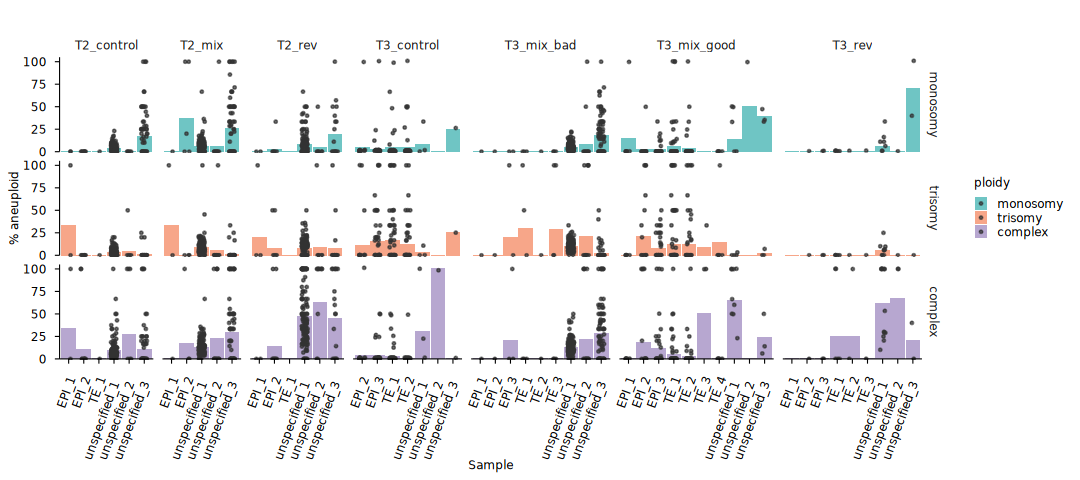

In [74]:
#plot``
title = "C_bar_celltype_ploidy_fine"

#df_summary = df_summary%>%
   # filter(sample %in% c("T2_mix", "T2_rev", "T3_rev", "T3_mix_bad", "T3_mix_good", "T3_naive_rev"))

w <- 9
h <- 4
options(repr.plot.width=w, repr.plot.height=h)

gg_bar = ggplot(cell_karyo_df_summary, aes(x = celltype_fine ,y = percentage ,fill =ploidy))+
            geom_bar(stat = "summary", fun = "mean", position = "dodge", alpha = 0.6)+
  geom_jitter(size = 0.3, width = 0.2, alpha = 0.7, color = "grey20")+
                settheme+
         scale_y_continuous(expand = c(0, 0)
                            , limits = c(0, 105)) +
theme(axis.text.x = element_text(colour = "black", angle = 70, hjust = 1.1))+
  labs(title = "",
       x = "Sample",
       y = "% aneuploid") +
facet_grid(ploidy ~ sample, scales = "free_x", space = "free_x" )+
scale_fill_manual(values = color_ploidy)

                #scale_color_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))

ggsave(plot = gg_bar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)

gg_bar

Warning message:
“Removed 818 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 712 rows containing missing values or values outside the scale range
(`geom_point()`).”


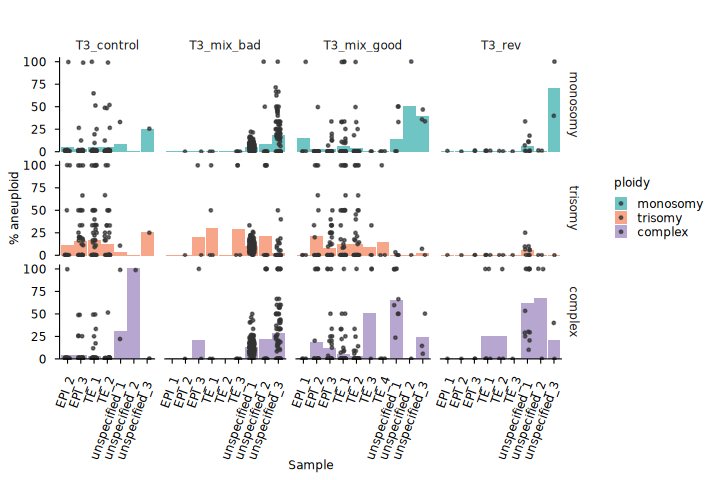

In [75]:
#plot``
title = "C2_bar_celltype_ploidy_fine"

cell_karyo_df_summary_sub = cell_karyo_df_summary%>%
    filter(sample %in% c("T3_control", "T3_rev", "T3_mix_bad", "T3_mix_good"))

w <- 6
h <- 4
options(repr.plot.width=w, repr.plot.height=h)

gg_bar = ggplot(cell_karyo_df_summary_sub, aes(x = celltype_fine ,y = percentage ,fill =ploidy))+
            geom_bar(stat = "summary", fun = "mean", position = "dodge", alpha = 0.6)+
  geom_jitter(size = 0.3, width = 0.2, alpha = 0.7, color = "grey20")+
                settheme+
         scale_y_continuous(expand = c(0, 0)
                            , limits = c(0, 105)) +
theme(axis.text.x = element_text(colour = "black", angle = 70, hjust = 1.1))+
  labs(title = "",
       x = "Sample",
       y = "% aneuploid") +
facet_grid(ploidy ~ sample, scales = "free_x", space = "free_x" )+
scale_fill_manual(values = color_ploidy)

                #scale_color_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))

ggsave(plot = gg_bar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)

gg_bar

### J) time course

In [76]:
#recompute to include the timepoint1 sample

cell_karyo_summary_df <- cell_karyo_df |>
   filter(!(timepoint == "day4" & filtered_feature_call == "fail")) |>
   filter(!(timepoint == "day6" & filtered_feature_call == "fail"))|>
  group_by(sample, dataset, timepoint, Condition, filtered_feature_call) |>

  summarise(

    total = n(), 
    
    n_monosomy = sum(ploidy == "monosomy", na.rm = TRUE),
    n_trisomy  = sum(ploidy == "trisomy", na.rm = TRUE),
    n_complex  = sum(ploidy == "complex", na.rm = TRUE),
    n_aneuploid = sum(ploidy != "diploid", na.rm = TRUE),
    
    per_monosomy = if_else(total > 0, n_monosomy / total, 0),
    per_trisomy = if_else(total > 0, n_trisomy / total, 0),
    per_complex = if_else(total > 0, n_complex / total, 0),
    per_aneuploid = if_else(total > 0, n_aneuploid / total, 0),
    
    .groups = "drop" 
  ) |>
  filter(total > 3)

cell_karyo_long_df <- cell_karyo_summary_df |>
  pivot_longer(
    cols = c(per_monosomy, per_trisomy, per_complex, per_aneuploid),
    names_to = "ploidy",
    values_to = "per"
  ) |>
  mutate(
    ploidy = ploidy |>
      stringr::str_replace("per_", "")
  )

order = c('aneuploid','monosomy','trisomy','complex')
cell_karyo_long_df$ploidy <- factor(cell_karyo_long_df$ploidy , levels = order)
  

In [77]:
#to start the CI from the first time point
my_mean_ci <- function(x, conf.int = 0.95, R = 1000) {
  # If only ONE data point, return that point with zero CI.
  # If multiple points, do a "mean_cl_boot"-like calculation.

  # 0) How many data points do we have in 'x'?
  n <- length(na.omit(x))
  
  if (n == 1) {
    # Use the single point for y, and 0 range for ymin,ymax
    m <- x[!is.na(x)]
    return(data.frame(y = m, ymin = m, ymax = m))
  } else if (n > 1) {
    # We can mimic ggplot2’s "mean_cl_boot" approach or Hmisc::smean.cl.boot
    # Here is a simple example using Hmisc:
    library(Hmisc)
    b <- smean.cl.boot(x, conf.int = conf.int, B = R) 
    # smean.cl.boot returns (Mean, Lower, Upper)
    # so we just reformat into y, ymin, ymax
    return(data.frame(y = b[1], ymin = b[2], ymax = b[3]))
  } else {
    # If no valid data, return all NA
    return(data.frame(y = NA, ymin = NA, ymax = NA))
  }
}

In [78]:
head(cell_karyo_long_df)

sample,dataset,timepoint,Condition,filtered_feature_call,total,n_monosomy,n_trisomy,n_complex,n_aneuploid,ploidy,per
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<fct>,<dbl>
T1_control,Embryo-Imp15265938,day1,Control,NA,4052,165,428,191,784,monosomy,0.04072063
T1_control,Embryo-Imp15265938,day1,Control,NA,4052,165,428,191,784,trisomy,0.10562685
T1_control,Embryo-Imp15265938,day1,Control,NA,4052,165,428,191,784,complex,0.04713722
T1_control,Embryo-Imp15265938,day1,Control,NA,4052,165,428,191,784,aneuploid,0.19348470
T1_rev,Embryo-Imp15265939,day1,Reversine,NA,2787,116,297,1507,1920,monosomy,0.04162182
T1_rev,Embryo-Imp15265939,day1,Reversine,NA,2787,116,297,1507,1920,trisomy,0.10656620


In [79]:
cell_karyo_long_df %>%
  group_by(timepoint, ploidy) %>%
  wilcox_test(
    per ~ Condition,
    p.adjust.method = "none"
  ) 

,timepoint,ploidy,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<fct>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,day1,aneuploid,per,Control,Reversine,1,1,0.0,1.00e+00,1.00e+00,ns
2,day1,monosomy,per,Control,Reversine,1,1,0.0,1.00e+00,1.00e+00,ns
3,day1,trisomy,per,Control,Reversine,1,1,0.0,1.00e+00,1.00e+00,ns
4,day1,complex,per,Control,Reversine,1,1,0.0,1.00e+00,1.00e+00,ns
5,day4,aneuploid,per,Control,Mosaic,145,142,4013.0,4.02e-19,4.02e-19,****
6,day4,aneuploid,per,Control,Reversine,145,106,917.5,1.02e-32,1.02e-32,****
7,day4,aneuploid,per,Mosaic,Reversine,142,106,2012.0,5.81e-23,5.81e-23,****
8,day4,monosomy,per,Control,Mosaic,145,142,8347.5,5.00e-03,5.00e-03,**
9,day4,monosomy,per,Control,Reversine,145,106,6737.5,8.70e-02,8.70e-02,ns


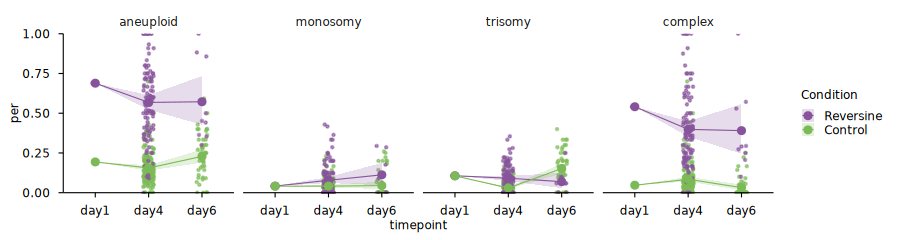

In [80]:
# Plot using ggplot2
title = "J_timecourse_jitter"

w <- 7.5
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

order = c("Reversine","Control", "Mosaic")
cell_karyo_long_df$Condition <- factor(cell_karyo_long_df$Condition , levels = order)


cell_karyo_long_df_sub = cell_karyo_long_df %>%
    subset(Condition %in% c("Reversine","Control"))

gg = ggplot(cell_karyo_long_df_sub, aes(x = timepoint, y = per, color = Condition, fill = Condition, group = Condition)) +
  # 4. Raw data points (directly plotted)
  geom_point(
    # Typically you don't re-specify color/fill mapping here
    # unless you want a different aesthetic. 
    # You can also use position_jitter or position_dodge if needed:
    position = position_jitter(width = 0.1, height = 0),
    alpha = 0.6, 
    size = 0.2
  ) +
  # 1. Ribbon for CI (0-width if only 1 datapoint)
  stat_summary(
    fun.data = my_mean_ci,  # Custom function from previous example
    geom = "ribbon",
    alpha = 0.2,
    color = NA
  ) +
  # 2. Line for the mean
  stat_summary(
    fun.data = my_mean_ci,
    geom = "line"
  ) +
  # 3. Mean point
  stat_summary(
    fun.data = my_mean_ci,
    geom = "point"
  ) +
  facet_grid(~ ploidy) +
  scale_color_manual(values = color_condition) +
  scale_fill_manual(values = color_condition) +
  settheme +
  theme(
    axis.text.x = element_text(angle = 0, hjust = 0.5)
  )+
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1))+
  theme(
    # increase vertical (y) spacing between panels
    panel.spacing.y = unit(0.5, "cm")
  )
ggsave(plot = gg, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gg

In [81]:
#add the point for mosaic 
day1mid_df <- cell_karyo_long_df_sub %>%
  filter(timepoint == "day1", Condition %in% c("Reversine","Control")) %>%
  group_by(ploidy) %>%
  summarise(per = mean(per, na.rm = TRUE), .groups = "drop") %>%
  mutate(x_mid = 1)  # exactly at the first timepoint center
day1mid_df 

ploidy,per,x_mid
<fct>,<dbl>,<dbl>
aneuploid,0.44119875,1
monosomy,0.04117122,1
trisomy,0.10609653,1
complex,0.29393100,1


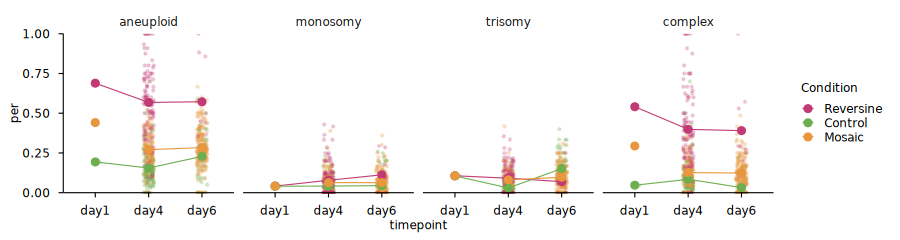

In [82]:
# Plot using ggplot2
title = "J_timecourse_jitter_with_mosaic"

w <- 7.5
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

order = c("Reversine","Control", "Mosaic")
cell_karyo_long_df$Condition <- factor(cell_karyo_long_df$Condition , levels = order)

cell_karyo_long_df_sub = cell_karyo_long_df %>%
    subset(Condition %in% c("Reversine","Control","Mosaic"))

gg = ggplot(cell_karyo_long_df_sub, aes(x = timepoint, y = per, color = Condition, fill = Condition, group = Condition))  +
  # 4. Raw data points (directly plotted)
  geom_point(
    # Typically you don't re-specify color/fill mapping here
    # unless you want a different aesthetic. 
    # You can also use position_jitter or position_dodge if needed:
    position = position_jitter(width = 0.1, height = 0),
    alpha = 0.2, 
    size = 0.2
  ) +
  # # 1. Ribbon for CI (0-width if only 1 datapoint)
  # stat_summary(
  #   fun.data = my_mean_ci,  # Custom function from previous example
  #   geom = "ribbon",
  #   alpha = 0.2,
  #   color = NA
  # ) +
  # 2. Line for the mean
  stat_summary(
    fun.data = my_mean_ci,
    geom = "line"
  ) +
  # 3. Mean point
  stat_summary(
    fun.data = my_mean_ci,
    geom = "point"
  )+
  facet_grid(~ ploidy) +
  scale_color_manual(values = color_condition2) +
  scale_fill_manual(values = color_condition2) +
  settheme +
  theme(
    axis.text.x = element_text(angle = 0, hjust = 0.5)
  )+
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1))+
  theme(
    # increase vertical (y) spacing between panels
    panel.spacing.y = unit(0.5, "cm")
  )+
  geom_point(
    data = day1mid_df,
    aes(x = x_mid, y = per),
    inherit.aes = FALSE,
    color = "#E8973E"
    #size = 0.5
  ) 

ggsave(plot = gg, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gg

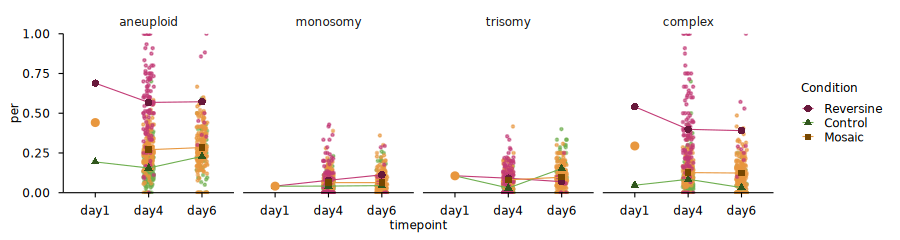

In [83]:
library(ggnewscale)
library(colorspace)

w <- 7.5
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Darker version of your existing palette (keeps hue, drops lightness)
color_condition2_dark <- darken(color_condition2, amount = 0.5)
names(color_condition2_dark) <- names(color_condition2)   # keep Condition names

gg = ggplot(cell_karyo_long_df_sub,
            aes(x = timepoint, y = per, color = Condition, fill = Condition, group = Condition)) +

  # --- JITTER: original colors ---
  geom_point(
    position = position_jitter(width = 0.1, height = 0),
    alpha = 0.6,
    size = 0.2
  ) +
  scale_color_manual(values = color_condition2) +
  scale_fill_manual(values = color_condition2) +

  # --- reset the color scale so the next layers use a new palette ---

  # 2. Line for the mean (darker)
  stat_summary(
    aes(color = Condition),
    fun.data = my_mean_ci,
    geom = "line"
  ) +
 new_scale_color() +
  # 3. Mean point (darker)
  stat_summary(
    aes(color = Condition, shape = Condition),
    fun.data = my_mean_ci,
    geom = "point"
  ) +
  scale_color_manual(values = color_condition2_dark) +

  facet_grid(~ ploidy) +
  settheme +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5)) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1)) +
  theme(panel.spacing.y = unit(0.5, "cm")) +

  geom_point(
    data = day1mid_df,
    aes(x = x_mid, y = per),
    inherit.aes = FALSE,
    color = "#E8973E"
  )

ggsave(plot = gg, filename = sprintf("%s/%s.pdf", outdir, title), w = w, h = h)
gg

In [84]:
unique(cell_karyo_long_df$Condition)

[1] Control   Reversine Mosaic   
Levels: Reversine Control Mosaic

In [85]:
eps <- 1e-6

log_fc <- cell_karyo_long_df_sub %>%
  filter(timepoint %in% c("day1", "day6")) %>%
  group_by(Condition, ploidy, timepoint) %>%
  summarise(mean_per = mean(per, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from = timepoint, values_from = mean_per) %>%
  mutate(log_ratio_day6_day1 = log((day6 + eps) / (day1 + eps))) %>%
  select(Condition, ploidy, log_ratio_day6_day1)

log_fc 

Condition,ploidy,log_ratio_day6_day1
<fct>,<fct>,<dbl>
Reversine,aneuploid,-0.18580786
Reversine,monosomy,0.99355063
Reversine,trisomy,-0.43104656
Reversine,complex,-0.32565530
Control,aneuploid,0.16633293
Control,monosomy,0.08893921
Control,trisomy,0.36348705
Control,complex,-0.38533811
Mosaic,aneuploid,NA


Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_summary()`).”
Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_summary()`).”


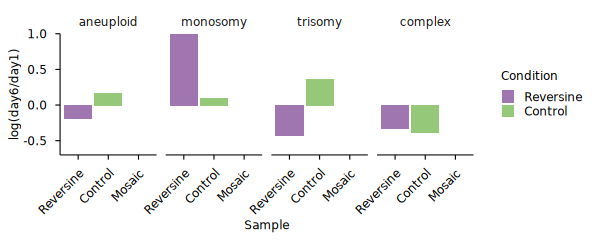

In [86]:
title = "J2_bar"

w <- 5
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

ggbar = ggplot(log_fc , aes(x = Condition, y = log_ratio_day6_day1, fill = Condition)) +
  geom_bar(stat = "summary", fun = "mean", position = "dodge", alpha = 0.8)+
  
  # Labels and theme
  labs(
    x = "Sample",
    y = "log(day6/day1)"
  ) +
  settheme +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
 scale_y_continuous(expand = c(0, 0), limits = c(-0.7, 1)) +
 facet_wrap(~ploidy, ncol = 4)+
  scale_fill_manual(values = color_condition) 

ggsave(plot = ggbar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggbar

### K) Line graph norm log(prop)

In [87]:
screen_counts <- merged_ploidydf %>%
  group_by(chr, ploidy, sample)%>%
  summarise(count= n(), .groups = "drop")
head(screen_counts)

chr,ploidy,sample,count
<int>,<fct>,<chr>,<int>
1,normal,T1_control,4022
1,normal,T1_rev,2236
1,normal,T2_control,6394
1,normal,T2_mix,6296
1,normal,T2_rev,2444
1,normal,T3_control,2344


In [88]:
ref_ploidy <- "normal"
pc <- 0.5

logprop_df <- screen_counts %>%
  group_by(chr, sample) %>%
  mutate(ref_count = count[ploidy == ref_ploidy][1]) %>%
  ungroup() %>%
  filter(ploidy != ref_ploidy) %>%
  mutate(alr = log((count + pc) / (ref_count + pc)))

1. monosomy

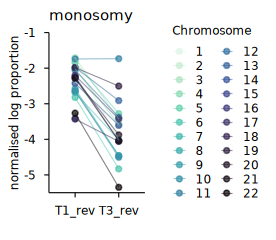

In [89]:
# Subset the data to include only T3_naive_rev and T3_rev
monosomy_subset <- logprop_df %>%
  filter(sample %in% c("T1_rev",  "T3_rev"))%>%
  filter(ploidy == "monosomy")

monosomy_subset$chr <- as.factor(monosomy_subset$chr)
 

# Define plot title and dimensions
title <- "K1_norm_log_prop_mono"
w <- 2.3
h <- 2
options(repr.plot.width = w, repr.plot.height = h)

# Plot
gg <- ggplot(monosomy_subset, aes(x = sample, y = alr, color = chr, group = chr)) +
  geom_point(size = 1, alpha = 0.7) +
  geom_line(aes(group = chr), alpha = 0.5) +  # Connect points by chromosome
  theme_minimal() +
  labs(
    title = "monosomy",
    x = "",
    y = "normalised log proportion",
    color = "Chromosome"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.minor = element_blank()
  ) +
  scale_color_manual(values = col_monosomy)+settheme+
  scale_y_continuous(expand = c(0, 0), limits = c(-5.5, -1))

# Save plot
ggsave(plot = gg, filename = sprintf("%s/%s.pdf", outdir, title), width = w, height = h)

gg

2. trisomy

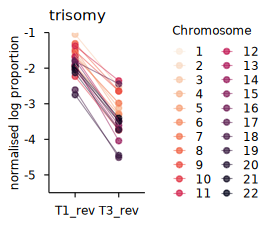

In [90]:
# Subset the data to include only T3_naive_rev and T3_rev
trisomy_subset <- logprop_df %>%
  filter(sample %in% c("T1_rev",  "T3_rev"))%>%
  filter(ploidy == "trisomy")

trisomy_subset$chr <- as.factor(trisomy_subset$chr)
 

# Define plot title and dimensions
title <- "K2_norm_log_prop_trisomy"
w <- 2.3
h <- 2
options(repr.plot.width = w, repr.plot.height = h)

# Plot
gg <- ggplot(trisomy_subset, aes(x = sample, y = alr, color = chr, group = chr)) +
  geom_point(size = 1, alpha = 0.7) +
  geom_line(aes(group = chr), alpha = 0.5) +  # Connect points by chromosome
  theme_minimal() +
  labs(
    title = "trisomy",
    x = "",
    y = "normalised log proportion",
    color = "Chromosome"
  ) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.minor = element_blank()
  ) +
  scale_color_manual(values = col_trisomy)+settheme+
  scale_y_continuous(expand = c(0, 0), limits = c(-5.5, -1))

# Save plot
ggsave(plot = gg, filename = sprintf("%s/%s.pdf", outdir, title), width = w, height = h)

gg

### L) bar delta log prop

In [91]:
alr_long <- logprop_df %>%
  select(chr, ploidy, sample, alr) %>%
  filter(sample %in% c("T1_rev", "T3_rev")) %>%
  pivot_wider(names_from = sample, values_from = alr) %>%
  mutate(T3_T1rev = T3_rev - T1_rev) %>%
  select(chr, ploidy, T3_T1rev) %>%
  pivot_longer(
    cols = T3_T1rev,
    names_to = "sample",
    values_to = "alr"
  )

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`).”


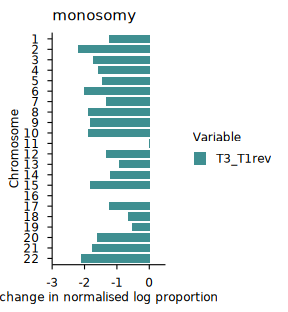

In [92]:
#plot
# Subset the data to include only T3_naive_rev and T3_rev
monosomy_subset <- alr_long %>%
  filter(sample %in% c("T3_T1rev"))%>%
  filter(ploidy == "monosomy")

monosomy_subset$chr <- as.factor(monosomy_subset$chr)
 

title = "L1_bar_logprop_monosomy"

w <- 2.4
h <- 2.6
options(repr.plot.width=w, repr.plot.height=h)

gg <- ggplot(monosomy_subset, aes(x = alr , y = chr, fill = sample)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +
  scale_y_discrete(limits = rev)+
  #facet_wrap(~ variable, ncol = 2) +  # Facet by variable
  labs(
    title = "monosomy",
    x = "change in normalised log proportion",
    y = "Chromosome",
    fill = "Variable"
  ) +
  #scale_fill_viridis_d(option = "mako", begin = 0.2, end = 0.8) +
  scale_fill_manual(values =c("#3F8F91"))+
  settheme+
  scale_x_continuous(expand = c(0, 0), limits = c(-3, 0.5))

# Save the plot
ggsave(plot = gg, filename = sprintf("%s/%s.pdf",outdir, title),width = w, height = h)
gg 

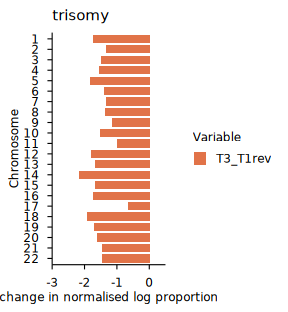

In [93]:
#plot
# Subset the data to include only T3_naive_rev and T3_rev
trisomy_subset <- alr_long %>%
  filter(sample %in% c("T3_T1rev"))%>%
  filter(ploidy == "trisomy")

trisomy_subset$chr <- as.factor(trisomy_subset$chr)
 

title = "L2_bar_logprop_trisomy"

w <- 2.4
h <- 2.6
options(repr.plot.width=w, repr.plot.height=h)

gg <- ggplot(trisomy_subset, aes(x = alr, y = chr, fill = sample)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +
  scale_y_discrete(limits = rev)+
  #facet_wrap(~ variable, ncol = 2) +  # Facet by variable
  labs(
    title = "trisomy",
    x = "change in normalised log proportion",
    y = "Chromosome",
    fill = "Variable"
  ) +
  #scale_fill_viridis_d(option = "mako", begin = 0.2, end = 0.8) +
  scale_fill_manual(values =c("#E17348"))+
  settheme+
  scale_x_continuous(expand = c(0, 0), limits = c(-3, 0.5))

# Save the plot
ggsave(plot = gg, filename = sprintf("%s/%s.pdf",outdir, title),width = w, height = h)
gg 

In [94]:
library(dplyr)
library(tidyr)
library(purrr)

samples_to_test <- c("T1_rev", "T3_rev")
events_to_test <- c("monosomy", "trisomy")
pc <- 0.5

# Count chromosome-level ploidy calls
screen_counts_full <- merged_ploidydf %>%
  count(chr, ploidy, sample, name = "count") %>%
  filter(sample %in% samples_to_test,
         ploidy %in% c("normal", events_to_test)) %>%
  complete(
    chr,
    sample = samples_to_test,
    ploidy = c("normal", events_to_test),
    fill = list(count = 0)
  )

get_count <- function(df, chr_i, sample_i, ploidy_i) {
  x <- df %>%
    filter(chr == chr_i, sample == sample_i, ploidy == ploidy_i) %>%
    pull(count)
  
  if (length(x) == 0) 0 else x[1]
}

fisher_chr_vs_normal <- expand_grid(
  chr = sort(unique(screen_counts_full$chr)),
  ploidy = events_to_test
) %>%
  mutate(result = map2(chr, ploidy, function(chr_i, ploidy_i) {
    
    t1_event  <- get_count(screen_counts_full, chr_i, "T1_rev", ploidy_i)
    t1_normal <- get_count(screen_counts_full, chr_i, "T1_rev", "normal")
    t3_event  <- get_count(screen_counts_full, chr_i, "T3_rev", ploidy_i)
    t3_normal <- get_count(screen_counts_full, chr_i, "T3_rev", "normal")
    
    mat <- matrix(
      c(t1_event, t1_normal,
        t3_event, t3_normal),
      nrow = 2,
      byrow = TRUE,
      dimnames = list(
        sample = c("T1_rev", "T3_rev"),
        outcome = c(ploidy_i, "normal")
      )
    )
    
    ft <- fisher.test(mat)
    
    delta_logratio <- log((t3_event + pc) / (t3_normal + pc)) -
      log((t1_event + pc) / (t1_normal + pc))
    
    tibble(
      T1_event = t1_event,
      T1_normal = t1_normal,
      T3_event = t3_event,
      T3_normal = t3_normal,
      delta_logratio = delta_logratio,
      odds_ratio_T3_vs_T1 = exp(delta_logratio),
      p_value = ft$p.value
    )
  })) %>%
  unnest(result) %>%
  group_by(ploidy) %>%
  mutate(padj = p.adjust(p_value, method = "BH")) %>%
  ungroup() %>%
  mutate(
    direction = case_when(
      delta_logratio < 0 ~ "depleted",
      delta_logratio > 0 ~ "enriched",
      TRUE ~ "no change"
    )
  )


In [95]:
plot_df <- alr_long %>%
  filter(sample == "T3_T1rev") %>%
  left_join(
    fisher_chr_vs_normal %>%
      select(chr, ploidy, p_value, padj, direction),
    by = c("chr", "ploidy")
  ) %>%
  mutate(
    star = case_when(
      padj < 0.001 ~ "***",
      padj < 0.01  ~ "**",
      padj < 0.05  ~ "*",
      TRUE ~ ""
    )
  )

In [96]:
library(dplyr)
library(tidyr)
library(purrr)

samples_to_test <- c("T1_rev", "T3_rev")
events_to_test <- c("monosomy", "trisomy")

# Count chromosome-level ploidy calls
screen_counts_full <- merged_ploidydf %>%
  count(chr, ploidy, sample, name = "count") %>%
  filter(sample %in% samples_to_test,
         ploidy %in% events_to_test) %>%
  complete(
    chr,
    sample = samples_to_test,
    ploidy = events_to_test,
    fill = list(count = 0)
  )

fisher_chr_vs_other_aneuploid <- expand_grid(
  chr = sort(unique(screen_counts_full$chr)),
  ploidy = events_to_test
) %>%
  mutate(result = map2(chr, ploidy, function(chr_i, ploidy_i) {
    
    df <- screen_counts_full %>%
      filter(ploidy == ploidy_i)
    
    t1_chr <- df %>%
      filter(sample == "T1_rev", chr == chr_i) %>%
      pull(count)
    
    t3_chr <- df %>%
      filter(sample == "T3_rev", chr == chr_i) %>%
      pull(count)
    
    t1_total <- df %>%
      filter(sample == "T1_rev") %>%
      summarise(total = sum(count)) %>%
      pull(total)
    
    t3_total <- df %>%
      filter(sample == "T3_rev") %>%
      summarise(total = sum(count)) %>%
      pull(total)
    
    t1_other <- t1_total - t1_chr
    t3_other <- t3_total - t3_chr
    
    mat <- matrix(
      c(t1_chr, t1_other,
        t3_chr, t3_other),
      nrow = 2,
      byrow = TRUE,
      dimnames = list(
        sample = c("T1_rev", "T3_rev"),
        event = c(paste0("chr", chr_i), "other_chromosomes")
      )
    )
    
    ft <- fisher.test(mat)
    
    # Effect size: change in log-odds of this chromosome event
    pc <- 0.5
    delta_log_odds <- log((t3_chr + pc) / (t3_other + pc)) -
      log((t1_chr + pc) / (t1_other + pc))
    
    tibble(
      T1_chr = t1_chr,
      T1_other = t1_other,
      T3_chr = t3_chr,
      T3_other = t3_other,
      T1_fraction = t1_chr / t1_total,
      T3_fraction = t3_chr / t3_total,
      delta_fraction = T3_fraction - T1_fraction,
      delta_log_odds = delta_log_odds,
      odds_ratio_T3_vs_T1 = exp(delta_log_odds),
      p_value = ft$p.value
    )
  })) %>%
  unnest(result) %>%
  group_by(ploidy) %>%
  mutate(padj = p.adjust(p_value, method = "BH")) %>%
  ungroup() %>%
  mutate(
    direction = case_when(
      delta_log_odds < 0 ~ "preferentially depleted",
      delta_log_odds > 0 ~ "relatively enriched",
      TRUE ~ "no change"
    )
  )

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'T3 − T1 log-odds among monosomy events' in 'mbcsToSbcs': - substituted for − (U+2212)”


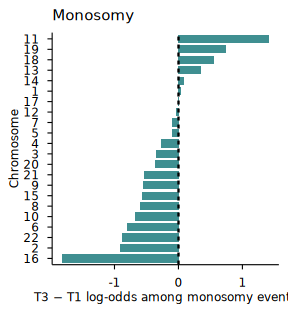

In [97]:
plot_df <- fisher_chr_vs_other_aneuploid %>%
  mutate(
    chr = factor(chr, levels = sort(unique(chr))),
    star = case_when(
      padj < 0.001 ~ "***",
      padj < 0.01  ~ "**",
      padj < 0.05  ~ "*",
      TRUE ~ ""
    )
  )

title = "T3 − T1 log-odds among monosomy"
ggbar= ggplot(plot_df %>% filter(ploidy == "monosomy"),
       aes(x = delta_log_odds, y = reorder(chr, delta_log_odds))) +
  geom_col(width = 0.7, fill = "#3F8F91") +
  geom_vline(xintercept = 0, linetype = "dashed") +
  #geom_text(aes(label = star),
       #     hjust = ifelse((plot_df %>% filter(ploidy == "monosomy"))$delta_log_odds < 0, 1.2, -0.2),
            # size = 3) +
  labs(
    title = "Monosomy",
    x = "T3 − T1 log-odds among monosomy events",
    y = "Chromosome"
  ) +
  settheme


# Save the plot
ggsave(plot = ggbar, filename = sprintf("%s/%s.pdf",outdir, title),width = w, height = h)
ggbar

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'T3 − T1 log-odds among trisomy events' in 'mbcsToSbcs': - substituted for − (U+2212)”


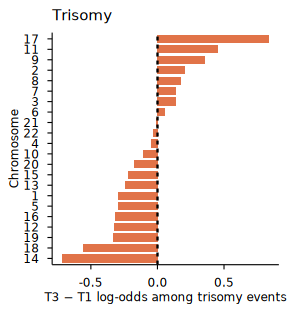

In [98]:
title = "T3 − T1 log-odds among trisomy"

ggbar = ggplot(plot_df %>% filter(ploidy == "trisomy"),
       aes(x = delta_log_odds, y = reorder(chr, delta_log_odds))) +
  geom_col(width = 0.7, fill = "#E17348") +
  geom_vline(xintercept = 0, linetype = "dashed") +
  #geom_text(aes(label = star),
           # hjust = ifelse((plot_df %>% filter(ploidy == "trisomy"))$delta_log_odds < 0, 1.2, -0.2),
           # size = 3) +
  labs(
    title = "Trisomy",
    x = "T3 − T1 log-odds among trisomy events",
    y = "Chromosome"
  ) +
  settheme

# Save the plot
ggsave(plot = ggbar, filename = sprintf("%s/%s.pdf",outdir, title),width = w, height = h)
ggbar

In [99]:
head(logprop_df)

chr,ploidy,sample,count,ref_count,alr
<int>,<fct>,<chr>,<int>,<int>,<dbl>
1,monosomy,T1_control,12,4022,-5.773930
1,monosomy,T1_rev,207,2236,-2.377536
1,monosomy,T2_control,43,6394,-4.990433
1,monosomy,T2_mix,64,6296,-4.581084
1,monosomy,T2_rev,98,2444,-3.211539
1,monosomy,T3_control,6,2344,-5.888025


In [100]:
unique(logprop_df$sample)

[1] "T1_control"   "T1_rev"       "T2_control"   "T2_mix"       "T2_rev"      
 [6] "T3_control"   "T3_mix_bad"   "T3_mix_good"  "T3_naive_rev" "T3_rev"

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Δ log ratio to chromosome-normal cells' in 'mbcsToSbcs': for Δ (U+0394)”


new("standardGeneric", .Data = function (x, y, ...) 
standardGeneric("plot"), generic = "plot", package = "base", 
    group = list(), valueClass = character(0), signature = c("x", 
    "y"), default = new("derivedDefaultMethod", .Data = function (x, 
        y, ...) 
    UseMethod("plot"), target = new("signature", .Data = "ANY", 
        names = "x", package = "methods"), defined = new("signature", 
        .Data = "ANY", names = "x", package = "methods"), generic = "plot"), 
    skeleton = (new("derivedDefaultMethod", .Data = function (x, 
        y, ...) 
    UseMethod("plot"), target = new("signature", .Data = "ANY", 
        names = "x", package = "methods"), defined = new("signature", 
        .Data = "ANY", names = "x", package = "methods"), generic = "plot"))(x, 
        y, ...))
<environment: 0x556001b17380>
attr(,"generic")
[1] "plot"
attr(,"generic")attr(,"package")
[1] "base"
attr(,"package")
[1] "base"
attr(,"group")
list()
attr(,"valueClass")
character(0)
attr(,"signature")
[1] "x" "y"
attr(,"default")
Method Definition (Class "derivedDefaultMethod"):

function (x, y, ...) 
UseMethod("plot")
<bytecode: 0x555fec62fc10>
<environment: namespace:base>

Signatures:
        x    
target  "ANY"
defined "ANY"
attr(,"skeleton")
(new("derivedDefaultMethod", .Data = function (x, y, ...) 
UseMethod("plot"), target = new("signature", .Data = "ANY", names = "x", 
    package = "methods"), defined = new("signature", .Data = "ANY", 
    names = "x", package = "methods"), generic = "plot"))(x, 
    y, ...)
attr(,"class")
[1] "standardGeneric"
attr(,"class")attr(,"package")
[1] "methods"

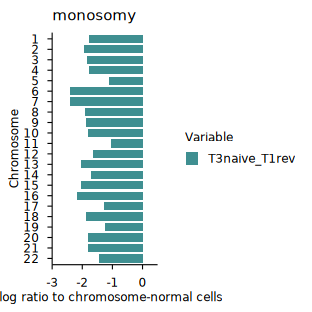

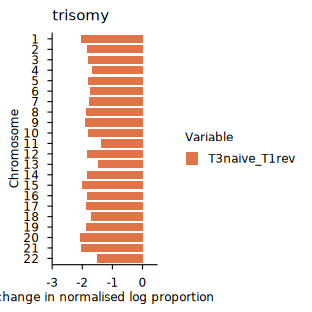

In [101]:
alr_long <- logprop_df %>%
  select(chr, ploidy, sample, alr) %>%
  filter(sample %in% c("T1_rev",'T3_naive_rev')) %>%
  pivot_wider(names_from = sample, values_from = alr) %>%
  mutate(T3naive_T1rev = T3_naive_rev - T1_rev) %>%
  select(chr, ploidy, T3naive_T1rev) %>%
  pivot_longer(
    cols = T3naive_T1rev,
    names_to = "sample",
    values_to = "alr"
  )

#plot
# Subset the data to include only T3_naive_rev and T3_rev
monosomy_subset <- alr_long %>%
  filter(sample %in% c("T3naive_T1rev"))%>%
  filter(ploidy == "monosomy")

monosomy_subset$chr <- as.factor(monosomy_subset$chr)
 

title = "L1_bar_logprop_monosomy_naive"

w <- 2.6
h <- 2.6
options(repr.plot.width=w, repr.plot.height=h)

gg <- ggplot(monosomy_subset, aes(x = alr , y = chr, fill = sample)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +
  scale_y_discrete(limits = rev)+
  #facet_wrap(~ variable, ncol = 2) +  # Facet by variable
  labs(
    title = "monosomy",
    x = "Δ log ratio to chromosome-normal cells",
    y = "Chromosome",
    fill = "Variable"
  ) +
  #scale_fill_viridis_d(option = "mako", begin = 0.2, end = 0.8) +
  scale_fill_manual(values =c("#3F8F91"))+
  settheme+
  scale_x_continuous(expand = c(0, 0), limits = c(-3, 0.5))

# Save the plot
ggsave(plot = gg, filename = sprintf("%s/%s.pdf",outdir, title),width = w, height = h)
gg 

plot
# Subset the data to include only T3_naive_rev and T3_rev
trisomy_subset <- alr_long %>%
  filter(sample %in% c("T3naive_T1rev"))%>%
  filter(ploidy == "trisomy")

trisomy_subset$chr <- as.factor(trisomy_subset$chr)
 

title = "L2_bar_logprop_trisomy_naive"

w <- 2.6
h <- 2.6
options(repr.plot.width=w, repr.plot.height=h)

gg <- ggplot(trisomy_subset, aes(x = alr, y = chr, fill = sample)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +
  scale_y_discrete(limits = rev)+
  #facet_wrap(~ variable, ncol = 2) +  # Facet by variable
  labs(
    title = "trisomy",
    x = "change in normalised log proportion",
    y = "Chromosome",
    fill = "Variable"
  ) +
  #scale_fill_viridis_d(option = "mako", begin = 0.2, end = 0.8) +
  scale_fill_manual(values =c("#E17348"))+
  settheme+
  scale_x_continuous(expand = c(0, 0), limits = c(-3, 0.5))

# Save the plot
ggsave(plot = gg, filename = sprintf("%s/%s.pdf",outdir, title),width = w, height = h)
gg 

In [102]:
unique(logprop_df$sample)

[1] "T1_control"   "T1_rev"       "T2_control"   "T2_mix"       "T2_rev"      
 [6] "T3_control"   "T3_mix_bad"   "T3_mix_good"  "T3_naive_rev" "T3_rev"

Warning message:
“Removed 13 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 13 rows containing missing values or values outside the scale range
(`geom_bar()`).”


new("standardGeneric", .Data = function (x, y, ...) 
standardGeneric("plot"), generic = "plot", package = "base", 
    group = list(), valueClass = character(0), signature = c("x", 
    "y"), default = new("derivedDefaultMethod", .Data = function (x, 
        y, ...) 
    UseMethod("plot"), target = new("signature", .Data = "ANY", 
        names = "x", package = "methods"), defined = new("signature", 
        .Data = "ANY", names = "x", package = "methods"), generic = "plot"), 
    skeleton = (new("derivedDefaultMethod", .Data = function (x, 
        y, ...) 
    UseMethod("plot"), target = new("signature", .Data = "ANY", 
        names = "x", package = "methods"), defined = new("signature", 
        .Data = "ANY", names = "x", package = "methods"), generic = "plot"))(x, 
        y, ...))
<environment: 0x556001b17380>
attr(,"generic")
[1] "plot"
attr(,"generic")attr(,"package")
[1] "base"
attr(,"package")
[1] "base"
attr(,"group")
list()
attr(,"valueClass")
character(0)
attr(,"signature")
[1] "x" "y"
attr(,"default")
Method Definition (Class "derivedDefaultMethod"):

function (x, y, ...) 
UseMethod("plot")
<bytecode: 0x555fec62fc10>
<environment: namespace:base>

Signatures:
        x    
target  "ANY"
defined "ANY"
attr(,"skeleton")
(new("derivedDefaultMethod", .Data = function (x, y, ...) 
UseMethod("plot"), target = new("signature", .Data = "ANY", names = "x", 
    package = "methods"), defined = new("signature", .Data = "ANY", 
    names = "x", package = "methods"), generic = "plot"))(x, 
    y, ...)
attr(,"class")
[1] "standardGeneric"
attr(,"class")attr(,"package")
[1] "methods"

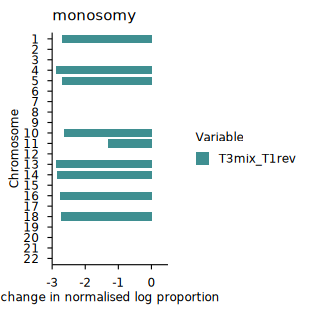

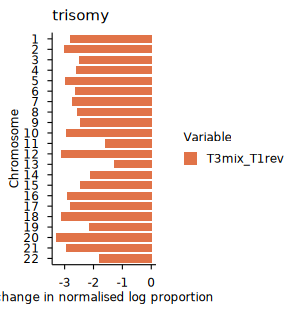

In [103]:
alr_long <- logprop_df %>%
  select(chr, ploidy, sample, alr) %>%
  filter(sample %in% c("T1_rev",'T3_mix_good')) %>%
  pivot_wider(names_from = sample, values_from = alr) %>%
  mutate(T3mix_T1rev = T3_mix_good - T1_rev) %>%
  select(chr, ploidy,T3mix_T1rev) %>%
  pivot_longer(
    cols = T3mix_T1rev,
    names_to = "sample",
    values_to = "alr"
  )

#plot
# Subset the data to include only T3_naive_rev and T3_rev
monosomy_subset <- alr_long %>%
  filter(sample %in% c("T3mix_T1rev"))%>%
  filter(ploidy == "monosomy")

monosomy_subset$chr <- as.factor(monosomy_subset$chr)
 

title = "L1_bar_logprop_monosomy_mix_gd"

w <- 2.6
h <- 2.6
options(repr.plot.width=w, repr.plot.height=h)

gg <- ggplot(monosomy_subset, aes(x = alr , y = chr, fill = sample)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +
  scale_y_discrete(limits = rev)+
  #facet_wrap(~ variable, ncol = 2) +  # Facet by variable
  labs(
    title = "monosomy",
    x = "change in normalised log proportion",
    y = "Chromosome",
    fill = "Variable"
  ) +
  #scale_fill_viridis_d(option = "mako", begin = 0.2, end = 0.8) +
  scale_fill_manual(values =c("#3F8F91"))+
  settheme+
  scale_x_continuous(expand = c(0, 0), limits = c(-3, 0.5))

# Save the plot
ggsave(plot = gg, filename = sprintf("%s/%s.pdf",outdir, title),width = w, height = h)
gg 

plot
# Subset the data to include only T3_naive_rev and T3_rev
trisomy_subset <- alr_long %>%
  filter(sample %in% c("T3mix_T1rev"))%>%
  filter(ploidy == "trisomy")

trisomy_subset$chr <- as.factor(trisomy_subset$chr)
 

title = "L2_bar_logprop_trisomy_mix_gd"

w <- 2.5
h <- 2.6
options(repr.plot.width=w, repr.plot.height=h)

gg <- ggplot(trisomy_subset, aes(x = alr, y = chr, fill = sample)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +
  scale_y_discrete(limits = rev)+
  #facet_wrap(~ variable, ncol = 2) +  # Facet by variable
  labs(
    title = "trisomy",
    x = "change in normalised log proportion",
    y = "Chromosome",
    fill = "Variable"
  ) +
  #scale_fill_viridis_d(option = "mako", begin = 0.2, end = 0.8) +
  scale_fill_manual(values =c("#E17348"))+
  settheme
  #scale_x_continuous(expand = c(0, 0), limits = c(-3, 0.5))

# Save the plot
ggsave(plot = gg, filename = sprintf("%s/%s.pdf",outdir, title),width = w, height = h)
gg 

### M) Number of abnormal chr against change in prop

In [104]:
ab_counts <- merged_cellkaryotype %>%
  group_by(num_abnormal_chr, sample)%>%
  summarise(count= n(), .groups = "drop")
head(ab_counts)

num_abnormal_chr,sample,count
<int>,<chr>,<int>
0,T1_control,3268
0,T1_rev,867
0,T2_control,5568
0,T2_mix,4709
0,T2_rev,1244
0,T3_control,1932


In [105]:
ref_ploidy = 0
pc <- 0.5

log_ab_counts <- ab_counts %>%
  group_by(sample) %>%
  mutate(ref_count = count[num_abnormal_chr == ref_ploidy][1]) %>%
  ungroup() %>%
  filter(num_abnormal_chr != ref_ploidy) %>%
  mutate(alr = log((count + pc) / (ref_count + pc)))

In [106]:
alr_long <- log_ab_counts %>%
  select(num_abnormal_chr, sample, alr) %>%
  filter(sample %in% c("T1_rev", "T3_rev", "T3_naive_rev")) %>%
  #filter(sample %in% c("T1_rev", "T3_rev", "T3_naive_rev")) %>%
  pivot_wider(names_from = sample, values_from = alr) %>%
  mutate(blastoid = T3_rev - T1_rev, 
         naive = T3_naive_rev - T1_rev) %>%
  select(num_abnormal_chr, blastoid, naive) %>%
  pivot_longer(
      cols = c("blastoid", "naive"), 
    names_to = "sample",
    values_to = "alr"
  )

In [107]:
head(alr_long)

num_abnormal_chr,sample,alr
<int>,<chr>,<dbl>
1,blastoid,-0.5434732
1,naive,-0.8565330
2,blastoid,-0.6629811
2,naive,-1.3517418
3,blastoid,-0.8474147
3,naive,-2.0270240


Warning message:
“Removed 13 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 13 rows containing missing values or values outside the scale range
(`geom_point()`).”


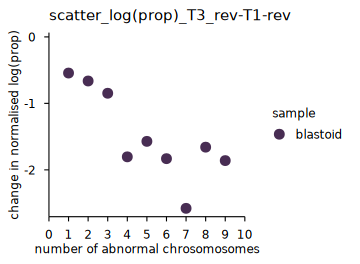

In [108]:
#plot
title = "scatter_log(prop)_T3_rev-T1-rev"

w <- 3
h <- 2.2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(alr_long%>%subset(sample == "blastoid"), aes(x = num_abnormal_chr, y = alr, col = sample)) +
  geom_point(size = 2) +
 # geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  labs(y = "change in normalised log(prop)", 
      x = "number of abnormal chrosomosomes") +
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme+
scale_color_manual(values=c("naive"= "#714684","blastoid"="#482D53"))+
scale_x_continuous(
  expand = c(0, 0),
  limits = c(0,10),
  breaks = seq(0, 10, by = 1))+
#scale_y_continuous( expand = c(0, 0),limits = c(-1.5,0))+  
labs(
    title = title 
   # x = "change in normlog(prop)",
   # y = "Chromosome",
    #fill = "Variable"
  )
                   
ggsave(plot = ggscatter, filename = sprintf("%s/M_%s.pdf",outdir, title), w = w, h = h)
ggscatter

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '≥5' in 'mbcsToSbcs': >= substituted for ≥ (U+2265)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '≥5' in 'mbcsToSbcs': >= substituted for ≥ (U+2265)”


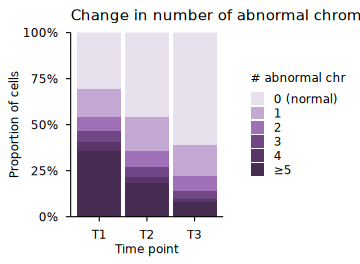

In [109]:
rev_samples <- c("T1_rev", "T2_rev", "T3_rev")

plot_data <- ab_counts %>%
  filter(sample %in% rev_samples) %>%
  mutate(time = factor(gsub("_rev", "", sample), levels = c("T1", "T2", "T3"))) %>%
  group_by(sample, time) %>%
  mutate(total = sum(count)) %>%
  ungroup() %>%
  mutate(prop = count / total)

title = "no_chr_affected"
bar_colours <- c(
  "0 (normal)" = "#E8E0EC",
  "1"          = "#C4A8D4",
  "2"          = "#9F70B5",
  "3"          = "#714684",
  "4"          = "#5A3568",
  "≥5"         = "#482D53"
)

bar_data <- plot_data %>%
  mutate(
    chr_group = case_when(
      num_abnormal_chr == 0 ~ "0 (normal)",
      num_abnormal_chr <= 4 ~ as.character(num_abnormal_chr),
      TRUE                  ~ "≥5"
    ),
    chr_group = factor(chr_group, levels = names(bar_colours))
  )

gg_bar <- ggplot(bar_data, aes(x = time, y = prop, fill = chr_group)) +
  geom_bar(stat = "identity") +
  scale_y_continuous(expand = c(0, 0), labels = scales::percent) +
  scale_fill_manual(values = bar_colours) +
  labs(
    x    = "Time point",
    y    = "Proportion of cells",
    fill = "# abnormal chr",
    title = "Change in number of abnormal chromsomes"
  ) +
  settheme

ggsave("temporal_aneuploidy.pdf", width = 6, height = 2.5)
ggsave(plot = gg_bar, filename = sprintf("%s/M_%s.pdf",outdir, title), w = w, h = h)
gg_bar

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '≥5' in 'mbcsToSbcs': >= substituted for ≥ (U+2265)”


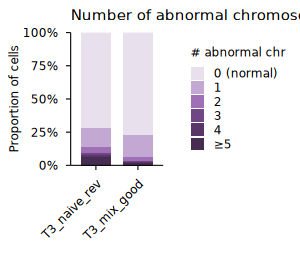

In [110]:
rev_samples <- c("T3_naive_rev", "T3_mix_good")

w <- 2.5
h <- 2.2
options(repr.plot.width=w, repr.plot.height=h)

title <- "no_chr_affected_sample"

bar_colours <- c(
  "0 (normal)" = "#E8E0EC",
  "1"          = "#C4A8D4",
  "2"          = "#9F70B5",
  "3"          = "#714684",
  "4"          = "#5A3568",
  "≥5"         = "#482D53"
)

bar_data <- ab_counts %>%
  filter(sample %in% rev_samples) %>%
  group_by(sample) %>%
  mutate(total = sum(count)) %>%
  ungroup() %>%
  mutate(
    prop = count / total,
    chr_group = case_when(
      num_abnormal_chr == 0 ~ "0 (normal)",
      num_abnormal_chr <= 4 ~ as.character(num_abnormal_chr),
      TRUE                  ~ "≥5"
    ),
    chr_group = factor(chr_group, levels = names(bar_colours)),
    sample = factor(sample, levels = rev_samples)
  )

gg_bar <- ggplot(bar_data, aes(x = sample, y = prop, fill = chr_group)) +
  geom_bar(stat = "identity", width = 0.7) +
  scale_y_continuous(
    labels = scales::percent,
    expand = c(0, 0),
    limits = c(0, 1)
  ) +
  scale_fill_manual(values = bar_colours) +
  labs(
    x = "",
    y = "Proportion of cells",
    fill = "# abnormal chr",
    title = "Number of abnormal chromosomes"
  ) +
  settheme +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

ggsave(
  plot = gg_bar,
  filename = sprintf("%s/M_%s.pdf", outdir, title),
  width = w,
  height = h
)

gg_bar

### N) Bar per_ploidy_structure_g_b

In [111]:
cell_karyo_long_df_sub = cell_karyo_long_df%>%
subset(sample %in%c("T3_mix_good", "T3_mix_bad"))


In [112]:
head(cell_karyo_long_df_sub,3)

sample,dataset,timepoint,Condition,filtered_feature_call,total,n_monosomy,n_trisomy,n_complex,n_aneuploid,ploidy,per
<chr>,<chr>,<chr>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,<fct>,<dbl>
T3_mix_bad,Embryo-Imp15265946,day6,Mosaic,pooled_BC_10,26,3,2,1,6,monosomy,0.11538462
T3_mix_bad,Embryo-Imp15265946,day6,Mosaic,pooled_BC_10,26,3,2,1,6,trisomy,0.07692308
T3_mix_bad,Embryo-Imp15265946,day6,Mosaic,pooled_BC_10,26,3,2,1,6,complex,0.03846154


In [113]:
cell_karyo_long_df_sub_summary <- cell_karyo_long_df_sub %>%
  group_by(ploidy, sample) %>%
  summarise(
    mean_per = mean(per, na.rm = TRUE),
    .groups = "drop"
  )
cell_karyo_long_df_sub_summary

ploidy,sample,mean_per
<fct>,<chr>,<dbl>
aneuploid,T3_mix_bad,0.29629830
aneuploid,T3_mix_good,0.24689447
monosomy,T3_mix_bad,0.06442955
monosomy,T3_mix_good,0.05974746
trisomy,T3_mix_bad,0.09492977
trisomy,T3_mix_good,0.10450374
complex,T3_mix_bad,0.13693898
complex,T3_mix_good,0.08264328


Warning message:
“Removed 43 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 53 rows containing missing values or values outside the scale range
(`geom_point()`).”


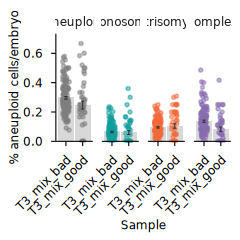

In [114]:
title = "N_per_ploidy_structure_g_b"

w <- 2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

ggbar = ggplot(cell_karyo_long_df_sub , aes(x = sample, y = per, fill = ploidy)) +
  geom_bar(stat = "summary", fun = "mean", position = "dodge",
      alpha = 0.6, fill= "grey")+
  geom_jitter(size = 0.5, width = 0.2, alpha = 0.5, aes(color = ploidy))+
stat_summary(fun.data = "mean_se", geom = "errorbar", width = 0.2, color = "grey20") +
  
  # Labels and theme
  labs(
    x = "Sample",
    y = "% aneuploid cells/embryo"
  ) +
  settheme +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none")+
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.1))) +
 facet_wrap(~ploidy, ncol = 4)+
    scale_fill_manual(values=color_ploidy)+
 scale_color_manual(values=color_ploidy)

ggsave(plot = ggbar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggbar

In [115]:
cell_karyo_long_df_sub %>%
  group_by(ploidy) %>%
  pairwise_wilcox_test(
    per ~ sample,
    p.adjust.method = "none"
  ) 

,ploidy,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<fct>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,aneuploid,per,T3_mix_bad,T3_mix_good,137,45,3782.5,0.022000,0.022000,*
2,monosomy,per,T3_mix_bad,T3_mix_good,137,45,3802.0,0.018000,0.018000,*
3,trisomy,per,T3_mix_bad,T3_mix_good,137,45,3137.5,0.859000,0.859000,ns
4,complex,per,T3_mix_bad,T3_mix_good,137,45,4257.5,0.000125,0.000125,***


Warning message:
“Removed 57 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 42 rows containing missing values or values outside the scale range
(`geom_point()`).”


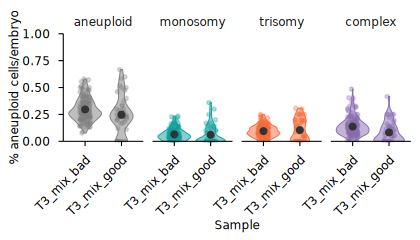

In [116]:
title <- "N2_violin_per_ploidy_structure_g_b"

w <- 3.5
h <- 2
options(repr.plot.width = w, repr.plot.height = h)

ggbar <- ggplot(
  cell_karyo_long_df_sub,
  aes(x = sample, y = per, fill = ploidy, color = ploidy)
) +
  # violin per sample within each ploidy facet
  geom_violin(
    alpha = 0.5,
    linewidth = 0.2,
    trim = TRUE
  ) +
  # jittered points
  geom_jitter(
    size = 0.5,
    width = 0.15,
    alpha = 0.3,
  aes(color = ploidy)
  ) +
  # mean ± SE
  stat_summary(fun = mean, geom = "point", size = 1.2, colour = "grey20") +
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.15, colour = "grey20") +
  labs(
    x = "Sample",
    y = "% aneuploid cells/embryo"
  ) +
  settheme +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none"
  ) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1)) +
  facet_wrap(~ploidy, ncol = 4)+
    scale_fill_manual(values=color_ploidy)+
 scale_color_manual(values=color_ploidy)

ggsave(plot = ggbar, filename = sprintf("%s/%s.pdf", outdir, title), width = w, height = h)
ggbar


In [117]:
head(cell_karyo_long_df_sub, 3)

sample,dataset,timepoint,Condition,filtered_feature_call,total,n_monosomy,n_trisomy,n_complex,n_aneuploid,ploidy,per
<chr>,<chr>,<chr>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,<fct>,<dbl>
T3_mix_bad,Embryo-Imp15265946,day6,Mosaic,pooled_BC_10,26,3,2,1,6,monosomy,0.11538462
T3_mix_bad,Embryo-Imp15265946,day6,Mosaic,pooled_BC_10,26,3,2,1,6,trisomy,0.07692308
T3_mix_bad,Embryo-Imp15265946,day6,Mosaic,pooled_BC_10,26,3,2,1,6,complex,0.03846154


In [118]:
#recompute to include the timepoint1 sample

cell_karyo_summary_df <- cell_karyo_df |>
   filter(!(timepoint == "day4" & filtered_feature_call == "fail")) |>
   filter(!(timepoint == "day6" & filtered_feature_call == "fail"))|>
  group_by(sample, dataset, timepoint, Condition, filtered_feature_call) |>

  summarise(

    total = n(), 
    
    n_monosomy = sum(ploidy == "monosomy", na.rm = TRUE),
    n_trisomy  = sum(ploidy == "trisomy", na.rm = TRUE),
    n_complex  = sum(ploidy == "complex", na.rm = TRUE),
    n_aneuploid = sum(ploidy != "diploid", na.rm = TRUE),
    
    per_monosomy = if_else(total > 0, n_monosomy / total, 0),
    per_trisomy = if_else(total > 0, n_trisomy / total, 0),
    per_complex = if_else(total > 0, n_complex / total, 0),
    per_aneuploid = if_else(total > 0, n_aneuploid / total, 0),
    
    .groups = "drop" 
  ) |>
  filter(total > 2)

cell_karyo_long_df <- cell_karyo_summary_df |>
  pivot_longer(
    cols = c(per_monosomy, per_trisomy, per_complex, per_aneuploid),
    names_to = "ploidy",
    values_to = "per"
  ) |>
  mutate(
    ploidy = ploidy |>
      stringr::str_replace("per_", "")
  )

order = c('aneuploid','monosomy','trisomy','complex')
cell_karyo_long_df$ploidy <- factor(cell_karyo_long_df$ploidy , levels = order)

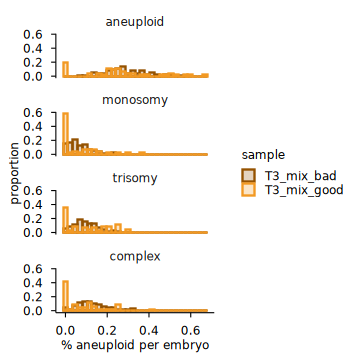

In [119]:
title <- "N3_hist_per_by_ploidy_norm"
w <- 3; h <- 3
options(repr.plot.width = w, repr.plot.height = h)

gghist <- ggplot(cell_karyo_long_df_sub, aes(x = per, fill = sample, colour = sample)) +
  geom_histogram(
    aes(y = after_stat(density * width)),
    bins = 30,
    position = "identity",
    alpha = 0.25
  ) +
  facet_wrap(~ploidy, ncol = 1) +
  #scale_x_continuous(limits = c(0, 1)) +
  labs(x = "% aneuploid per embryo", y = "proportion") +
  settheme +
  scale_fill_manual(values = color_sample) +
  scale_color_manual(values = color_sample) 

# If you want your palette:
# gghist <- gghist + scale_fill_manual(values = custom_palette) + scale_colour_manual(values = custom_palette)

ggsave(plot = gghist, filename = sprintf("%s/%s.pdf", outdir, title), width = w, height = h)
gghist

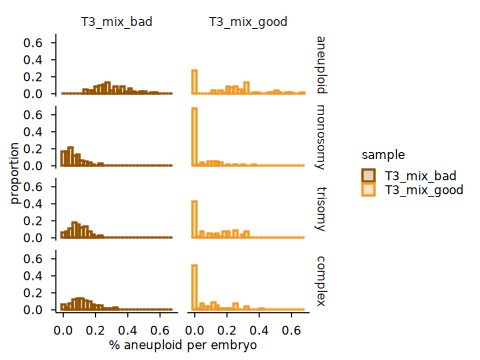

In [120]:
title <- "N4_hist_per_by_ploidy_norm"

cell_karyo_long_df_sub = cell_karyo_long_df%>%
subset(sample %in%c("T3_mix_good", "T3_mix_bad"))


w <- 4; h <- 3
options(repr.plot.width = w, repr.plot.height = h)

gghist <- ggplot(cell_karyo_long_df_sub, aes(x = per, fill = sample, colour = sample)) +
  geom_histogram(
    aes(y = after_stat(density * width)),
    bins = 30,
    position = "identity",
    alpha = 0.25
  ) +
  facet_grid(ploidy~sample) +
  #scale_y(limits = c(0, 1)) +
  labs(x = "% aneuploid per embryo", y = "proportion") +
  settheme +
  scale_fill_manual(values = color_sample) +
  scale_color_manual(values = color_sample) 

# If you want your palette:
# gghist <- gghist + scale_fill_manual(values = custom_palette) + scale_colour_manual(values = custom_palette)

ggsave(plot = gghist, filename = sprintf("%s/%s.pdf", outdir, title), width = w, height = h)
gghist

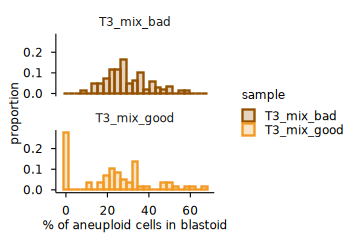

In [121]:
title <- "N4_hist_per_by_ploidy_norm"

cell_karyo_long_df_sub = cell_karyo_long_df%>%
subset(sample %in%c("T3_mix_good", "T3_mix_bad"))%>%
subset(ploidy  == "aneuploid")


w <- 3; h <- 2
options(repr.plot.width = w, repr.plot.height = h)

gghist <- ggplot(cell_karyo_long_df_sub, aes(x = per*100, fill = sample, colour = sample)) +
  geom_histogram(
    aes(y = after_stat(density * width)),
    bins = 25,
    position = "identity",
    alpha = 0.25
  ) +
  facet_wrap(~sample, ncol = 1) +
  #scale_y(limits = c(0, 1)) +
  labs(x = "% of aneuploid cells in blastoid", y = "proportion") +
  settheme +
  scale_fill_manual(values = color_sample) +
  scale_color_manual(values = color_sample) 

# If you want your palette:
# gghist <- gghist + scale_fill_manual(values = custom_palette) + scale_colour_manual(values = custom_palette)

ggsave(plot = gghist, filename = sprintf("%s/%s.pdf", outdir, title), width = w, height = h)
gghist

### O) Scatter ratio of each chr

In [122]:
df_prop <- screen_counts%>%
  group_by(chr, sample) %>%
  mutate(
    total_count = sum(count, na.rm = TRUE),
    prop = count / total_count
  ) %>%
  ungroup()%>%
  select(chr, sample,ploidy, prop)%>%
  pivot_wider(names_from = sample, values_from = prop)

df_prop$chr <- as.factor(df_prop$chr)
 

head(df_prop)

chr,ploidy,T1_control,T1_rev,T2_control,T2_mix,T2_rev,T3_control,T3_mix_bad,T3_mix_good,T3_naive_rev,T3_rev
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,normal,0.992596249,0.80229638,0.982030410,0.969361047,0.90251108,0.995329087,0.97176368,0.985029940,0.96539520,0.95092025
1,monosomy,0.002961500,0.07427341,0.006604208,0.009853734,0.03618907,0.002547771,0.01140313,0.005988024,0.01533622,0.02453988
1,trisomy,0.004442251,0.12343021,0.011365382,0.020785219,0.06129985,0.002123142,0.01683319,0.008982036,0.01926858,0.02453988
2,normal,0.986920039,0.74129889,0.974965443,0.959045420,0.86299852,0.995329087,0.96133797,0.985628743,0.94887928,0.93865031
2,monosomy,0.005923001,0.11804808,0.010597450,0.017551963,0.04837518,0.002123142,0.01455256,0.005389222,0.02202123,0.01533742
2,trisomy,0.007156960,0.14065303,0.014437106,0.023402617,0.08862629,0.002547771,0.02410947,0.008982036,0.02909949,0.04601227


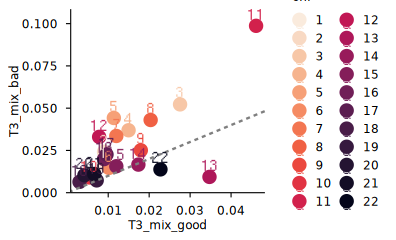

In [123]:
#plot
df_prop_sub = df_prop %>% subset(ploidy == "trisomy")

title = "O1_scatter_T3_bad_T3_good_tri"

w <- 3.3
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T3_mix_good, y = T3_mix_bad, color = chr)) +
  geom_point(size = 3) +

 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme+
  scale_color_viridis_d(option = "rocket", direction = -1)+
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.1)))+
#scale_x_continuous(limits = c(0, 5.2)) +  # Set x-axis limits from 0 to 5
  #scale_y_continuous(limits = c(0, 5.2))  +
  #coord_fixed(ratio = 1) +
geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

In [124]:
cor.test(
  df_prop_sub$T3_mix_good,
  df_prop_sub$T3_mix_bad,
  method = "pearson",
  use = "complete.obs"
)


	Pearson's product-moment correlation

data:  df_prop_sub$T3_mix_good and df_prop_sub$T3_mix_bad
t = 4.1045, df = 20, p-value = 0.000551
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.3560792 0.8542528
sample estimates:
      cor 
0.6761761 


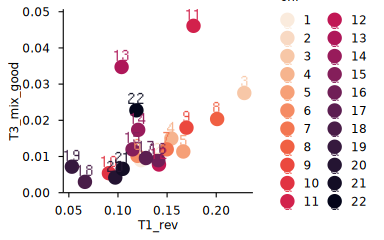

In [125]:
#plot
df_prop_sub = df_prop %>% subset(ploidy == "trisomy")

title = "O1_scatter_T1rev_T3_good_tri"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T1_rev, y = T3_mix_good, color = chr)) +
  geom_point(size = 3) +
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme+
  scale_color_viridis_d(option = "rocket", direction = -1)+
#scale_x_continuous(limits = c(0, 5.2)) +
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.1)))+
  #coord_fixed(ratio = 1) +
#geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

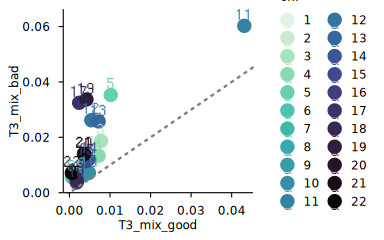

In [126]:
#plot
df_prop_sub = df_prop %>% subset(ploidy == "monosomy")

title = "O2_scatter_T3_bad_T3_good_monosomy"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T3_mix_good, y = T3_mix_bad, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme+
  scale_color_viridis_d(option = "mako", direction = -1)+
  #scale_x_continuous(limits = c(0, 0.05)) +  # Set x-axis limits from 0 to 5
  #scale_y_continuous(limits = c(0, 0.05)) +
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.1)))+
  #coord_fixed(ratio = 1) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


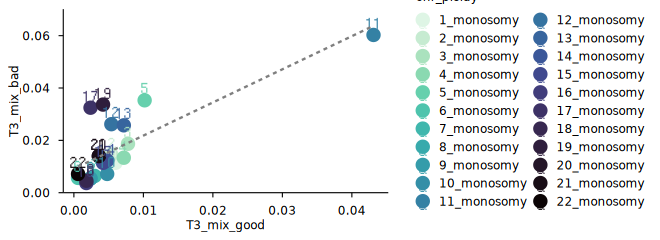

In [127]:
w <- 5.5
h <- 2
options(repr.plot.width=w, repr.plot.height=h)


title = "O2_scatter_T3_bad_T3_good_both"

df_prop_sub$chr <- as.numeric(as.character(df_prop_sub$chr))
df_prop_sub$chr_ploidy <- paste(df_prop_sub$chr, df_prop_sub$ploidy, sep = "_")

mono_chr <- sort(unique(df_prop_sub$chr[df_prop_sub$ploidy == "monosomy"]))
tri_chr  <- sort(unique(df_prop_sub$chr[df_prop_sub$ploidy == "trisomy"]))

mono_levels <- paste(mono_chr, "monosomy", sep = "_")
tri_levels  <- paste(tri_chr, "trisomy", sep = "_")

df_prop_sub$chr_ploidy <- factor(
  df_prop_sub$chr_ploidy,
  levels = c(mono_levels, tri_levels)
)

mono_cols <- viridis(length(mono_levels), option = "mako", direction = -1)
tri_cols  <- viridis(length(tri_levels), option = "rocket", direction = -1)

names(mono_cols) <- mono_levels
names(tri_cols)  <- tri_levels

all_cols <- c(mono_cols, tri_cols)

ggscatter <- ggplot(
  df_prop_sub,
  aes(x = T3_mix_good, y = T3_mix_bad, color = chr_ploidy)
) +
  geom_point(size = 3) +
  geom_text(aes(label = chr), vjust = -0.5, size = 3) +
geom_smooth(method = "lm", se = FALSE,linetype = "dashed", color = "gray50", size = 1, linewidth = 0.5)+
  #geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +
  settheme +
  scale_color_manual(values = all_cols) +
  scale_y_continuous(
    limits = c(0, NA),
    expand = expansion(mult = c(0, 0.1))
  )


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

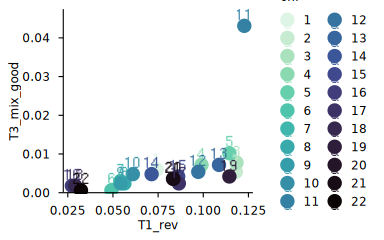

In [128]:
#plot
df_prop_sub = df_prop %>% subset(ploidy == "monosomy")

title = "O1_scatter_T1rev_T3_good_mono"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T1_rev, y = T3_mix_good, color = chr)) +
  geom_point(size = 3) +
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme+
  scale_color_viridis_d(option = "mako", direction = -1)+
#scale_x_continuous(limits = c(0, 5.2)) +
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.1)))+
  #coord_fixed(ratio = 1) +
#geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

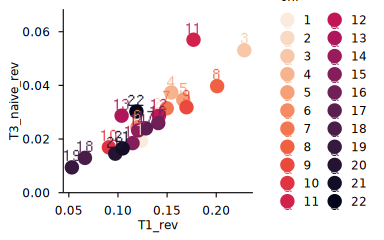

In [129]:
#plot
df_prop_sub = df_prop %>% subset(ploidy == "trisomy")

title = "O1_scatter_T1_rev_T3_rev_tri"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T1_rev, y = T3_naive_rev, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme+
  scale_color_viridis_d(option = "rocket", direction = -1)+
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.2)))+
  #coord_fixed(ratio = 1) +
#geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

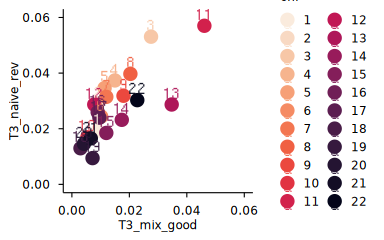

In [130]:
#plot
df_prop_sub = df_prop %>% subset(ploidy == "trisomy")

title = "O1_scatter_T3_mix_good_T3_rev_tri"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T3_mix_good, y = T3_naive_rev, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme+
  scale_color_viridis_d(option = "rocket", direction = -1)+
    #scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.2)))+
  scale_x_continuous(limits = c(0, 0.06)) +
  scale_y_continuous(limits = c(0, 0.06)) +
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

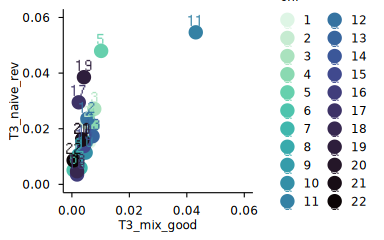

In [131]:
#plot
df_prop_sub = df_prop %>% subset(ploidy == "monosomy")

title = "O1_scatter_T3_mix_good_T3_rev_mono"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T3_mix_good, y = T3_naive_rev, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme+
  scale_color_viridis_d(option = "mako", direction = -1)+
    #scale_y_continuous(limits = c(0, NA),  expand = expansion(mult = c(0, 0.2)))+
  scale_x_continuous(limits = c(0, 0.06)) +
  scale_y_continuous(limits = c(0, 0.06)) +
  #coord_fixed(ratio = 1) +
#geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

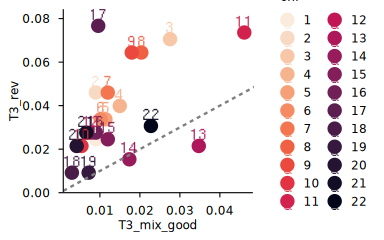

In [132]:
#plot
df_prop_sub = df_prop %>% subset(ploidy == "trisomy")

title = "O1_scatter_T3_mosaic_good_T3_rev_tri"

w <- 3.2
h <- 2

options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T3_mix_good, y = T3_rev, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme+
  scale_color_viridis_d(option = "rocket", direction = -1)+
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.1)))+
  #coord_fixed(ratio = 1) +
geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

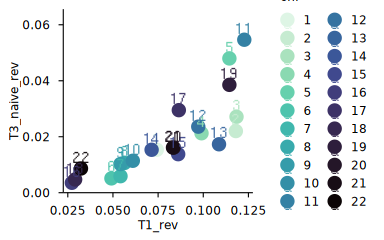

In [133]:
#plot
df_prop_sub = df_prop %>% subset(ploidy == "monosomy")

title = "O1_scatter_T1_rev_T3_rev_mono"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T1_rev, y = T3_naive_rev, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme+
  scale_color_viridis_d(option = "mako", direction = -1)+
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.2)))+
  #coord_fixed(ratio = 1) +
#geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”


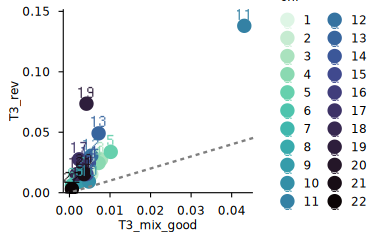

In [134]:
#plot
df_prop_sub = df_prop %>% subset(ploidy == "monosomy")

title = "O1_scatter_T3_mosaic_good_T3_rev_mono"

w <- 3.2
h <- 2

options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T3_mix_good, y = T3_rev, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme+
  scale_color_viridis_d(option = "mako", direction = -1)+
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.1)))+
  #coord_fixed(ratio = 1) +
geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


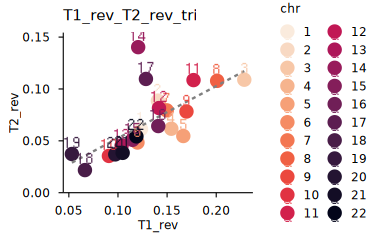

In [135]:
#plot
df_prop_sub = df_prop %>% subset(ploidy == "trisomy")

title = "T1_rev_T2_rev_tri"

w <- 3.2
h <- 2

options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T1_rev, y = T2_rev, color = chr)) +
  geom_point(size = 3) +
 geom_smooth(method = "lm", se = FALSE,linetype = "dashed", color = "gray50", size = 1, linewidth = 0.5) + #trend line
labs(#x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)"
       title = title ) +
settheme+
  scale_color_viridis_d(option = "rocket", direction = -1)+
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.1)))+
  #coord_fixed(ratio = 1) +
  #geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/O1_%s.pdf",outdir, title), w = w, h = h)
ggscatter

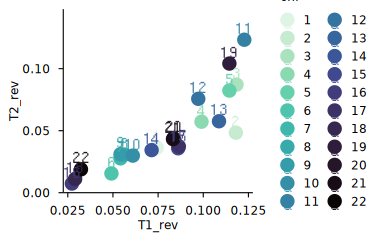

In [136]:
#plot
df_prop_sub = df_prop %>% subset(ploidy == "monosomy")

title = "O1_scatter_T1_rev_T2_rev_mono"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T1_rev, y = T2_rev, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme+
  scale_color_viridis_d(option = "mako", direction = -1)+
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.2)))+
  #coord_fixed(ratio = 1) +
#geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

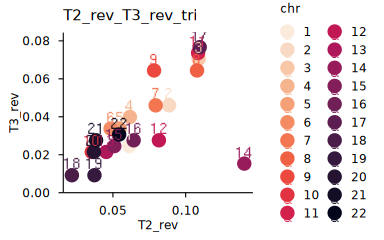

In [137]:
#plot
df_prop_sub = df_prop %>% subset(ploidy == "trisomy")

title = "T2_rev_T3_rev_tri"

w <- 3.2
h <- 2

options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T2_rev, y = T3_rev, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE,linetype = "dashed", color = "gray50", size = 1, linewidth = 0.5) + #trend line
labs(#x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)"
       title = title ) +
settheme+
  scale_color_viridis_d(option = "rocket", direction = -1)+
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.1)))+
  #coord_fixed(ratio = 1) +
  #geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/O1_%s.pdf",outdir, title), w = w, h = h)
ggscatter

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”


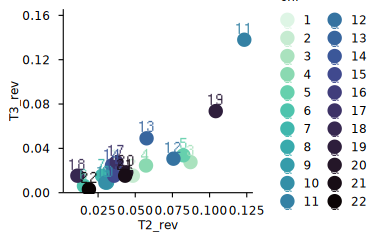

In [138]:
#plot
df_prop_sub = df_prop %>% subset(ploidy == "monosomy")

title = "T1_rev_T3_rev_mono"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T2_rev, y = T3_rev, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme+
  scale_color_viridis_d(option = "mako", direction = -1)+
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.2)))+
  #coord_fixed(ratio = 1) +
#geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/O1_%s.pdf",outdir, title), w = w, h = h)
ggscatter

#### find out enriched chromosomes by CLR(centre log ratio (CLR) transformation)

In [139]:
#subset and reformat
df_prop_sub <- df_prop %>%
  mutate(ploidy_chr = paste(ploidy, chr, sep = "_")) %>%
  filter(ploidy != "normal")

mat <- rbind(
  T3_mix_bad  = df_prop_sub$T3_mix_bad,
  T3_mix_good = df_prop_sub$T3_mix_good
)

mat[mat <= 0] <- 1e-6

#apply CLR
mat_clr <- as.matrix(clr(mat))

delta_clr <- mat_clr["T3_mix_good", ] - mat_clr["T3_mix_bad", ]

res <- tibble(
  ploidy_chr = df_prop_sub$ploidy_chr,
  clr_bad = as.numeric(mat_clr["T3_mix_bad", ]),
  clr_good = as.numeric(mat_clr["T3_mix_good", ]),
  delta_clr = as.numeric(delta_clr)
) %>%
  arrange(desc(delta_clr))

res

ploidy_chr,clr_bad,clr_good,delta_clr
<chr>,<dbl>,<dbl>,<dbl>
trisomy_13,-0.53152917,1.64699233,2.17852150
trisomy_22,-0.14168938,1.22413548,1.36582486
trisomy_14,0.04456145,0.95384515,0.90928370
trisomy_19,-0.78118385,0.07145597,0.85263982
trisomy_15,-0.01606317,0.58228159,0.59834476
trisomy_9,0.45654124,0.98774670,0.53120546
monosomy_11,1.33309165,1.86321544,0.53012379
trisomy_6,-0.08060169,0.41976266,0.50036435
monosomy_10,-0.79622173,-0.33400914,0.46221259


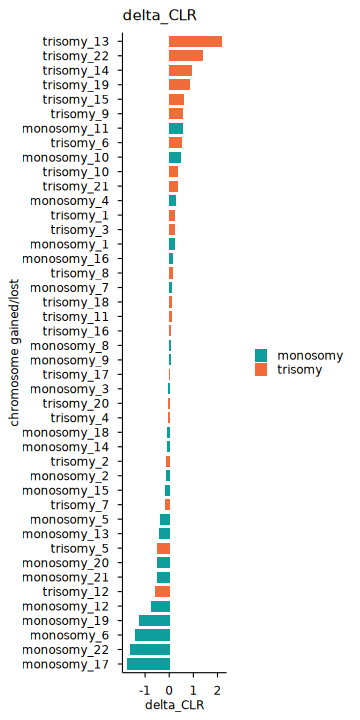

In [140]:
#plot

title = "O_CLR"

w <- 3
h <- 6
options(repr.plot.width=w, repr.plot.height=h)

res2 <- res %>%
  mutate(
      chr = sub("^[^_]+_", "", ploidy_chr),
    fill_group = case_when(
      str_detect(ploidy_chr, "monosomy") ~ "monosomy",
      str_detect(ploidy_chr, "trisomy")  ~ "trisomy",
      TRUE ~ "other"
    ),
    ploidy_chr = fct_reorder(ploidy_chr, delta_clr, .desc = TRUE)
  )

gg <- ggplot(res2, aes(x = delta_clr, y = ploidy_chr, fill = fill_group)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.7) +
  scale_y_discrete(limits = rev)+
  #facet_wrap(~ variable, ncol = 2) +  # Facet by variable
  labs(
    title = "delta_CLR",
    x = "delta_CLR",
    y = "chromosome gained/lost",
    fill = ""
  ) +
  scale_fill_manual(values = c(
    monosomy = "#109E9D",
    trisomy  = "#F26B3B",
    other    = "grey70"
  )) +
  settheme
  #scale_x_continuous(expand = c(0, 0), limits = c(-3, 0.5))

# Save the plot
ggsave(plot = gg, filename = sprintf("%s/%s.pdf",outdir, title),width = w, height = h)
gg 

In [141]:
head(res2)

ploidy_chr,clr_bad,clr_good,delta_clr,chr,fill_group
<fct>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
trisomy_13,-0.53152917,1.64699233,2.1785215,13,trisomy
trisomy_22,-0.14168938,1.22413548,1.3658249,22,trisomy
trisomy_14,0.04456145,0.95384515,0.9092837,14,trisomy
trisomy_19,-0.78118385,0.07145597,0.8526398,19,trisomy
trisomy_15,-0.01606317,0.58228159,0.5983448,15,trisomy
trisomy_9,0.45654124,0.98774670,0.5312055,9,trisomy


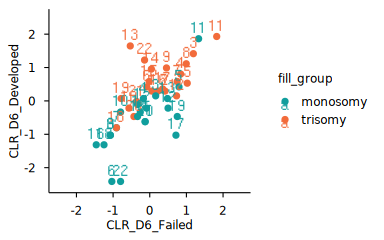

In [142]:
#plot


title = "O1_CLR_developed_loss"

w <- 3.2
h <- 2

options(repr.plot.width=w, repr.plot.height=h)


ggscatter <- ggplot(res2, aes(x = clr_bad, y = clr_good, color = fill_group)) +
  geom_point(size = 1) +
  #geom_abline(intercept = 0, slope = slope0, color = "grey", linewidth = 0.5, linetype = "dashed") +
   #scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.1)))+
   #scale_x_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.1)))+
  scale_x_continuous(limits = c(-2.5, 2.5)) +
  scale_y_continuous(limits = c(-2.5, 2.5)) +
  scale_color_manual(values = c(
    monosomy = "#109E9D",
    trisomy  = "#F26B3B",
    other    = "grey70"
  ))+  labs(
    x = "CLR_D6_Failed",
    y = "CLR_D6_Developed"
  ) +
  #geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +
  geom_text(aes(label = chr), vjust = -0.5, size = 3)+
  settheme 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

In [143]:
#subset and reformat
df_prop_sub <- df_prop %>%
  mutate(ploidy_chr = paste(ploidy, chr, sep = "_")) %>%
  filter(ploidy == "trisomy")

mat <- rbind(
  T3_mix_bad  = df_prop_sub$T3_mix_bad,
  T3_mix_good = df_prop_sub$T3_mix_good
)

mat[mat <= 0] <- 1e-6

#apply CLR
mat_clr <- as.matrix(clr(mat))

delta_clr <- mat_clr["T3_mix_good", ] - mat_clr["T3_mix_bad", ]

res <- tibble(
  ploidy_chr = df_prop_sub$ploidy_chr,
  clr_bad = as.numeric(mat_clr["T3_mix_bad", ]),
  clr_good = as.numeric(mat_clr["T3_mix_good", ]),
  delta_clr = as.numeric(delta_clr)
) %>%
  arrange(desc(delta_clr))

res

ploidy_chr,clr_bad,clr_good,delta_clr
<chr>,<dbl>,<dbl>,<dbl>
trisomy_13,-0.762801775,1.09451639,1.85731816
trisomy_22,-0.372961984,0.67165954,1.04462152
trisomy_14,-0.186711149,0.40136921,0.58808036
trisomy_19,-1.012456451,-0.48101997,0.53143648
trisomy_15,-0.247335771,0.02980565,0.27714142
trisomy_9,0.225268640,0.43527076,0.21000212
trisomy_6,-0.311874292,-0.13271328,0.17916102
trisomy_10,-0.798308463,-0.76870204,0.02960642
trisomy_21,-0.592176257,-0.56803135,0.02414491


#### by cell type

In [144]:
screen_counts_2 <- merged_ploidydf %>% subset(sample == "T3_mix_good")%>% 
  group_by(chr, ploidy, celltype_coarse)%>%
  summarise(count= n(), .groups = "drop")%>%
  group_by(chr, ploidy) %>%
  mutate(
    EPI_TE_total = sum(count[celltype_coarse %in% c("EPI", "TE")], na.rm = TRUE),
    EPI_TE_total = if_else(celltype_coarse == "unspecified", count, EPI_TE_total)
  ) %>%
  ungroup()

In [145]:
head(screen_counts_2)

chr,ploidy,celltype_coarse,count,EPI_TE_total
<int>,<fct>,<chr>,<int>,<int>
1,normal,EPI,574,1561
1,normal,TE,987,1561
1,normal,unspecified,84,84
1,monosomy,EPI,2,5
1,monosomy,TE,3,5
1,monosomy,unspecified,5,5


In [146]:
df_prop_2 <- screen_counts_2%>%
  group_by(chr, celltype_coarse) %>%
  mutate(
    total_count = sum(count, na.rm = TRUE),
    prop = count / total_count
  ) %>%
  ungroup()%>%
  select(chr, celltype_coarse, ploidy, prop)%>%
  pivot_wider(names_from = celltype_coarse, values_from = prop)

df_prop_2$chr <- as.factor(df_prop_2$chr)

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_text()`).”


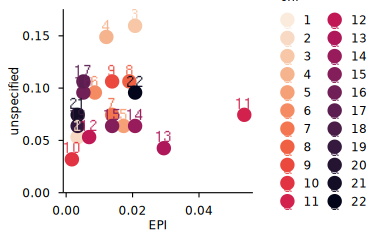

In [147]:
#plot
df_prop_sub = df_prop_2 %>% subset(ploidy == "trisomy")

title = "O1_scatter_EPI_unspecified_tri"

w <- 3.2
h <- 2

options(repr.plot.width=w, repr.plot.height=h)

# fit y ~ 0 + x  (through origin)
fit0 <- lm(unspecified ~ 0 + EPI, data = df_prop_sub)

slope0 <- coef(fit0)[["EPI"]]

ggscatter <- ggplot(df_prop_sub, aes(x = EPI, y = unspecified, color = chr)) +
  geom_point(size = 3) +
  #geom_abline(intercept = 0, slope = slope0, color = "grey", linewidth = 0.5, linetype = "dashed") +
  settheme +
  scale_color_viridis_d(option = "rocket", direction = -1) +
    scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.1)))+
  #scale_x_continuous(limits = c(0, 0.05)) +
  #scale_y_continuous(limits = c(0, 0.2)) +
  #geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +
  geom_text(aes(label = chr), vjust = -0.5, size = 3)


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”


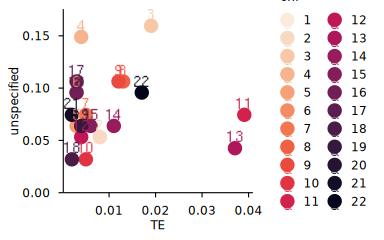

In [148]:
#plot
df_prop_sub = df_prop_2 %>% subset(ploidy == "trisomy")

title = "O1_scatter_TE_unspecified_tri"

w <- 3.2
h <- 2

options(repr.plot.width=w, repr.plot.height=h)

fit0 <- lm(unspecified ~ 0 + TE, data = df_prop_sub)

slope0 <- coef(fit0)[["TE"]]

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = TE, y = unspecified, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme +
  #geom_abline(intercept = 0, slope = slope0, color = "grey", linewidth = 0.5, linetype = "dashed") +
  scale_color_viridis_d(option = "rocket", direction = -1)+
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.1)))+
#scale_x_continuous(limits = c(0, 0.05)) +  # Set x-axis limits from 0 to 5
#  scale_y_continuous(limits = c(0, 0.2))  +
  #coord_fixed(ratio = 1) +
   #geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_text()`).”


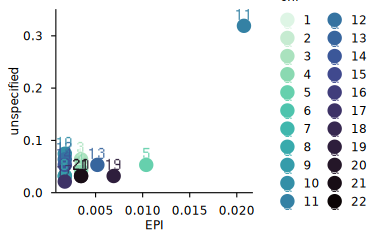

In [149]:
#plot
df_prop_sub = df_prop_2 %>% subset(ploidy == "monosomy")

title = "O1_scatter_EPI_unspecified_mono"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# fit y ~ 0 + x  (through origin)
fit0 <- lm(unspecified ~ 0 + EPI, data = df_prop_sub)

slope0 <- coef(fit0)[["EPI"]]

ggscatter <- ggplot(df_prop_sub, aes(x = EPI, y = unspecified, color = chr)) +
  geom_point(size = 3) +
  #geom_abline(intercept = 0, slope = slope0, color = "grey", linewidth = 0.5, linetype = "dashed") +
  settheme +
  scale_color_viridis_d(option = "mako", direction = -1) +
    scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.1)))+
  #scale_x_continuous(limits = c(0, 0.05)) +
  #scale_y_continuous(limits = c(0, 0.25)) +
  #geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +
  geom_text(aes(label = chr), vjust = -0.5, size = 3)


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 8 rows containing missing values or values outside the scale range
(`geom_text()`).”


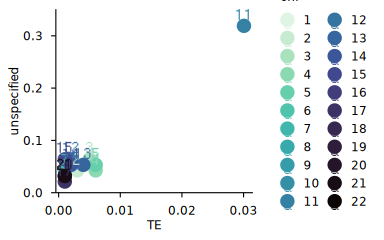

In [150]:
#plot
df_prop_sub = df_prop_2 %>% subset(ploidy == "monosomy")

title = "O1_scatter_TE_unspecified_mono"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

fit0 <- lm(unspecified ~ 0 + TE, data = df_prop_sub)

slope0 <- coef(fit0)[["TE"]]

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = TE, y = unspecified, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  #labs(x = "Percentage of Monosomy Cells (T1_rev)", 
     #  y = "Percentage of Monosomy Cells (T1_control)", 
       #title = "Scatter Plot of Monosomy Cell Percentages by Chromosome") +
settheme +
  #geom_abline(intercept = 0, slope = slope0, color = "grey", linewidth = 0.5, linetype = "dashed") +
  scale_color_viridis_d(option = "mako", direction = -1) +
    scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.1)))+
#scale_x_continuous(limits = c(0, 0.075)) +  # Set x-axis limits from 0 to 5
  #scale_y_continuous(limits = c(0, 0.25))  +
  #coord_fixed(ratio = 1) +
  # geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

### P) Scatter per type aneuploid against aneuploidy

In [151]:
reformatted_cell_karyo = cell_karyo_long_df%>%
  group_by(sample, filtered_feature_call, dataset, timepoint, Condition) %>%
  mutate(per_aneuploid = per[ploidy == "aneuploid"][1]) %>%
  filter(per_aneuploid != 0)%>%
  filter(ploidy != "aneuploid")%>%
  filter(filtered_feature_call != "fail")%>%
  mutate(
    per_in_aneuploid = 
      per / sum(per))%>%
  ungroup()

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


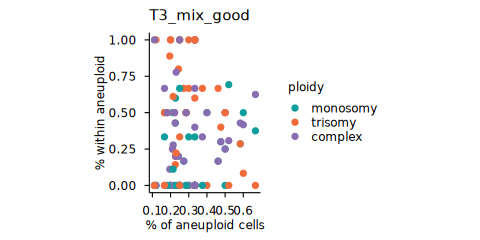

In [152]:
#plot
reformatted_cell_karyop_sub = reformatted_cell_karyo %>% subset(sample == "T3_mix_good")

title = "P1_scatter_T3good"

w <- 4
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(reformatted_cell_karyop_sub, aes(x = per_aneuploid, y = per_in_aneuploid , color = ploidy)) +
      geom_point(size = 1) +
    labs(x = "% of aneuploid cells", 
     y = "% within aneuploid", 
    title = "T3_mix_good") +
    settheme+
    scale_fill_manual(values=color_ploidy)+
    scale_color_manual(values=color_ploidy)+
    coord_fixed(ratio = 0.8) 

ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '≤50%' in 'mbcsToSbcs': <= substituted for ≤ (U+2264)”


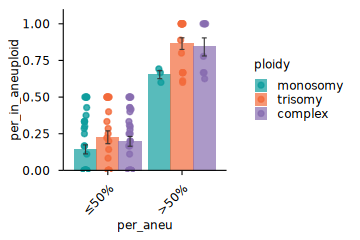

In [153]:
# 1) Bin x-values (per_aneuploid_blastoid) into two groups
blastoid_celltype_binned <- reformatted_cell_karyop_sub %>%
  mutate(
    per_aneu = cut(
      per_in_aneuploid,
      breaks = c(-Inf, 0.5, Inf),                 # change 0.5 if you prefer another split
      labels = c("≤50%", ">50%")
    )
  )

# 2) Bar chart: mean prop cell type per bin, per celltype
w <- 3
h <- 2
options(repr.plot.width = w, repr.plot.height = h)


title = "P2_bar_T3good"

gg_bar <- ggplot(
  blastoid_celltype_binned,
  aes(
    x    = per_aneu,
    y    = per_in_aneuploid,
    fill = ploidy
  )
) +
  geom_bar(
    stat     = "summary",
    fun      = "mean",
    position = position_dodge(width = 0.9),
    alpha    = 0.7
  ) +
  # dots: one per blastoid, jittered & dodged
  geom_point(
    aes(color = ploidy),
    position = position_jitterdodge(
      jitter.width = 0.1,
      dodge.width  = 0.9
    ),
    size  = 1,
    alpha = 0.8
  ) +
  # optional error bars: SE of the mean per bin & celltype
  stat_summary(
    fun.data = "mean_se",
    geom     = "errorbar",
    position = position_dodge(width = 0.9),
    width    = 0.2,
    color    = "grey20"
  ) +settheme+
    scale_y_continuous(
    expand = c(0, 0),limits = c(0, 1.1))+
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )+
    scale_fill_manual(values=color_ploidy)+
    scale_color_manual(values=color_ploidy)


ggsave(
  plot     = gg_bar,
  filename = sprintf("%s/%s.pdf", outdir, title),
  width    = w,
  height   = h
)

gg_bar


### Q) plot heatmap for each blastoid

In [154]:
joint_meta = cell_chr_df %>%
    mutate(ploidy_col = case_when(
      ploidy == "trisomy" ~ 3,
      ploidy == "monosomy" ~ 1,
      TRUE ~ 2))

In [155]:
ploidy_heat_df = dcast(joint_meta, cell+filtered_feature_call + sample + celltype_coarse ~ chr, value.var="ploidy_col")

In [156]:
#add color
ploidy_heat_df  = ploidy_heat_df %>%
    mutate(plot_var = case_when(
   celltype_coarse == "EPI"~"#D0555E", 
   celltype_coarse == "TE"~"#61A59B",
   celltype_coarse == "unspecified"~"#676767"
  ))

In [157]:
ploidy_heat_df = ploidy_heat_df[order(ploidy_heat_df$celltype_coarse, decreasing = TRUE),]

In [158]:
plot_heatmaps_for_condition <- function(ploidy_heat_df,
                                        condition
) {
    cols = 4
    min_n = 5
    png_w = 500
    png_h = 400

  embryo_analyse <- ploidy_heat_df %>%
    filter(sample == condition,
           filtered_feature_call != "fail",
           filtered_feature_call != "") %>%
    count(filtered_feature_call, name = "n") %>%
    filter(n > min_n)

  embryos <- embryo_analyse$filtered_feature_call

  if (length(embryos) == 0) {
    message(sprintf("No embryos found for condition %s (n>%d). Skipping.", condition, min_n))
    return(invisible(NULL))
  }

  plot_list <- vector("list", length(embryos))
  names(plot_list) <- embryos

  for (embryo_i in embryos) {

    cnv_embryo <- ploidy_heat_df %>%
      filter(sample == condition, filtered_feature_call == embryo_i)

    if (nrow(cnv_embryo) == 0) next

    rownames(cnv_embryo) <- cnv_embryo$cell
    plot_var_list <- cnv_embryo$plot_var

    # keep chr1..chr22 columns (as characters "1":"22")
    cnv_mat <- cnv_embryo[, as.character(1:22)]
    cnv_mat <- as.matrix(cnv_mat)

    my_palette <- if (1 %in% cnv_mat) c("#109E9D", "grey90", "#F26B3B") else c("grey90", "#F26B3B")

    tmp <- tempfile(fileext = ".png")
    png(tmp, width = png_w, height = png_h)

    heatmap.2(
      x = cnv_mat,
      Colv = FALSE, Rowv = TRUE,
      dendrogram = "none",
      col = my_palette,
      RowSideColors = plot_var_list,
      trace = "none",
      main = embryo_i,
      sepcolor = "WHITE",
      colsep = 1:ncol(cnv_mat),
      rowsep = 1:nrow(cnv_mat),
      sepwidth = c(0.05, 0.05),
      cexRow = 1, cexCol = 1,
      margins = c(1, 1),
      key = FALSE,
      lwid = c(0.1, 4),
      lhei = c(0.8, 4)
    )

    dev.off()

    img <- png::readPNG(tmp)
    plot_list[[embryo_i]] <- grid::rasterGrob(img, interpolate = TRUE)

    unlink(tmp)
  }

  # drop any NULL grobs (in case of missing embryos)
  plot_list <- plot_list[!vapply(plot_list, is.null, logical(1))]
  n <- length(plot_list)
  if (n == 0) return(invisible(NULL))

  rows <- ceiling(n / cols)

  pdf(
    file = sprintf("%s/Q_heatmap_embryos_%s.pdf", outdir, condition),
    width = 5 * cols,
    height = 4 * rows
  )
  gridExtra::grid.arrange(grobs = plot_list, ncol = cols)
  dev.off()

  invisible(plot_list)
}


In [159]:
plot_heatmaps_for_condition(ploidy_heat_df, "T3_rev")
plot_heatmaps_for_condition(ploidy_heat_df, "T3_mix_good")
plot_heatmaps_for_condition(ploidy_heat_df, "T3_mix_bad")

### R) bar cell type, chr

In [160]:
head(merged_ploidydf,3)

,cell,chr,ploidy,X,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse
,<chr>,<int>,<fct>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>
1,AAACCTGAGCGATCCC-1_Embryo-Imp15265938,1,normal,0,Embryo-Imp15265938,0.07129456,False,0.08256881,-0.6249869,1,0.9147751,4923,17150,481,2.804665,4445,25.91837,low,0.2910713,-0.075246060,S,8,0.4381818,unknown,low quality,T1_control,day1,Control,Naïve,4923,0.3239384,11,2,1,10,unspecified,7,unspecified_2,unspecified
2,AAACCTGGTAGCGTCC-1_Embryo-Imp15265938,1,normal,9,Embryo-Imp15265938,0.09309967,False,0.08256881,-0.6249869,1,0.9147751,7621,42425,1402,3.304655,10427,24.57749,high,0.3733255,0.055389035,S,8,0.8384416,diff,TE,T1_control,day1,Control,Naïve,7621,0.3519634,7,7,8,9,unspecified,7,unspecified_2,unspecified
3,AAACGGGAGGACAGAA-1_Embryo-Imp15265938,1,normal,22,Embryo-Imp15265938,0.06349206,False,0.08016032,-0.6484708,1,0.9147751,6708,24063,1041,4.326144,4942,20.53775,high,0.4155973,0.006537977,S,8,-0.5155844,diff,TE,T1_control,day1,Control,Naïve,6708,0.3004387,2,5,11,2,unspecified,7,unspecified_2,unspecified


Warning message:
“Removed 66 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 66 rows containing missing values or values outside the scale range
(`geom_bar()`).”


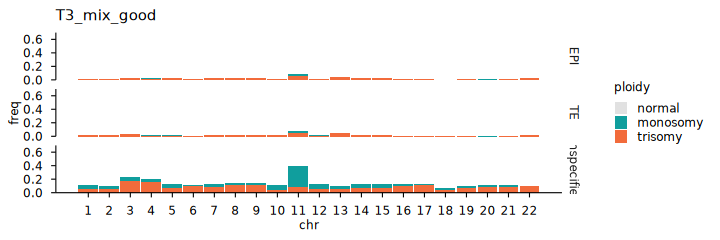

In [161]:
#plot
merged_ploidydf_sub = merged_ploidydf %>% filter(sample == "T3_mix_good") 

title = "R_freq_perchr_celltype"

w <- 6
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

order = c("normal","monosomy","trisomy")
merged_ploidydf_sub$ploidy <- factor(merged_ploidydf_sub$ploidy, levels = order)

gg_bar = ggplot(merged_ploidydf_sub, aes(x=chr, fill=ploidy)) +
  geom_bar(position='fill')+
  settheme+
  scale_y_continuous(expand = c(0, 0), limits = c(0, 0.7), breaks = seq(0, 0.7, by = 0.2))+
  scale_x_continuous(breaks = seq(1,22, by = 1))+
  labs(title = "T3_mix_good", y= "freq")+
  scale_fill_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))+
  facet_grid(celltype_coarse ~.)

ggsave(plot = gg_bar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gg_bar

Warning message:
“Removed 66 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 66 rows containing missing values or values outside the scale range
(`geom_bar()`).”


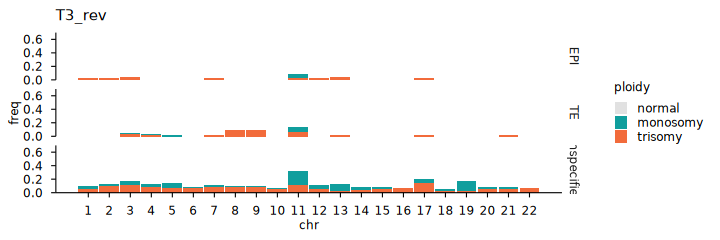

In [162]:
#plot
merged_ploidydf_sub = merged_ploidydf %>% filter(sample == "T3_rev") 

title = "R2_freq_perchr_celltype_rev"

w <- 6
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

order = c("normal","monosomy","trisomy")
merged_ploidydf_sub$ploidy <- factor(merged_ploidydf_sub$ploidy, levels = order)

gg_bar = ggplot(merged_ploidydf_sub, aes(x=chr, fill=ploidy)) +
  geom_bar(position='fill')+
  settheme+
  scale_y_continuous(expand = c(0, 0), limits = c(0, 0.7), breaks = seq(0, 0.7, by = 0.2))+
  scale_x_continuous(breaks = seq(1,22, by = 1))+
  labs(title = "T3_rev", y= "freq")+
  scale_fill_manual(values=c("normal"=adjustcolor("grey77", alpha = 0.5),"monosomy"="#109E9D","trisomy"="#F26B3B"))+
  facet_grid(celltype_coarse ~.)

ggsave(plot = gg_bar, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
gg_bar

### S) % each cell type per condition

In [163]:
head(cell_karyo_df, 3)

,cell,X,karyotype,ploidy,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse,cell.ID_,num_features,feature_call,num_umis,dataset.y,filtered_feature_call
,<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,24360,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.29044464,0.15769816,S,6,-0.0409680033,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127
2,AAACCTGAGACGCTTT-1_Embryo-Imp15265942,18678,diploid,diploid,0,0,44,0,Embryo-Imp15265942,0.2405063,False,0.2636364,0.6744908,1,0.7921813,6729,32549,803,2.467050,8197,25.18357,high,0.46809529,0.07644101,S,13,0.0004088362,,TE,T2_mix,day4,Mosaic,Intermediate,6729,0.2261420,3,3,5,7,unspecified,2,unspecified_1,unspecified,AAACCTGAGACGCTTT,1,pooled_BC_57,284,Embryo-Imp15265942,pooled_BC_57
3,AAACCTGAGAGTCGGT-1_Embryo-Imp15265946,24361,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.2409639,True,0.2263610,1.0691784,1,0.9224943,5816,25038,529,2.112788,6271,25.04593,high,0.02287884,0.20074458,G2M,6,-0.0466536458,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5816,0.3535609,1,1,0,6,unspecified,2,unspecified_1,unspecified,AAACCTGAGAGTCGGT,1,pooled_BC_155,509,Embryo-Imp15265946,pooled_BC_155


In [164]:
#summarise
cell_karyo_df_summary <- cell_karyo_df%>%
  filter(!is.na(ploidy) & 
         !is.na(filtered_feature_call) & 
         filtered_feature_call != "fail"  
  )%>%
  mutate(celltype_coarse = factor(celltype_coarse , levels = c("EPI", "TE", "unspecified"))) %>%
  group_by(filtered_feature_call, sample, celltype_coarse,.drop = FALSE) %>%
  summarise(count = n()) %>%
  mutate(sum = sum(count)) %>%
  #filter(sum(count) >= 10) %>%
  mutate(prop = count / sum(count)) %>%
  ungroup()

`summarise()` has grouped output by 'filtered_feature_call', 'sample'. You can
override using the `.groups` argument.


In [165]:
head(cell_karyo_df_summary)

filtered_feature_call,sample,celltype_coarse,count,sum,prop
<chr>,<chr>,<fct>,<int>,<int>,<dbl>
pooled_BC_1,T2_control,EPI,0,8,0
pooled_BC_1,T2_control,TE,0,8,0
pooled_BC_1,T2_control,unspecified,8,8,1
pooled_BC_1,T2_mix,EPI,0,18,0
pooled_BC_1,T2_mix,TE,0,18,0
pooled_BC_1,T2_mix,unspecified,18,18,1


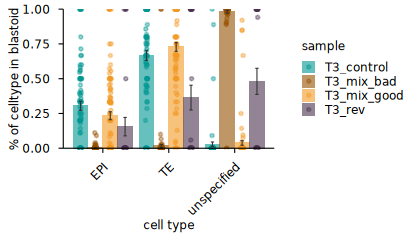

In [166]:
cell_karyo_df_summary_sub <- 
  cell_karyo_df_summary %>% 
  filter(sample %in% c("T3_rev", "T3_mix_good", "T3_mix_bad", "T3_control"))

title <- "per_celltype_condition"

w <- 3.5
h <- 2
options(repr.plot.width = w, repr.plot.height = h)

# define a common dodge for bars + errorbars
pos_dodge <- position_dodge(width = 0.9)

pos_dodge <- position_dodge(width = 0.9)

ggbar <- ggplot(
  cell_karyo_df_summary_sub,
  aes(x = celltype_coarse, y = prop, fill = sample)
) +
  geom_bar(stat = "summary", fun = "mean", position = pos_dodge, alpha = 0.6) +
  geom_point(
    aes(color = sample),
    size = 0.5, alpha = 0.4,
    position = position_jitterdodge(jitter.width = 0.1, dodge.width = 0.9)
  ) +
  stat_summary(
    fun.data  = "mean_se",
    geom      = "errorbar",
    width     = 0.2,
    color     = "grey20",
    position  = pos_dodge
  ) +
  labs(x = "cell type", y = "% of celltype in blastoid") +
  settheme +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
    # , legend.position = "none"
  ) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1)) +
  scale_fill_manual(values = color_sample) +
  scale_color_manual(values = color_sample)


ggsave(
  plot     = ggbar,
  filename = sprintf("%s/S_%s.pdf", outdir, title),
  width    = w,
  height   = h
)

ggbar


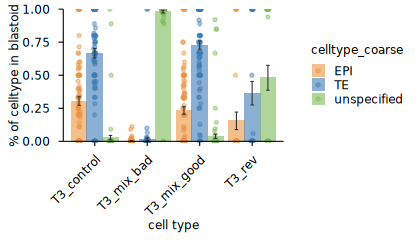

In [167]:
cell_karyo_df_summary_sub <- 
  cell_karyo_df_summary %>% 
  filter(sample %in% c("T3_rev", "T3_mix_good", "T3_mix_bad", "T3_control"))

title <- "per_celltype_condition_2"

w <- 3.5
h <- 2
options(repr.plot.width = w, repr.plot.height = h)

# define a common dodge for bars + errorbars
pos_dodge <- position_dodge(width = 0.9)

pos_dodge <- position_dodge(width = 0.9)

ggbar <- ggplot(
  cell_karyo_df_summary_sub,
  aes(x = sample, y = prop, fill = celltype_coarse)
) +
  geom_bar(stat = "summary", fun = "mean", position = pos_dodge, alpha = 0.6) +
  geom_point(
    aes(color = celltype_coarse),
    size = 0.5, alpha = 0.4,
    position = position_jitterdodge(jitter.width = 0.1, dodge.width = 0.9)
  ) +
  stat_summary(
    fun.data  = "mean_se",
    geom      = "errorbar",
    width     = 0.2,
    color     = "grey20",
    position  = pos_dodge
  ) +
  labs(x = "cell type", y = "% of celltype in blastoid") +
  settheme +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
    # , legend.position = "none"
  ) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1)) +
  scale_fill_manual(values = color_celltype) +
  scale_color_manual(values = color_celltype)


ggsave(
  plot     = ggbar,
  filename = sprintf("%s/S_%s.pdf", outdir, title),
  width    = w,
  height   = h
)

ggbar

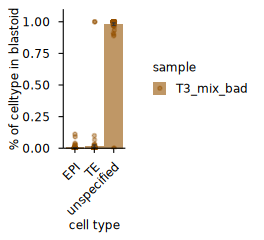

In [168]:
cell_karyo_df_summary_sub <- 
  cell_karyo_df_summary %>% 
  filter(sample %in% c("T3_mix_bad"))

title <- "S_per_celltype_condition_T3mixbad"

w <- 2.2
h <- 2
options(repr.plot.width = w, repr.plot.height = h)

# define a common dodge for bars + errorbars
pos_dodge <- position_dodge(width = 0.9)

pos_dodge <- position_dodge(width = 0.9)

ggbar <- ggplot(
  cell_karyo_df_summary_sub,
  aes(x = celltype_coarse, y = prop, fill = sample)
) +
  geom_bar(stat = "summary", fun = "mean", position = pos_dodge, alpha = 0.6) +
  geom_point(
    aes(color = sample),
    size = 0.5, alpha = 0.4,
    position = position_jitterdodge(jitter.width = 0.1, dodge.width = 0.9)
  ) +
  stat_summary(
    fun.data  = "mean_se",
    geom      = "errorbar",
    width     = 0.2,
    color     = "grey20",
    position  = pos_dodge
  ) +
  labs(x = "cell type", y = "% of celltype in blastoid") +
  settheme +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
    # , legend.position = "none"
  ) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1.1)) +
  scale_fill_manual(values = color_sample) +
  scale_color_manual(values = color_sample)


ggsave(
  plot     = ggbar,
  filename = sprintf("%s/%s.pdf", outdir, title),
  width    = w,
  height   = h
)

ggbar

### T) % celltype against %ploidy 

In [169]:
# 0) define what counts as aneuploid
df2 <- cell_karyo_df%>%
  mutate(
    is_aneuploid = ploidy != "diploid"
  )%>%
  filter(!is.na(ploidy) & 
         !is.na(filtered_feature_call) & 
         filtered_feature_call != "fail"  
  )

# 1) per-blastoid summary: overall % aneuploid in that blastoid (y-axis)
blastoid_summary <- df2 %>%
  group_by(filtered_feature_call, sample) %>%   # keep sample if you want it for colouring
  summarise(
    n_cells_blastoid  = n(),
    n_aneuploid_blastoid = sum(is_aneuploid),
    per_aneuploid_blastoid = n_aneuploid_blastoid / n_cells_blastoid,
    .groups = "drop"
  )

# 2) per-blastoid × celltype: fraction of blastoid that is this cell type (x-axis)
blastoid_celltype <- df2 %>%
  group_by(filtered_feature_call, sample, celltype_coarse) %>%
  summarise(
    n_cells_celltype = n(),
    .groups = "drop"
  ) %>%
  left_join(blastoid_summary, by = c("filtered_feature_call", "sample")) %>%
  mutate(
    per_celltype = n_cells_celltype / n_cells_blastoid
  )

# filter small celltype counts per blastoid
#blastoid_celltype <- blastoid_celltype %>% filter(n_cells_celltype >= 5)   # tweak threshold


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


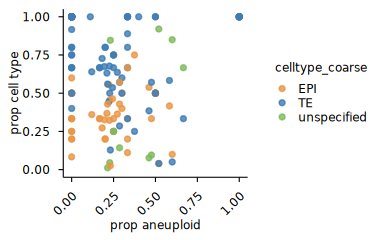

In [170]:
## 3) Plot: x = % of blastoid that is this cell type, y = % aneuploid in blastoid
w <- 3.2
h <- 2
options(repr.plot.width = w, repr.plot.height = h)

title = "T1_peraneu_per_celltype"

blastoid_celltype_sub = blastoid_celltype %>% 
  filter(sample %in% c( "T3_mix_good"))


gg_scatter <- ggplot(
  blastoid_celltype_sub ,
  aes(
    x = per_aneuploid_blastoid,
    y = per_celltype,
    color = celltype_coarse    # or sample, depending on what you want to highlight
  )
) +
  geom_point(size = 1, alpha = 0.8) +
  # optional smoothing / trend per cell type
  # geom_smooth(method = "lm", se = FALSE, size = 0.3) +
  scale_x_continuous(
    "prop aneuploid",
    limits = c(0, 1)
  ) +
  scale_y_continuous(
    "prop cell type",
    limits = c(0, 1)
  ) +
  settheme+
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )+
  scale_fill_manual(values = color_celltype) +
  scale_color_manual(values = color_celltype)

ggsave(
  plot     = gg_scatter,
  filename = sprintf("%s/%s.pdf", outdir, title),
  width    = w,
  height   = h
)

gg_scatter

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '≤50%' in 'mbcsToSbcs': <= substituted for ≤ (U+2264)”


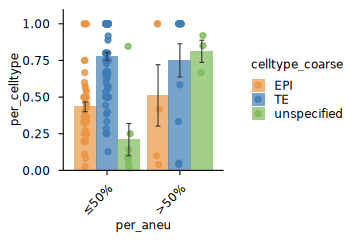

In [171]:
# 1) Bin x-values (per_aneuploid_blastoid) into two groups
blastoid_celltype_binned <- blastoid_celltype_sub  %>%
  mutate(
    per_aneu = cut(
      per_aneuploid_blastoid,
      breaks = c(-Inf, 0.5, Inf),                 # change 0.5 if you prefer another split
      labels = c("≤50%", ">50%")
    )
  )

# 2) Bar chart: mean prop cell type per bin, per celltype
w <- 3
h <- 2
options(repr.plot.width = w, repr.plot.height = h)


title = "T2_bar_peraneu_per_celltype"

gg_bar <- ggplot(
  blastoid_celltype_binned,
  aes(
    x    = per_aneu,
    y    = per_celltype,
    fill = celltype_coarse
  )
) +
  geom_bar(
    stat     = "summary",
    fun      = "mean",
    position = position_dodge(width = 0.9),
    alpha    = 0.7
  ) +
  # dots: one per blastoid, jittered & dodged
  geom_point(
    aes(color = celltype_coarse),
    position = position_jitterdodge(
      jitter.width = 0.1,
      dodge.width  = 0.9
    ),
    size  = 1,
    alpha = 0.8
  ) +
  # optional error bars: SE of the mean per bin & celltype
  stat_summary(
    fun.data = "mean_se",
    geom     = "errorbar",
    position = position_dodge(width = 0.9),
    width    = 0.2,
    color    = "grey20"
  ) +settheme+
    scale_y_continuous(
    expand = c(0, 0),limits = c(0, 1.1))+
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )+
  scale_fill_manual(values = color_celltype) +
  scale_color_manual(values = color_celltype)


ggsave(
  plot     = gg_bar,
  filename = sprintf("%s/%s.pdf", outdir, title),
  width    = w,
  height   = h
)

gg_bar


In [172]:
blastoid_celltype_binned %>%
  group_by(celltype_coarse) %>%
  pairwise_wilcox_test(
    per_celltype ~ per_aneu,
    p.adjust.method = "none"
  ) 

,celltype_coarse,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,EPI,per_celltype,≤50%,>50%,49,5,122.0,1.000,1.000,ns
2,TE,per_celltype,≤50%,>50%,84,12,462.5,0.630,0.630,ns
3,unspecified,per_celltype,≤50%,>50%,7,3,1.0,0.033,0.033,*


In [173]:
# 0) define aneuploid vs normal
df2 <- cell_karyo_df%>%
  filter(!is.na(ploidy) & 
         !is.na(filtered_feature_call) & 
         filtered_feature_call != "fail"  
  )%>%
  mutate(
    # adjust "normal" label if needed
    is_aneuploid = ploidy != "diploid"
    # e.g. is_aneuploid = ploidy %in% c("monosomy", "trisomy", "loh")
  )

# 1) per-blastoid summary: overall % aneuploid in that blastoid (x-axis)
blastoid_summary <- df2 %>%
  group_by(filtered_feature_call, sample) %>%
  summarise(
    n_cells_blastoid      = n(),
    n_aneuploid_blastoid  = sum(is_aneuploid),
    per_aneuploid_blastoid = n_aneuploid_blastoid / n_cells_blastoid,
    .groups = "drop"
  )

# 2) per-blastoid × celltype: % aneuploid within that celltype (y-axis)
blastoid_celltype <- df2 %>%
  group_by(filtered_feature_call, sample, celltype_coarse) %>%  # rename for convenience
  summarise(
    n_cells_ct      = n(),
    n_aneuploid_ct  = sum(is_aneuploid),
    per_aneuploid_ct = n_aneuploid_ct / n_cells_ct,   # y-axis
    .groups = "drop"
  ) %>%
  left_join(blastoid_summary,
            by = c("filtered_feature_call", "sample"))

# Optional: filter out very small celltype groups per blastoid
#blastoid_celltype <- blastoid_celltype %>%filter(n_cells_ct >= 3)  # tweak threshold if you like


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


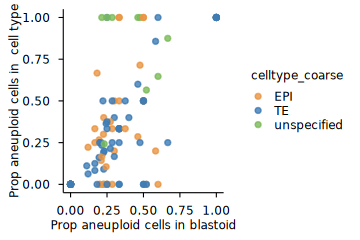

In [174]:
# 3) Plot: x = overall % aneuploid in blastoid, y = % aneuploid in that celltype in that blastoid
w <- 3
h <- 2
options(repr.plot.width = w, repr.plot.height = h)


title <- "T3_perAneuCT_vs_globalAneu"

blastoid_celltype_sub = blastoid_celltype %>% 
  filter(sample %in% c( "T3_mix_good"))

gg_scatter <- ggplot(
  blastoid_celltype_sub,
  aes(
    x = per_aneuploid_blastoid,   # overall aneuploid fraction (blastoid)
    y = per_aneuploid_ct,         # celltype-specific aneuploid fraction
    color = celltype_coarse       # or sample, depending on what you want
  )
) +
  geom_point(size = 1, alpha = 0.8) +
  # optional: trend lines per celltype
  # geom_smooth(method = "lm", se = FALSE, size = 0.3) +
  scale_x_continuous(
    "Prop aneuploid cells in blastoid",
    limits = c(0, 1)
  ) +
  scale_y_continuous(
    "Prop aneuploid cells in  cell type",
    limits = c(0, 1)
  ) +
  settheme+
  scale_fill_manual(values = color_celltype) +
  scale_color_manual(values = color_celltype)


ggsave(
  plot     = gg_scatter,
  filename = sprintf("%s/%s.pdf", outdir, title),
  width    = w,
  height   = h
)

gg_scatter

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '≤50%' in 'mbcsToSbcs': <= substituted for ≤ (U+2264)”


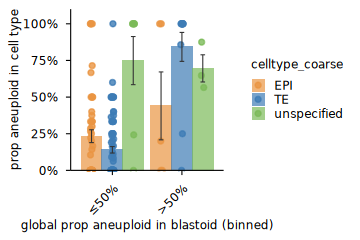

In [175]:
# 1) Bin x-values (overall aneuploidy per blastoid) into two groups
blastoid_celltype_binned <- blastoid_celltype_sub %>%
  mutate(
    per_aneu_bin = cut(
      per_aneuploid_blastoid,
      breaks = c(-Inf, 0.5, Inf),   # change 0.5 if you prefer another split
      labels = c("≤50%", ">50%")
    )
  )

w <- 3
h <- 2
options(repr.plot.width = w, repr.plot.height = h)

title <- "T4_bar_perAneuCT_vs_globalAneu_bin"

dodge_width <- 0.9
pos_dodge   <- position_dodge(width = dodge_width)

gg_bar <- ggplot(
  blastoid_celltype_binned,
  aes(
    x    = per_aneu_bin,
    y    = per_aneuploid_ct,   # <- y = % aneuploid within this celltype
    fill = celltype_coarse
  )
) +
  # bars: mean per bin × celltype
  geom_bar(
    stat     = "summary",
    fun      = "mean",
    position = pos_dodge,
    alpha    = 0.7
  ) +
  # dots: one per blastoid (per celltype), jittered & dodged
  geom_point(
    aes(color = celltype_coarse),
    position = position_jitterdodge(
      jitter.width = 0.1,
      dodge.width  = dodge_width
    ),
    size  = 1,
    alpha = 0.8
  ) +
  # error bars: SE of mean per bin × celltype
  stat_summary(
    fun.data = "mean_se",
    geom     = "errorbar",
    position = pos_dodge,
    width    = 0.2,
    color    = "grey20"
  ) +
  settheme +
  scale_y_continuous(
    "prop aneuploid in cell type",
    expand = c(0, 0),
    limits = c(0, 1.1),
    labels = percent_format(accuracy = 1)
  ) +
  scale_x_discrete("global prop aneuploid in blastoid (binned)") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  ) +
  scale_fill_manual(values = color_celltype) +
  scale_color_manual(values = color_celltype)

ggsave(
  plot     = gg_bar,
  filename = sprintf("%s/%s.pdf", outdir, title),
  width    = w,
  height   = h
)

gg_bar


In [176]:
head(blastoid_celltype_binned)

filtered_feature_call,sample,celltype_coarse,n_cells_ct,n_aneuploid_ct,per_aneuploid_ct,n_cells_blastoid,n_aneuploid_blastoid,per_aneuploid_blastoid,per_aneu_bin
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<fct>
pooled_BC_1,T3_mix_good,TE,1,0,0,1,0,0,≤50%
pooled_BC_100,T3_mix_good,EPI,1,0,0,2,0,0,≤50%
pooled_BC_100,T3_mix_good,TE,1,0,0,2,0,0,≤50%
pooled_BC_101,T3_mix_good,TE,1,0,0,1,0,0,≤50%
pooled_BC_102,T3_mix_good,TE,2,0,0,2,0,0,≤50%
pooled_BC_104,T3_mix_good,EPI,1,0,0,12,0,0,≤50%


In [177]:
blastoid_celltype_binned %>%
  group_by(celltype_coarse) %>%
  pairwise_wilcox_test(
    per_aneuploid_ct ~ per_aneu_bin,
    p.adjust.method = "none"
  ) 

,celltype_coarse,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,EPI,per_aneuploid_ct,≤50%,>50%,49,5,99.5,4.76e-01,4.76e-01,ns
2,TE,per_aneuploid_ct,≤50%,>50%,84,12,87.5,7.22e-07,7.22e-07,****
3,unspecified,per_aneuploid_ct,≤50%,>50%,7,3,15.0,3.31e-01,3.31e-01,ns


### U) Cell type, ploidy , per structure

In [178]:
library(dplyr)
library(ggplot2)

plot_celltype_ratio_per_structure <- function(
  cell_karyo_df,
  sample_name        = "T3_mix_bad",
  plot_var       = celltype_coarse,    # bare column name
  priority_celltypes = c("EPI", "TE"),     # used for ordering structures
  title              = NULL,
   w = 20,
   h = 2.5
) {
  if (is.null(title)) {
    title <- sprintf("celltype_ratio_%s", sample_name)
  }
  


  # Compute ratios
  df_ratio_celltype <- cell_karyo_df %>%
    filter(!is.na({{ plot_var }})) %>%
    filter(sample == sample_name) %>%
    filter(filtered_feature_call != "fail") %>%
    group_by(filtered_feature_call, {{ plot_var }}) %>%
    summarise(count = n(), .groups = "drop") %>%
    group_by(filtered_feature_call) %>%
    mutate(sum = sum(count)) %>%
    filter(sum >= 5) %>%
    mutate(ratio = count / sum) %>%
    ungroup()

  # Optional: order structures so those enriched in priority celltypes come first
  if (length(priority_celltypes) > 0) {
    df_ratio_celltype <- df_ratio_celltype %>%
      mutate(
        .priority = {{ plot_var }} %in% priority_celltypes
      ) %>%
      arrange(desc(.priority), desc(ratio))
  }

  # Order on x-axis
  order <- unique(df_ratio_celltype$filtered_feature_call)
  sample_order <- factor(order, levels = order)

  df_ratio_celltype <- df_ratio_celltype %>%
    mutate(filtered_feature_call = factor(filtered_feature_call, levels = order))

  # Plot
  options(repr.plot.width = w, repr.plot.height = h)

  bar_ratio <- ggplot(
    df_ratio_celltype,
    aes(x = filtered_feature_call, y = ratio, fill = {{ plot_var }})
  ) +
    geom_bar(stat = "identity", position = "stack") +
    labs(
      x    = "Structure",
      y    = "Ratio",
      title = sample_name, 
      fill = deparse(substitute(plot_var))
    ) +
    settheme +
    scale_fill_manual(values = color_celltype) +
    scale_color_manual(values = color_celltype) +
    theme(
      axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)
    ) +
    scale_y_continuous(expand = c(0, 0), limits = c(0, 1)) +
    scale_x_discrete(limits = sample_order)

  ggsave(
    plot     = bar_ratio,
    filename = sprintf("%s/%s.pdf", outdir, title),
    width    = w,
    height   = h
  )

  bar_ratio
}


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


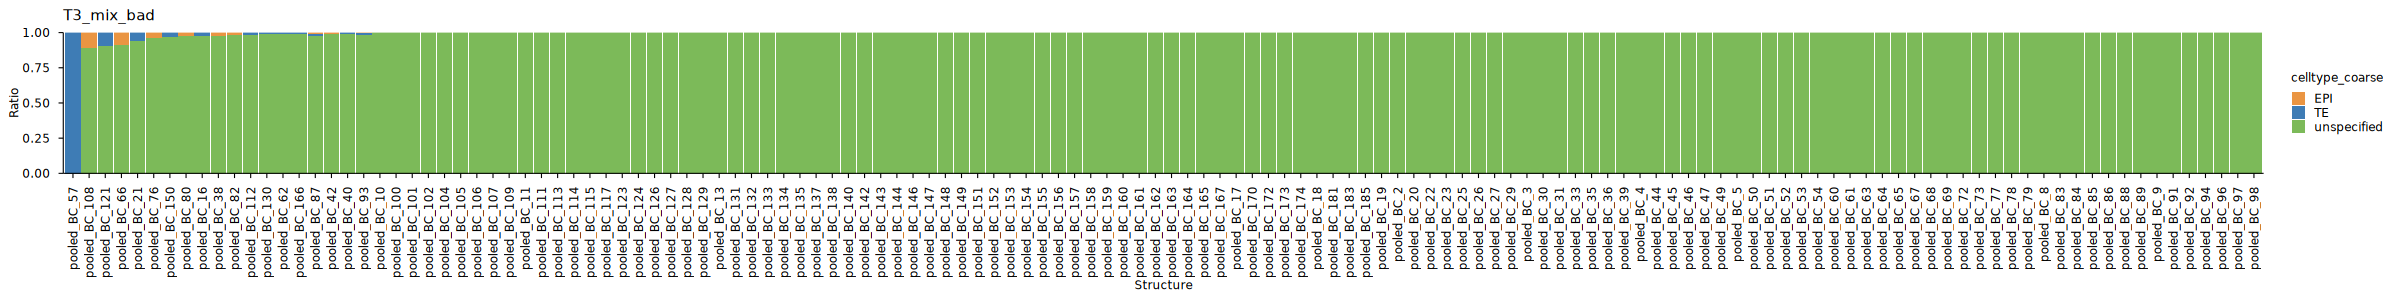

In [179]:
plot_celltype_ratio_per_structure(
  cell_karyo_df,
  sample_name  = "T3_mix_bad",
  plot_var = celltype_coarse,
  title        = "U1_celltype_ratio_structure"
)

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


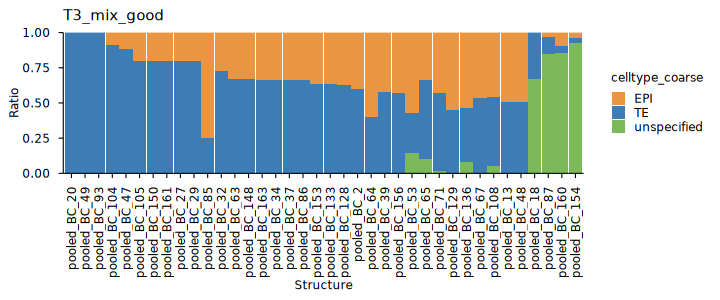

In [180]:
plot_celltype_ratio_per_structure(
  cell_karyo_df,
  sample_name  = "T3_mix_good",
  plot_var = celltype_coarse,
  title        = "U2_celltype_ratio_structure",
   w = 6
)

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


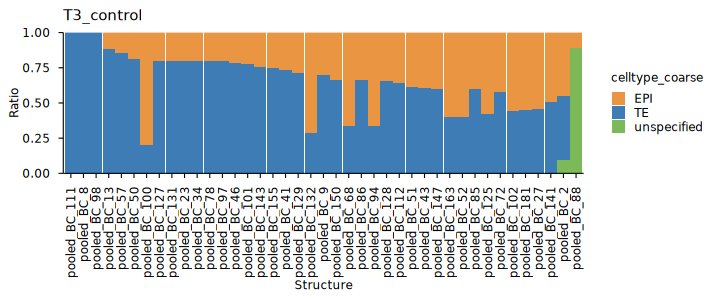

In [181]:
plot_celltype_ratio_per_structure(
  cell_karyo_df,
  sample_name  = "T3_control",
  plot_var = celltype_coarse,
  title        = "U3_celltype_ratio_structure",
    w = 6
)

In [182]:
plot_ploidy_ratio_per_structure <- function(
  cell_karyo_df,
  sample_name        = "T3_mix_bad",
  plot_var           = ploidy,          # bare column name, usually 'ploidy'
  ordering_var       = celltype_coarse, # bare column name used for ordering (cell type)
  priority_celltypes = c("EPI", "TE"),  # used for ordering structures
  title              = NULL,
  w                  = 20,
  h                  = 2.5
) {
  if (is.null(title)) {
    title <- sprintf("ploidy_ratio_%s", sample_name)
  }

  df_order <- cell_karyo_df %>%
    filter(!is.na({{ ordering_var }})) %>%
    filter(sample == sample_name) %>%
    filter(filtered_feature_call != "fail") %>%
    group_by(filtered_feature_call, {{ ordering_var }}) %>%
    summarise(count = n(), .groups = "drop") %>%
    group_by(filtered_feature_call) %>%
    mutate(sum = sum(count)) %>%
    filter(sum >= 5) %>%
    mutate(ratio = count / sum) %>%
    ungroup()

  if (length(priority_celltypes) > 0) {
    df_order <- df_order %>%
      mutate(
        .priority = {{ ordering_var }} %in% priority_celltypes
      ) %>%
      arrange(desc(.priority), desc(ratio))
  }

  order_struct <- unique(df_order$filtered_feature_call)
  sample_order <- factor(order_struct, levels = order_struct)

  df_ploidy <- cell_karyo_df %>%
    filter(!is.na({{ plot_var }})) %>%
    filter(sample == sample_name) %>%
    filter(filtered_feature_call != "fail") %>%
    group_by(filtered_feature_call, {{ plot_var }}) %>%
    summarise(count = n(), .groups = "drop") %>%
    group_by(filtered_feature_call) %>%
    mutate(
      sum   = sum(count),
      ratio = count / sum
    ) %>%
    ungroup() %>%
    filter(sum >= 5) %>%
    mutate(
      filtered_feature_call = factor(filtered_feature_call,
                                     levels = order_struct)
    )

  if (as.character(substitute(plot_var)) == "ploidy") {
    ploidy_order <- c("diploid", "complex", "monosomy", "trisomy")
    df_ploidy <- df_ploidy %>%
      mutate(ploidy = factor(ploidy, levels = ploidy_order))
  }

  options(repr.plot.width = w, repr.plot.height = h)

  bar_ratio <- ggplot(
    df_ploidy,
    aes(x = filtered_feature_call, y = ratio, fill = {{ plot_var }})
  ) +
    geom_bar(stat = "identity", position = "stack") +
    labs(
      x     = "Structure",
      y     = "Ratio",
      title =  sample_name,
      fill  = deparse(substitute(plot_var))
    ) +
    settheme +
    scale_fill_manual(values = color_ploidy_2) +
    scale_color_manual(values = color_ploidy_2) +
    theme(
      axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)
    ) +
    scale_y_continuous(expand = c(0, 0), limits = c(0, 1)) +
    scale_x_discrete(limits = sample_order)

  ggsave(
    plot     = bar_ratio,
    filename = sprintf("%s/%s.pdf", outdir, title),
    width    = w,
    height   = h
  )

  bar_ratio
}


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


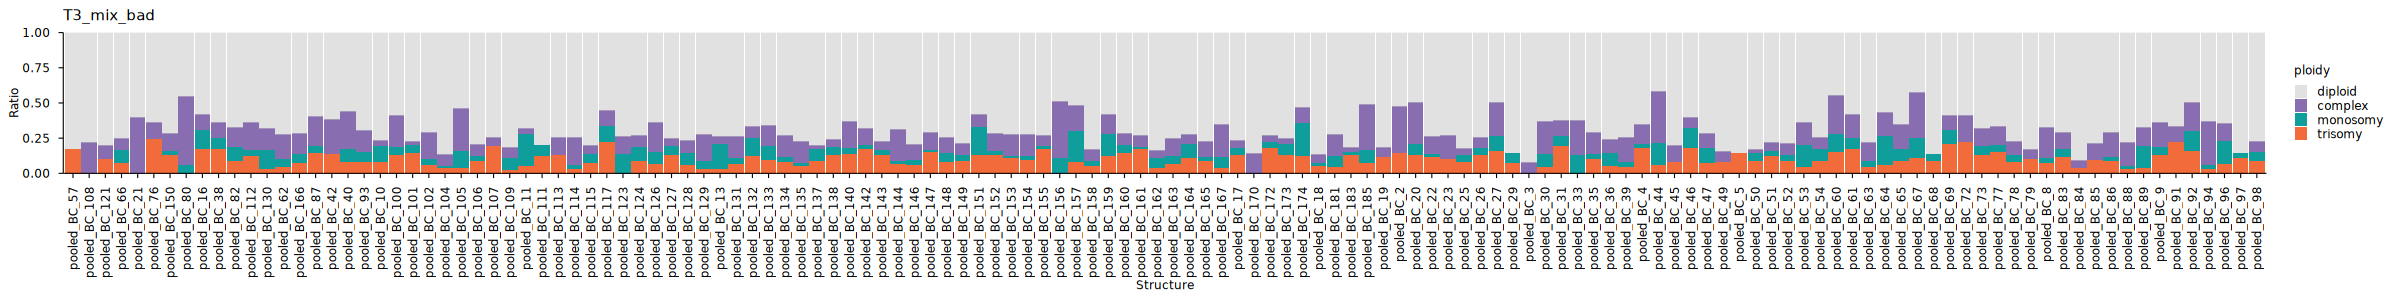

In [183]:
plot_ploidy_ratio_per_structure(
  cell_karyo_df,
  sample_name  = "T3_mix_bad",
  title        = "U4_ploidy_ratio_structure"
)

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


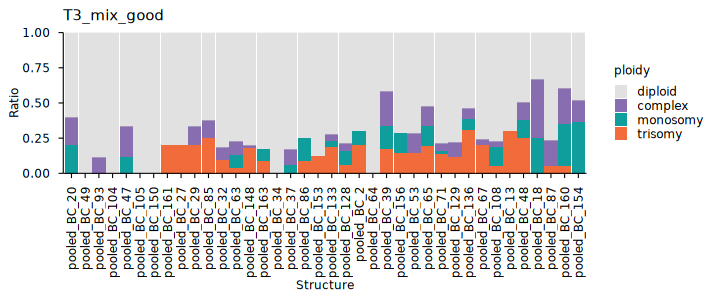

In [184]:
plot_ploidy_ratio_per_structure(
  cell_karyo_df,
  sample_name  = "T3_mix_good",
  title        = "U5_ploidy_ratio_structure",
   w = 6
)

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”


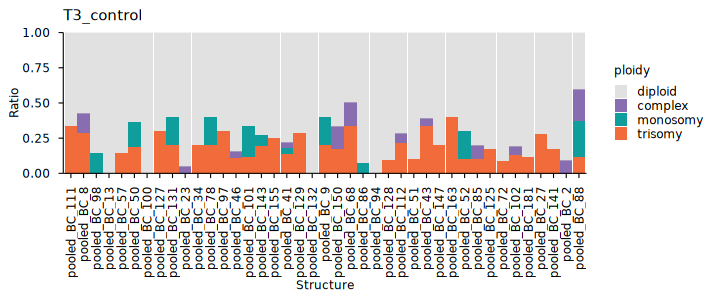

In [185]:
plot_ploidy_ratio_per_structure(
  cell_karyo_df,
  sample_name  = "T3_control",
  title        = "U6_ploidy_ratio_structure",
   w = 6
)

In [186]:
head(cell_karyo_df)

,cell,X,karyotype,ploidy,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse,cell.ID_,num_features,feature_call,num_umis,dataset.y,filtered_feature_call
,<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,24360,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.29044464,0.15769816,S,6,-0.0409680033,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127
2,AAACCTGAGACGCTTT-1_Embryo-Imp15265942,18678,diploid,diploid,0,0,44,0,Embryo-Imp15265942,0.2405063,False,0.2636364,0.6744908,1,0.7921813,6729,32549,803,2.467050,8197,25.18357,high,0.46809529,0.07644101,S,13,0.0004088362,,TE,T2_mix,day4,Mosaic,Intermediate,6729,0.2261420,3,3,5,7,unspecified,2,unspecified_1,unspecified,AAACCTGAGACGCTTT,1,pooled_BC_57,284,Embryo-Imp15265942,pooled_BC_57
3,AAACCTGAGAGTCGGT-1_Embryo-Imp15265946,24361,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.2409639,True,0.2263610,1.0691784,1,0.9224943,5816,25038,529,2.112788,6271,25.04593,high,0.02287884,0.20074458,G2M,6,-0.0466536458,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5816,0.3535609,1,1,0,6,unspecified,2,unspecified_1,unspecified,AAACCTGAGAGTCGGT,1,pooled_BC_155,509,Embryo-Imp15265946,pooled_BC_155
4,AAACCTGAGATCGGGT-1_Embryo-Imp15265944,36486,diploid,diploid,0,0,44,0,Embryo-Imp15265944,0.1247974,False,0.1300000,0.6744908,1,0.8897991,6079,46417,2452,5.282547,10633,22.90755,high,-0.06009019,0.30989354,G2M,4,-0.0272863224,,TE,T3_control,day6,Control,Blastoid_Gd,6079,0.3099473,6,6,6,5,TE,5,TE_2,TE,AAACCTGAGATCGGGT,2,pooled_BC_46|pooled_BC_181,1|1,Embryo-Imp15265944,fail
5,AAACCTGAGCCATCGC-1_Embryo-Imp15265944,24283,diploid,diploid,0,0,44,0,Embryo-Imp15265944,0.0951087,False,0.1086739,0.0605830,1,0.9669925,9291,61415,1447,2.356102,13429,21.86599,high,0.03734729,0.29275252,G2M,11,0.0881670165,,unknown,T3_control,day6,Control,Blastoid_Gd,9291,0.3004118,8,10,10,23,unspecified,0,unspecified_1,unspecified,AAACCTGAGCCATCGC,32,pooled_BC_14|pooled_BC_23|pooled_BC_27|pooled_BC_34|pooled_BC_41|pooled_BC_43|pooled_BC_46|pooled_BC_49|pooled_BC_51|pooled_BC_65|pooled_BC_68|pooled_BC_72|pooled_BC_76|pooled_BC_85|pooled_BC_86|pooled_BC_88|pooled_BC_94|pooled_BC_97|pooled_BC_98|pooled_BC_100|pooled_BC_102|pooled_BC_112|pooled_BC_127|pooled_BC_128|pooled_BC_129|pooled_BC_137|pooled_BC_141|pooled_BC_143|pooled_BC_152|pooled_BC_155|pooled_BC_156|pooled_BC_181,1|2|1|1|2|2|2|1|2|7|2|1|1|1|2|60|1|1|2|1|1|1|2|6|2|1|1|4|1|3|1|4,Embryo-Imp15265944,fail
6,AAACCTGAGCCCGAAA-1_Embryo-Imp15265944,36487,diploid,diploid,0,0,44,0,Embryo-Imp15265944,0.1300000,False,0.1475410,1.1794374,1,0.7862024,5856,29820,1014,3.400403,5819,19.51375,high,0.36315951,0.18351380,S,4,0.0064831209,,TE,T3_control,day6,Control,Blastoid_Gd,5856,0.3663939,6,6,6,5,TE,5,TE_1,TE,AAACCTGAGCCCGAAA,2,pooled_BC_94|pooled_BC_112,1|1,Embryo-Imp15265944,fail


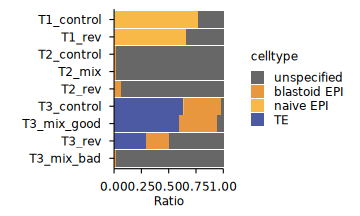

In [187]:
sample_order <- c('T1_control','T1_rev','T2_control','T2_mix','T2_rev','T3_control','T3_mix_good','T3_rev','T3_mix_bad','T3_naive_rev') 
#sample_order <- c('T1_control','T1_rev','T2_mix','T3_mix_good','T3_mix_bad') 
celltype_order <- c(  "unspecified","blastoid EPI", "naive EPI", "TE")


df_ratio <- cell_karyo_df %>%
  filter(sample %in% sample_order) %>%
  group_by(sample, integrated_celltype) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(sample) %>%
  mutate(ratio = count / sum(count))%>%
  filter(!grepl("Other",sample, ignore.case = TRUE))

title = "celltype_ratio"

w <- 3
h <- 1.8
options(repr.plot.width=w, repr.plot.height=h)


# Plot the ratio as a bar chart
bar_ratio = ggplot(df_ratio%>% subset(!sample %in% c(NA, 'T3_naive_rev'))%>%
  mutate(sample = factor(sample, levels = (sample_order)),
        integrated_celltype = factor(integrated_celltype, levels = celltype_order)),
                   aes(x = sample, y = ratio, fill = integrated_celltype)) +
  geom_bar(stat = "identity", position = "stack") +  # Stacked bars for proportion
  labs(
       x = "",
       y = "Ratio",
       fill = "celltype") +
    coord_flip()+
  settheme +
  scale_fill_manual(values=color_celltype2 )+
  #theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1))+
  scale_x_discrete(limits = rev)



ggsave(plot = bar_ratio , filename = sprintf("%s/%s.pdf",outdir, title), w = w, h =h)

bar_ratio 

#### cell type by developed vs failed 

In [188]:
tail(cell_karyo_df)

,cell,X,karyotype,ploidy,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse,cell.ID_,num_features,feature_call,num_umis,dataset.y,filtered_feature_call
,<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
38650,TTTGTCATCGTACCGG-1_Embryo-Imp15265946,11274,"2+, 3+, 6-, 7+, 8+, 10-, 11-, 12+, 13+, 14-, 15-, 16-, 17+, 20+, 21+, 22+",complex,10,6,48,16,Embryo-Imp15265946,0.1157895,False,0.1519493,-0.09090379,1,0.9443455,3557,9076,251,2.765536,1514,16.68136,low,0.59463746,0.02036474,S,5,0.09823507,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,3557,0.3386584,7,7,8,9,unspecified,6,unspecified_1,unspecified,TTTGTCATCGTACCGG,1,pooled_BC_42,35,Embryo-Imp15265946,pooled_BC_42
38651,TTTGTCATCGTGACAT-1_Embryo-Imp15265942,23259,diploid,diploid,0,0,44,0,Embryo-Imp15265942,0.3225806,False,0.2636364,0.67449076,1,0.7921813,6701,32795,789,2.405854,7594,23.15597,high,0.26059755,0.15826643,S,2,0.05980658,,TE,T2_mix,day4,Mosaic,Intermediate,6701,0.3365692,3,1,5,0,unspecified,4,unspecified_1,unspecified,TTTGTCATCGTGACAT,1,pooled_BC_106,845,Embryo-Imp15265942,pooled_BC_106
38652,TTTGTCATCTCCAGGG-1_Embryo-Imp15265940,17564,diploid,diploid,0,0,44,0,Embryo-Imp15265940,0.1992883,False,0.1596386,-0.71999857,1,0.9569546,7583,37967,686,1.806832,7835,20.63634,high,0.43582214,-0.06441349,S,13,0.04362351,,TE,T2_control,day4,Control,Intermediate,7583,0.3028878,3,3,5,7,unspecified,0,unspecified_1,unspecified,NA,NA,NA,NA,NA,NA
38653,TTTGTCATCTGAAAGA-1_Embryo-Imp15265945,38528,diploid,diploid,0,0,44,0,Embryo-Imp15265945,0.1428571,False,0.1373802,0.91209532,1,0.7845502,6649,44312,1906,4.301318,10275,23.18785,high,0.07372617,0.16395599,G2M,4,-0.02597441,,TE,T3_mix_good,day6,Mosaic,Blastoid_Gd,6649,0.4128195,6,6,6,5,TE,5,TE_1,TE,TTTGTCATCTGAAAGA,2,pooled_BC_18|pooled_BC_64,7|1,Embryo-Imp15265945,pooled_BC_18
38654,TTTGTCATCTGAGGGA-1_Embryo-Imp15265947,38655,diploid,diploid,0,0,44,0,Embryo-Imp15265947,0.1160714,False,0.1195206,0.62113749,1,0.8114719,7973,92037,2391,2.597868,19681,21.38379,high,-0.01499646,-0.02195198,G1,4,-0.10445925,,TE,T3_rev,day6,Reversine,Blastoid_Gd,7973,0.4014069,6,6,6,5,TE,5,TE_1,TE,NA,NA,NA,NA,NA,NA
38655,TTTGTCATCTTGACGA-1_Embryo-Imp15265946,11275,5-,monosomy,0,1,43,1,Embryo-Imp15265946,0.3441296,True,0.1798561,0.34416462,1,0.9224943,6495,27029,544,2.012653,6458,23.89286,high,0.10455725,0.27115657,G2M,11,0.01896367,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,6495,0.3238415,8,10,10,11,unspecified,0,unspecified_1,unspecified,TTTGTCATCTTGACGA,1,pooled_BC_83,900,Embryo-Imp15265946,pooled_BC_83


In [189]:
developed_pattern <- "(^|,\\s*)(13\\+|22\\+|14\\+|19\\+|15\\+|9\\+|11\\-)(?=,|$)"
failed_pattern    <- "(^|,\\s*)(17\\-|22\\-|6\\-|19\\-|12\\-|12\\+|21\\-)(?=,|$)"

cell_karyo_df2 <- cell_karyo_df %>%
  mutate(
    is_euploid = ploidy == "diploid",
    dev_hit = str_detect(karyotype, developed_pattern),
    fail_hit = str_detect(karyotype, failed_pattern),
    
    CLR_enrichment = case_when(
      is_euploid ~ "euploid",
      dev_hit & !fail_hit ~ "Developed_enriched",
      fail_hit & !dev_hit ~ "Failed_enriched",
      TRUE ~ "others_aneuploid"
    ),
    
    CLR_enrichment = factor(
      CLR_enrichment,
      levels = c( "euploid", "Developed_enriched", "Failed_enriched", "others_aneuploid")
    )
  ) %>%
  select(-is_euploid, -dev_hit, -fail_hit)

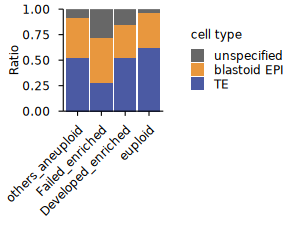

In [190]:
sample_sub = c('T3_mix_good') 
sample_order <- c( "euploid", "Developed_enriched", "Failed_enriched", "others_aneuploid")
celltype_order <- c("unspecified", "blastoid EPI", "naive EPI", "TE")

df_ratio <- cell_karyo_df2 %>%
  filter(sample %in% sample_sub) %>%
  filter(CLR_enrichment %in% sample_order) %>%
  group_by(CLR_enrichment, integrated_celltype) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(CLR_enrichment) %>%
  mutate(ratio = count / sum(count)) %>%
  ungroup()

title = "celltype_CLR_enrichment_T3_mosaic"


w <- 2.5
h <- 2
options(repr.plot.width = w, repr.plot.height = h)

bar_ratio <- ggplot(
  df_ratio %>%
    mutate(
      CLR_enrichment = factor(CLR_enrichment, levels = sample_order),
      integrated_celltype = factor(integrated_celltype, levels = celltype_order)
    ),
  aes(x = CLR_enrichment, y = ratio, fill = integrated_celltype)
) +
  geom_bar(stat = "identity", position = "stack") +
  labs(
    x = "",
    y = "Ratio",
    fill = "cell type"
  ) +
  #coord_flip() +
  settheme +
  scale_fill_manual(values = color_celltype2) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1)) +
  scale_x_discrete(limits = rev(sample_order))+theme(
      axis.text.x = element_text(angle = 45, hjust = 1))

ggsave(
  plot = bar_ratio,
  filename = sprintf("%s/%s.pdf", outdir, title),
  width = w,
  height = h
)

bar_ratio

In [191]:
head(cell_karyo_df2)

,cell,X,karyotype,ploidy,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse,cell.ID_,num_features,feature_call,num_umis,dataset.y,filtered_feature_call,CLR_enrichment
,<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<fct>
1,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,24360,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.29044464,0.15769816,S,6,-0.0409680033,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127,euploid
2,AAACCTGAGACGCTTT-1_Embryo-Imp15265942,18678,diploid,diploid,0,0,44,0,Embryo-Imp15265942,0.2405063,False,0.2636364,0.6744908,1,0.7921813,6729,32549,803,2.467050,8197,25.18357,high,0.46809529,0.07644101,S,13,0.0004088362,,TE,T2_mix,day4,Mosaic,Intermediate,6729,0.2261420,3,3,5,7,unspecified,2,unspecified_1,unspecified,AAACCTGAGACGCTTT,1,pooled_BC_57,284,Embryo-Imp15265942,pooled_BC_57,euploid
3,AAACCTGAGAGTCGGT-1_Embryo-Imp15265946,24361,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.2409639,True,0.2263610,1.0691784,1,0.9224943,5816,25038,529,2.112788,6271,25.04593,high,0.02287884,0.20074458,G2M,6,-0.0466536458,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5816,0.3535609,1,1,0,6,unspecified,2,unspecified_1,unspecified,AAACCTGAGAGTCGGT,1,pooled_BC_155,509,Embryo-Imp15265946,pooled_BC_155,euploid
4,AAACCTGAGATCGGGT-1_Embryo-Imp15265944,36486,diploid,diploid,0,0,44,0,Embryo-Imp15265944,0.1247974,False,0.1300000,0.6744908,1,0.8897991,6079,46417,2452,5.282547,10633,22.90755,high,-0.06009019,0.30989354,G2M,4,-0.0272863224,,TE,T3_control,day6,Control,Blastoid_Gd,6079,0.3099473,6,6,6,5,TE,5,TE_2,TE,AAACCTGAGATCGGGT,2,pooled_BC_46|pooled_BC_181,1|1,Embryo-Imp15265944,fail,euploid
5,AAACCTGAGCCATCGC-1_Embryo-Imp15265944,24283,diploid,diploid,0,0,44,0,Embryo-Imp15265944,0.0951087,False,0.1086739,0.0605830,1,0.9669925,9291,61415,1447,2.356102,13429,21.86599,high,0.03734729,0.29275252,G2M,11,0.0881670165,,unknown,T3_control,day6,Control,Blastoid_Gd,9291,0.3004118,8,10,10,23,unspecified,0,unspecified_1,unspecified,AAACCTGAGCCATCGC,32,pooled_BC_14|pooled_BC_23|pooled_BC_27|pooled_BC_34|pooled_BC_41|pooled_BC_43|pooled_BC_46|pooled_BC_49|pooled_BC_51|pooled_BC_65|pooled_BC_68|pooled_BC_72|pooled_BC_76|pooled_BC_85|pooled_BC_86|pooled_BC_88|pooled_BC_94|pooled_BC_97|pooled_BC_98|pooled_BC_100|pooled_BC_102|pooled_BC_112|pooled_BC_127|pooled_BC_128|pooled_BC_129|pooled_BC_137|pooled_BC_141|pooled_BC_143|pooled_BC_152|pooled_BC_155|pooled_BC_156|pooled_BC_181,1|2|1|1|2|2|2|1|2|7|2|1|1|1|2|60|1|1|2|1|1|1|2|6|2|1|1|4|1|3|1|4,Embryo-Imp15265944,fail,euploid
6,AAACCTGAGCCCGAAA-1_Embryo-Imp15265944,36487,diploid,diploid,0,0,44,0,Embryo-Imp15265944,0.1300000,False,0.1475410,1.1794374,1,0.7862024,5856,29820,1014,3.400403,5819,19.51375,high,0.36315951,0.18351380,S,4,0.0064831209,,TE,T3_control,day6,Control,Blastoid_Gd,5856,0.3663939,6,6,6,5,TE,5,TE_1,TE,AAACCTGAGCCCGAAA,2,pooled_BC_94|pooled_BC_112,1|1,Embryo-Imp15265944,fail,euploid


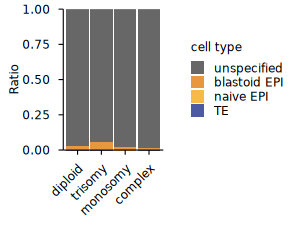

In [192]:

celltype_order <- c("unspecified", "blastoid EPI", "naive EPI", "TE")
ploidy_order <- c("diploid", "trisomy", "monosomy", "complex")

df_ratio <- cell_karyo_df2 %>%
  filter(timepoint == "day4") %>%
  group_by(ploidy, integrated_celltype) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(ploidy) %>%
  mutate(ratio = count / sum(count)) %>%
  ungroup()

title <- "celltype_ploidy_day4"

w <- 2.5
h <- 2
options(repr.plot.width = w, repr.plot.height = h)

bar_ratio <- ggplot(
  df_ratio %>%
    mutate(
      ploidy = factor(ploidy, levels = ploidy_order),
      integrated_celltype = factor(integrated_celltype, levels = celltype_order)
    ),
  aes(x = ploidy, y = ratio, fill = integrated_celltype)
) +
  geom_bar(stat = "identity", position = "stack") +
  labs(
    x = "",
    y = "Ratio",
    fill = "cell type"
  ) +
  settheme +
  scale_fill_manual(values = color_celltype2) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1)) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

ggsave(
  plot = bar_ratio,
  filename = sprintf("%s/%s.pdf", outdir, title),
  width = w,
  height = h
)

bar_ratio

In [193]:
head(cell_karyo_df2)

,cell,X,karyotype,ploidy,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse,cell.ID_,num_features,feature_call,num_umis,dataset.y,filtered_feature_call,CLR_enrichment
,<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<fct>
1,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,24360,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.29044464,0.15769816,S,6,-0.0409680033,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127,euploid
2,AAACCTGAGACGCTTT-1_Embryo-Imp15265942,18678,diploid,diploid,0,0,44,0,Embryo-Imp15265942,0.2405063,False,0.2636364,0.6744908,1,0.7921813,6729,32549,803,2.467050,8197,25.18357,high,0.46809529,0.07644101,S,13,0.0004088362,,TE,T2_mix,day4,Mosaic,Intermediate,6729,0.2261420,3,3,5,7,unspecified,2,unspecified_1,unspecified,AAACCTGAGACGCTTT,1,pooled_BC_57,284,Embryo-Imp15265942,pooled_BC_57,euploid
3,AAACCTGAGAGTCGGT-1_Embryo-Imp15265946,24361,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.2409639,True,0.2263610,1.0691784,1,0.9224943,5816,25038,529,2.112788,6271,25.04593,high,0.02287884,0.20074458,G2M,6,-0.0466536458,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5816,0.3535609,1,1,0,6,unspecified,2,unspecified_1,unspecified,AAACCTGAGAGTCGGT,1,pooled_BC_155,509,Embryo-Imp15265946,pooled_BC_155,euploid
4,AAACCTGAGATCGGGT-1_Embryo-Imp15265944,36486,diploid,diploid,0,0,44,0,Embryo-Imp15265944,0.1247974,False,0.1300000,0.6744908,1,0.8897991,6079,46417,2452,5.282547,10633,22.90755,high,-0.06009019,0.30989354,G2M,4,-0.0272863224,,TE,T3_control,day6,Control,Blastoid_Gd,6079,0.3099473,6,6,6,5,TE,5,TE_2,TE,AAACCTGAGATCGGGT,2,pooled_BC_46|pooled_BC_181,1|1,Embryo-Imp15265944,fail,euploid
5,AAACCTGAGCCATCGC-1_Embryo-Imp15265944,24283,diploid,diploid,0,0,44,0,Embryo-Imp15265944,0.0951087,False,0.1086739,0.0605830,1,0.9669925,9291,61415,1447,2.356102,13429,21.86599,high,0.03734729,0.29275252,G2M,11,0.0881670165,,unknown,T3_control,day6,Control,Blastoid_Gd,9291,0.3004118,8,10,10,23,unspecified,0,unspecified_1,unspecified,AAACCTGAGCCATCGC,32,pooled_BC_14|pooled_BC_23|pooled_BC_27|pooled_BC_34|pooled_BC_41|pooled_BC_43|pooled_BC_46|pooled_BC_49|pooled_BC_51|pooled_BC_65|pooled_BC_68|pooled_BC_72|pooled_BC_76|pooled_BC_85|pooled_BC_86|pooled_BC_88|pooled_BC_94|pooled_BC_97|pooled_BC_98|pooled_BC_100|pooled_BC_102|pooled_BC_112|pooled_BC_127|pooled_BC_128|pooled_BC_129|pooled_BC_137|pooled_BC_141|pooled_BC_143|pooled_BC_152|pooled_BC_155|pooled_BC_156|pooled_BC_181,1|2|1|1|2|2|2|1|2|7|2|1|1|1|2|60|1|1|2|1|1|1|2|6|2|1|1|4|1|3|1|4,Embryo-Imp15265944,fail,euploid
6,AAACCTGAGCCCGAAA-1_Embryo-Imp15265944,36487,diploid,diploid,0,0,44,0,Embryo-Imp15265944,0.1300000,False,0.1475410,1.1794374,1,0.7862024,5856,29820,1014,3.400403,5819,19.51375,high,0.36315951,0.18351380,S,4,0.0064831209,,TE,T3_control,day6,Control,Blastoid_Gd,5856,0.3663939,6,6,6,5,TE,5,TE_1,TE,AAACCTGAGCCCGAAA,2,pooled_BC_94|pooled_BC_112,1|1,Embryo-Imp15265944,fail,euploid


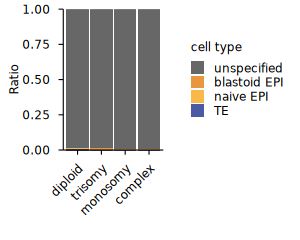

In [194]:
celltype_order <- c("unspecified", "blastoid EPI", "naive EPI", "TE")
ploidy_order <- c("diploid", "trisomy", "monosomy", "complex")

df_ratio <- cell_karyo_df2 %>%
  filter(sample == "T3_mix_bad") %>%
  group_by(ploidy, integrated_celltype) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(ploidy) %>%
  mutate(ratio = count / sum(count)) %>%
  ungroup()

title <- "celltype_ploidy_failed_blastoid"

w <- 2.5
h <- 2
options(repr.plot.width = w, repr.plot.height = h)

bar_ratio <- ggplot(
  df_ratio %>%
    mutate(
      ploidy = factor(ploidy, levels = ploidy_order),
      integrated_celltype = factor(integrated_celltype, levels = celltype_order)
    ),
  aes(x = ploidy, y = ratio, fill = integrated_celltype)
) +
  geom_bar(stat = "identity", position = "stack") +
  labs(
    x = "",
    y = "Ratio",
    fill = "cell type"
  ) +
  settheme +
  scale_fill_manual(values = color_celltype2) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1)) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

ggsave(
  plot = bar_ratio,
  filename = sprintf("%s/%s.pdf", outdir, title),
  width = w,
  height = h
)

bar_ratio

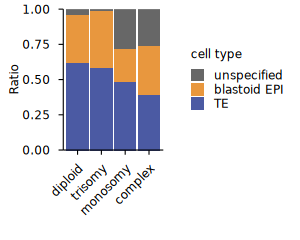

In [195]:
celltype_order <- c("unspecified", "blastoid EPI", "naive EPI", "TE")
ploidy_order <- c("diploid", "trisomy", "monosomy", "complex")

df_ratio <- cell_karyo_df2 %>%
  filter(sample == "T3_mix_good") %>%
  group_by(ploidy, integrated_celltype) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(ploidy) %>%
  mutate(ratio = count / sum(count)) %>%
  ungroup()

title <- "celltype_ploidy_developed_blastoid"

w <- 2.5
h <- 2
options(repr.plot.width = w, repr.plot.height = h)

bar_ratio <- ggplot(
  df_ratio %>%
    mutate(
      ploidy = factor(ploidy, levels = ploidy_order),
      integrated_celltype = factor(integrated_celltype, levels = celltype_order)
    ),
  aes(x = ploidy, y = ratio, fill = integrated_celltype)
) +
  geom_bar(stat = "identity", position = "stack") +
  labs(
    x = "",
    y = "Ratio",
    fill = "cell type"
  ) +
  settheme +
  scale_fill_manual(values = color_celltype2) +
  scale_y_continuous(expand = c(0, 0), limits = c(0, 1)) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

ggsave(
  plot = bar_ratio,
  filename = sprintf("%s/%s.pdf", outdir, title),
  width = w,
  height = h
)

bar_ratio

### O2) Plots of monosomies and trisomies

In [194]:
unique(cell_chr_karyo_df$ploidy_chr)

[1] normal   trisomy  monosomy
Levels: normal monosomy trisomy

In [195]:
unique(cell_chr_karyo_df$ploidy_cell)

[1] "diploid"  "trisomy"  "complex"  "monosomy"

In [196]:
cell_chr_karyo_df <- cell_chr_karyo_df %>%
  rename(sample = sample_chr)

In [197]:
cell_chr_karyo_counts_int <- cell_chr_karyo_df %>%
  group_by(sample, ploidy_cell, chr, ploidy_chr) %>%
  summarise(count = n(), .groups = "drop")

cell_chr_karyo_counts = cell_chr_karyo_counts_int%>%
  group_by(sample, chr) %>%
  mutate(total_counts = sum(count)) %>%
  ungroup()

In [198]:
head(cell_chr_karyo_counts)

sample,ploidy_cell,chr,ploidy_chr,count,total_counts
<chr>,<chr>,<int>,<fct>,<int>,<int>
T1_control,complex,1,normal,169,4052
T1_control,complex,1,monosomy,9,4052
T1_control,complex,1,trisomy,13,4052
T1_control,complex,2,normal,151,4052
T1_control,complex,2,monosomy,16,4052
T1_control,complex,2,trisomy,24,4052


In [199]:
df_prop <- cell_chr_karyo_counts%>%
  mutate(
    prop = count / total_counts
  ) %>%
  ungroup()%>%
  select(chr, sample,ploidy_cell, ploidy_chr, prop)%>%
  pivot_wider(names_from = ploidy_cell, values_from = prop)

df_prop$chr <- as.factor(df_prop$chr)
 

head(df_prop)

chr,sample,ploidy_chr,complex,diploid,monosomy,trisomy
<fct>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
1,T1_control,normal,0.041707799,0.8065153,0.0399802567,0.104392892
1,T1_control,monosomy,0.002221125,NA,0.0007403751,NA
1,T1_control,trisomy,0.003208292,NA,NA,0.001233959
2,T1_control,normal,0.037265548,0.8065153,0.0387462981,0.104392892
2,T1_control,monosomy,0.003948667,NA,0.0019743337,NA
2,T1_control,trisomy,0.005923001,NA,NA,0.001233959


In [200]:
unique(df_prop$sample)

[1] "T1_control"   "T1_rev"       "T2_control"   "T2_mix"       "T2_rev"      
 [6] "T3_control"   "T3_mix_bad"   "T3_mix_good"  "T3_naive_rev" "T3_rev"

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_text()`).”


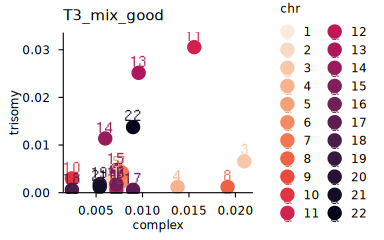

In [201]:
#plot
sample_name =  "T3_mix_good"
df_prop_sub = df_prop %>% subset(sample == sample_name)%>% subset(ploidy_chr == "trisomy")

title = "O2_scatter_T3_mix_good_tri"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = complex, y = trisomy, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  labs( title = sample_name) +
  settheme+
  scale_color_viridis_d(option = "rocket", direction = -1)+
    scale_y_continuous(limits = c(0, NA), 
    expand = expansion(mult = c(0, 0.1)))+
  #coord_fixed(ratio = 1) +
#geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_text()`).”


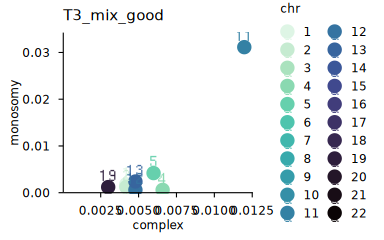

In [202]:
#plot
sample_name =  "T3_mix_good"
df_prop_sub = df_prop %>% subset(sample == sample_name)%>% subset(ploidy_chr == "monosomy")

title = "O2_scatter_T3_mix_good_mono"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = complex, y = monosomy, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  labs(title = sample_name) +
  settheme+
  scale_color_viridis_d(option = "mako", direction = -1)+
   scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0, 0.1)))+
  #coord_fixed(ratio = 1) +
#geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

In [203]:
df_prop <- cell_chr_karyo_counts%>%
  mutate(
    prop = count / total_counts
  )  %>%
  ungroup()%>%
  select(chr, sample,ploidy_cell, ploidy_chr, prop)%>%
  pivot_wider(names_from = sample, values_from = prop)%>% subset(ploidy_cell != "complex")


df_prop$chr <- as.factor(df_prop$chr)

In [204]:

df_prop_sub = df_prop %>% subset(ploidy_chr == "trisomy")

df_prop_sub

chr,ploidy_cell,ploidy_chr,T1_control,T1_rev,T2_control,T2_mix,T2_rev,T3_control,T3_mix_bad,T3_mix_good,T3_naive_rev,T3_rev
<fct>,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,trisomy,trisomy,0.0012339585,0.0043057051,0.0004607587,0.0010777521,0.0025849335,0.0016985138,0.0008688097,0.0017964072,0.0003932363,NA
2,trisomy,trisomy,0.0012339585,NA,0.0001535862,0.0001539646,NA,0.0008492569,0.0002172024,0.0023952096,NA,NA
3,trisomy,trisomy,0.0091312932,0.0035880875,0.0004607587,0.0007698229,0.0025849335,0.0140127389,0.0013032146,0.0065868263,0.0015729453,0.009202454
4,trisomy,trisomy,0.0009871668,NA,NA,0.0001539646,0.0003692762,0.0016985138,0.0002172024,0.0011976048,0.0003932363,NA
5,trisomy,trisomy,0.0081441264,0.0222461428,0.0019966211,0.0030792918,0.0033234860,0.0004246285,0.0149869679,0.0041916168,0.0114038537,0.006134969
6,trisomy,trisomy,0.0029615005,0.0003588088,0.0003071725,0.0003079292,NA,0.0050955414,NA,0.0023952096,0.0015729453,NA
7,trisomy,trisomy,0.0009871668,0.0107642626,0.0026109661,0.0061585835,0.0048005908,0.0012738854,0.0032580365,0.0041916168,0.0007864727,0.009202454
8,trisomy,trisomy,0.0007403751,0.0007176175,NA,0.0003079292,0.0003692762,0.0012738854,0.0009774109,0.0011976048,0.0015729453,NA
9,trisomy,trisomy,0.0017275420,0.0017940438,NA,NA,0.0003692762,0.0012738854,NA,NA,NA,NA


Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_text()`).”


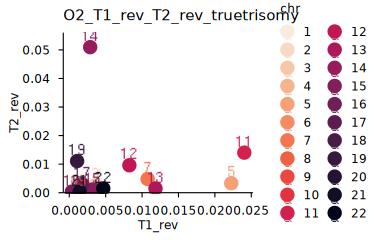

In [205]:
#plot
#sample_name =  "T3_mix_good"
df_prop_sub = df_prop %>% subset(ploidy_chr == "trisomy")

title = "O2_T1_rev_T2_rev_truetrisomy"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T1_rev	, y = T2_rev, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  labs( title = title) +
  settheme+
  scale_color_viridis_d(option = "rocket", direction = -1)+
    scale_y_continuous(limits = c(0, NA),expand = expansion(mult = c(0, 0.1)))+
  #coord_fixed(ratio = 1) +
#geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_text()`).”


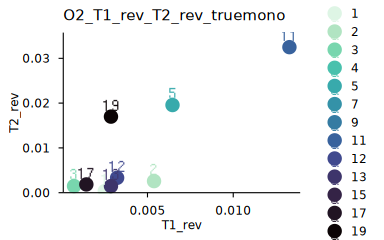

In [206]:
#plot
#sample_name =  "T3_mix_good"
df_prop_sub = df_prop %>% subset(ploidy_chr == "monosomy")

title = "O2_T1_rev_T2_rev_truemono"

w <- 3.2
h <- 2
options(repr.plot.width=w, repr.plot.height=h)

# Scatter plot using ggplot
ggscatter = ggplot(df_prop_sub , aes(x = T1_rev	, y = T2_rev, color = chr)) +
  geom_point(size = 3) +
 #geom_smooth(method = "lm", se = FALSE, color = "red", linetype = "dashed") + # Optional trend line
  labs( title = title) +
  settheme+
  scale_color_viridis_d(option = "mako", direction = -1)+
    scale_y_continuous(limits = c(0, NA),expand = expansion(mult = c(0, 0.1)))+
  #coord_fixed(ratio = 1) +
#geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray50") +  # Scatter points
  geom_text(aes(label = chr), vjust = -0.5, size = 3) 


ggsave(plot = ggscatter, filename = sprintf("%s/%s.pdf",outdir, title), w = w, h = h)
ggscatter

# Model 

In [207]:
head(cell_karyo_df )

,cell,X,karyotype,ploidy,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr,dataset,scrublet_score,scrublet_prediction,scrublet_cluster_score,scrublet_zscore,scrublet_bh_pval,scrublet_bonf_pval,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,n_genes_group,S_score,G2M_score,phase,leiden,mef_score,persample_celltype,sample_celltype,sample,timepoint,Condition,State,n_genes,stress_score_vandenBrink,leiden_theta0,leiden_theta1,leiden_theta2,leiden_theta3,integrated_celltype,leiden_lowres,celltype_fine,celltype_coarse,cell.ID_,num_features,feature_call,num_umis,dataset.y,filtered_feature_call
,<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,24360,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.29044464,0.15769816,S,6,-0.0409680033,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127
2,AAACCTGAGACGCTTT-1_Embryo-Imp15265942,18678,diploid,diploid,0,0,44,0,Embryo-Imp15265942,0.2405063,False,0.2636364,0.6744908,1,0.7921813,6729,32549,803,2.467050,8197,25.18357,high,0.46809529,0.07644101,S,13,0.0004088362,,TE,T2_mix,day4,Mosaic,Intermediate,6729,0.2261420,3,3,5,7,unspecified,2,unspecified_1,unspecified,AAACCTGAGACGCTTT,1,pooled_BC_57,284,Embryo-Imp15265942,pooled_BC_57
3,AAACCTGAGAGTCGGT-1_Embryo-Imp15265946,24361,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.2409639,True,0.2263610,1.0691784,1,0.9224943,5816,25038,529,2.112788,6271,25.04593,high,0.02287884,0.20074458,G2M,6,-0.0466536458,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5816,0.3535609,1,1,0,6,unspecified,2,unspecified_1,unspecified,AAACCTGAGAGTCGGT,1,pooled_BC_155,509,Embryo-Imp15265946,pooled_BC_155
4,AAACCTGAGATCGGGT-1_Embryo-Imp15265944,36486,diploid,diploid,0,0,44,0,Embryo-Imp15265944,0.1247974,False,0.1300000,0.6744908,1,0.8897991,6079,46417,2452,5.282547,10633,22.90755,high,-0.06009019,0.30989354,G2M,4,-0.0272863224,,TE,T3_control,day6,Control,Blastoid_Gd,6079,0.3099473,6,6,6,5,TE,5,TE_2,TE,AAACCTGAGATCGGGT,2,pooled_BC_46|pooled_BC_181,1|1,Embryo-Imp15265944,fail
5,AAACCTGAGCCATCGC-1_Embryo-Imp15265944,24283,diploid,diploid,0,0,44,0,Embryo-Imp15265944,0.0951087,False,0.1086739,0.0605830,1,0.9669925,9291,61415,1447,2.356102,13429,21.86599,high,0.03734729,0.29275252,G2M,11,0.0881670165,,unknown,T3_control,day6,Control,Blastoid_Gd,9291,0.3004118,8,10,10,23,unspecified,0,unspecified_1,unspecified,AAACCTGAGCCATCGC,32,pooled_BC_14|pooled_BC_23|pooled_BC_27|pooled_BC_34|pooled_BC_41|pooled_BC_43|pooled_BC_46|pooled_BC_49|pooled_BC_51|pooled_BC_65|pooled_BC_68|pooled_BC_72|pooled_BC_76|pooled_BC_85|pooled_BC_86|pooled_BC_88|pooled_BC_94|pooled_BC_97|pooled_BC_98|pooled_BC_100|pooled_BC_102|pooled_BC_112|pooled_BC_127|pooled_BC_128|pooled_BC_129|pooled_BC_137|pooled_BC_141|pooled_BC_143|pooled_BC_152|pooled_BC_155|pooled_BC_156|pooled_BC_181,1|2|1|1|2|2|2|1|2|7|2|1|1|1|2|60|1|1|2|1|1|1|2|6|2|1|1|4|1|3|1|4,Embryo-Imp15265944,fail
6,AAACCTGAGCCCGAAA-1_Embryo-Imp15265944,36487,diploid,diploid,0,0,44,0,Embryo-Imp15265944,0.1300000,False,0.1475410,1.1794374,1,0.7862024,5856,29820,1014,3.400403,5819,19.51375,high,0.36315951,0.18351380,S,4,0.0064831209,,TE,T3_control,day6,Control,Blastoid_Gd,5856,0.3663939,6,6,6,5,TE,5,TE_1,TE,AAACCTGAGCCCGAAA,2,pooled_BC_94|pooled_BC_112,1|1,Embryo-Imp15265944,fail


In [208]:
head(cell_chr_karyo_df)

,cell,chr,ploidy_chr,X_chr,dataset_chr,scrublet_score_chr,scrublet_prediction_chr,scrublet_cluster_score_chr,scrublet_zscore_chr,scrublet_bh_pval_chr,scrublet_bonf_pval_chr,n_genes_by_counts_chr,total_counts_chr,total_counts_mt_chr,pct_counts_mt_chr,total_counts_ribo_chr,pct_counts_ribo_chr,n_genes_group_chr,S_score_chr,G2M_score_chr,phase_chr,leiden_chr,mef_score_chr,persample_celltype_chr,sample_celltype_chr,sample,timepoint_chr,Condition_chr,State_chr,n_genes_chr,stress_score_vandenBrink_chr,leiden_theta0_chr,leiden_theta1_chr,leiden_theta2_chr,leiden_theta3_chr,integrated_celltype_chr,leiden_lowres_chr,celltype_fine_chr,celltype_coarse_chr,cell.ID__chr,num_features_chr,feature_call_chr,num_umis_chr,dataset.y_chr,filtered_feature_call_chr,X_cell,karyotype,ploidy_cell,num_gain_chr,num_loss_chr,num_chr,num_abnormal_chr,dataset_cell,scrublet_score_cell,scrublet_prediction_cell,scrublet_cluster_score_cell,scrublet_zscore_cell,scrublet_bh_pval_cell,scrublet_bonf_pval_cell,n_genes_by_counts_cell,total_counts_cell,total_counts_mt_cell,pct_counts_mt_cell,total_counts_ribo_cell,pct_counts_ribo_cell,n_genes_group_cell,S_score_cell,G2M_score_cell,phase_cell,leiden_cell,mef_score_cell,persample_celltype_cell,sample_celltype_cell,sample_cell,timepoint_cell,Condition_cell,State_cell,n_genes_cell,stress_score_vandenBrink_cell,leiden_theta0_cell,leiden_theta1_cell,leiden_theta2_cell,leiden_theta3_cell,integrated_celltype_cell,leiden_lowres_cell,celltype_fine_cell,celltype_coarse_cell,cell.ID__cell,num_features_cell,feature_call_cell,num_umis_cell,dataset.y_cell,filtered_feature_call_cell
,<chr>,<int>,<fct>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,10,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127,24360,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127
2,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,15,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127,24360,diploid,diploid,0,0,44,0,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127
3,AAACCTGAGAAGCCCA-1_Embryo-Imp15265946,19,normal,49029,Embryo-Imp15265946,0.1848225,True,0.1538462,-0.0613319,1,0.9443455,5971,26531,1190,4.485319,7075,26.66692,high,0.2904446,0.1576982,S,6,-0.040968,,TE,T3_mix_bad,day6,Mosaic,Blastoid_Bd,5971,0.3522035,1,1,0,3,unspecified,2,unspecified_1,unspecified,AAACCTGAGAAGCCCA,1,pooled_BC_127,337,Embryo-Imp15265946,pooled_BC_127,24360,diploid,diploid,0,